In [1]:
import warnings
# warnings.filterwarnings('ignore')
import torch
import numpy as np
import matplotlib.pyplot as plt
import copy
import os
import json
import pandas as pd

from flonacomldft.utils.io_utils import (
    load_csv_file,
    load_pickle_file,
)

from flonacomldft.free_energy_computations import (
    compute_BAR_from_samples, compute_TFP_from_samples
)
from ase.units import kB

beta = 1.0 / (kB * 350)
mode_labels = [0, 1]

## 0 -  Data handling

In [2]:
### FILES trained with varying amounts of MD da
#To load the files names of adaptive I will do the next

project_path_ = '/mnt/home/amolina/ceph/adaptive-flow-mc'

# isomers = [0]*4 + [1]*4 +[0]*4 + [1]*4
# number_ids = [int('2994169{:d}'.format(i)) for i in range(8)] + [int('2994949{:d}'.format(i)) for i in range(8)]
# appendix_path = '/1-adaptive/'

isomers = [0]*4 + [1]*4 +[0]*4 + [1]*4
number_ids = [int('3001962{:d}'.format(i)) for i in range(8)] + [int('3000710{:d}'.format(i)) for i in range(8)]
appendix_path = '/2-adaptive-mlp/'


project_path = project_path_ + appendix_path

sims = []

for isomer_id, number_id in zip(isomers, number_ids):
    path_folder = 'results_adaptive_is{:d}_{:d}'.format(isomer_id, number_id)

    # adaptive_file = '/adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, number_id)
    # # sims.append(path_folder+adaptive_file)
    # print('rsync -av rusty:' + project_path+path_folder+adaptive_file + ' 20231911_adaptive_single_isomer/2-adaptive-mlp/')

    # args_file = '/args_adaptive_sampling_{:d}.json'.format(number_id)
    # print('rsync -av rusty:' + project_path+path_folder+args_file + ' 20231911_adaptive_single_isomer/2-adaptive-mlp/')

    # mcmc_file = '/xs_adaptive_is{:d}_{:d}.csv'.format(isomer_id, number_id)
    # print('rsync -av rusty:' + project_path+path_folder+mcmc_file + ' 20231911_adaptive_single_isomer/2-adaptive-mlp/')

    ## CAREFUL NO PROPOSALS IN THESE FOLDERS!!
    prop_file = '/is{:d}_proposals_xs_{:d}.csv'.format(isomer_id, number_id)
    print('rsync -av rusty:' + project_path+path_folder+prop_file + ' 20231911_adaptive_single_isomer' + appendix_path)

rsync -av rusty:/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp/results_adaptive_is0_30019620/is0_proposals_xs_30019620.csv 20231911_adaptive_single_isomer/2-adaptive-mlp/
rsync -av rusty:/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp/results_adaptive_is0_30019621/is0_proposals_xs_30019621.csv 20231911_adaptive_single_isomer/2-adaptive-mlp/
rsync -av rusty:/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp/results_adaptive_is0_30019622/is0_proposals_xs_30019622.csv 20231911_adaptive_single_isomer/2-adaptive-mlp/
rsync -av rusty:/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp/results_adaptive_is0_30019623/is0_proposals_xs_30019623.csv 20231911_adaptive_single_isomer/2-adaptive-mlp/
rsync -av rusty:/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp/results_adaptive_is1_30019624/is1_proposals_xs_30019624.csv 20231911_adaptive_single_isomer/2-adaptive-mlp/
rsync -av rusty:/mnt/home/amolina/ceph/adaptive-flow-mc/2-adaptive-mlp/results_adaptive_is1_30019625/is1_

In [3]:
# path_sims = get_project_path() + '/3-flows-md'

# isomers = [0]*4 + [1]*4
# flows_ids = [int('3006479{:d}'.format(i)) for i in range(8)]
# samples_ids = [int('3006662{:d}'.format(i)) for i in range(8)]

# results_folder = '/results_flow_is{:d}_{:d}'.format(isomers[0], flows_ids[0])

# xs_samples_rc =  load_csv_file('DFTComputations_is{:d}_{:d}/is{:d}_samples_rc_md_{:d}.csv'.format(
#     isomers[0],
#     samples_ids[0],
#     isomers[0],
#     samples_ids[0]), path=path_sims +  results_folder)

# model = load_pickle_file('is{:d}_flow_dic_{:d}.pkl'.format(isomers[0], flows_ids[0]), path=path_sims + results_folder)

In [4]:
rsync -av --exclude '*.out' rusty:/mnt/home/amolina/ceph/adaptive-flow-mc/3-flows-md .

SyntaxError: invalid syntax (1819878163.py, line 1)

### 0.1 - Dataframe with all the args of the simulations

In [5]:
# MARYLOU
project_path = '/Users/marylou/Dropbox/Prof/Experiments/_ceph/ml-dft'
subproject_path = project_path + '/adaptive-350/20231911_adaptive_single_isomer/'

os.listdir(subproject_path)

dic_args = {}

##### ab-flowMC w.o. NP
isomers = [0]*4 + [1]*4 +[0]*4 + [1]*4
number_ids = [int('2994169{:d}'.format(i)) for i in range(8)] + [int('2994949{:d}'.format(i)) for i in range(8)]

subsubproject_path = subproject_path + '/1-adaptive/'

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, number_ids):
    args_file = '/args_adaptive_sampling_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data)
    df_args = df_args.append(sub_df)

dic_args['ab-flowMC-wo-NP'] = df_args

##### ab-flowMC 

isomers = [0]*4 + [1]*4
number_ids = [int('3000710{:d}'.format(i)) for i in range(8)]
subsubproject_path = subproject_path + '/2-adaptive-mlp/'
# project_path = project_path_ + '/2-adaptive-mlp/'

isomers = [0]*4 + [1]*4 +[0]*4 + [1]*4
number_ids = [int('3001962{:d}'.format(i)) for i in range(8)] + [int('3000710{:d}'.format(i)) for i in range(8)]

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, number_ids):
    args_file = '/args_adaptive_sampling_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data)
    df_args = df_args.append(sub_df)

dic_args['ab-flowMC'] = df_args


/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_445/966507150.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_445/966507150.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_445/966507150.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_445/966507150.py:21: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/fol

In [6]:
df_args

,threads,process_id,random_seed,folder_path,dataset,N,isomer_label,flow_n_iter,flow_learning_rate,flow_batch_size,...,flow_type,update_weights,scheduler_weights,alpha,mlps_id,flows_id,date_start,date_end,algorithm,time_init
0,None,30019620,26,andersen,mlp,500,0,200,0.0001,1000,...,None,True,10,0.5,30006070,None,20231120074319,20231120212444,adaptive_sampling.py,1.700484e+09
0,None,30019621,45,andersen,mlp,1000,0,200,0.0001,1000,...,None,True,10,0.5,30006070,None,20231120074319,20231120214032,adaptive_sampling.py,1.700484e+09
0,None,30019622,45,andersen,mlp,2000,0,200,0.0001,1000,...,None,True,10,0.5,30006070,None,20231120074319,20231120212336,adaptive_sampling.py,1.700484e+09
0,None,30019623,1,andersen,mlp,4000,0,200,0.0001,1000,...,None,True,10,0.5,30006070,None,20231120074319,20231120213241,adaptive_sampling.py,1.700484e+09
0,None,30019624,36,andersen,mlp,500,1,200,0.0001,1000,...,None,True,10,0.5,30006071,None,20231120074313,20231120204137,adaptive_sampling.py,1.700484e+09
0,None,30019625,13,andersen,mlp,1000,1,200,0.0001,1000,...,None,True,10,0.5,30006071,None,20231120074314,20231120204548,adaptive_sampling.py,1.700484e+09
0,None,30019626,76,andersen,mlp,2000,1,200,0.0001,1000,...,None,True,10,0.5,30006071,None,20231120074313,20231120204426,adaptive_sampling.py,1.700484e+09
0,None,30019627,86,andersen,mlp,4000,1,200,0.0001,1000,...,None,True,10,0.5,30006071,None,20231120074314,20231120204552,adaptive_sampling.py,1.700484e+09
0,None,30007100,37,andersen,mlp,500,0,100,0.0001,500,...,None,True,10,0.5,30006070,None,20231119163910,20231120062122,adaptive_sampling.py,1.700430e+09
0,None,30007101,15,andersen,mlp,1000,0,100,0.0001,500,...,None,True,10,0.5,30006070,None,20231119163910,20231120063621,adaptive_sampling.py,1.700430e+09


In [7]:
df_args = dic_args['ab-flowMC-wo-NP']

## Selecting best batch size for ab-flowMC w.o. NP
batch_size = 1000

isomer = 1

df_isomer = df_args.loc[(df_args['flow_batch_size'] == batch_size) & (df_args['isomer_label'] == isomer)]
df_isomer['N'].values

array([ 500, 1000, 2000, 4000])

In [8]:
##### MD simulations
isomers = [0]*4 + [1]*4
flows_ids = [int('3006479{:d}'.format(i)) for i in range(8)]
samples_ids = [int('3006662{:d}'.format(i)) for i in range(8)]

subsubproject_path = subproject_path + '3-flows-md/'

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, flows_ids):
    args_file = 'args_train_flow_model_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data, index=[0])
    df_args = df_args.append(sub_df)

dic_args['MD-training'] = df_args

df_args = pd.DataFrame()
for isomer_id, number_id in zip(isomers, samples_ids):
    args_file = 'args_samples_from_flow_{:d}.json'.format(number_id)
    f = open(subsubproject_path+args_file)
    data = json.load(f)
    sub_df = pd.DataFrame(data, index=[0])
    df_args = df_args.append(sub_df)

dic_args['MD-sampling'] = df_args


/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_445/3194167661.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_445/3194167661.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_445/3194167661.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var/folders/tg/pl1cc7qd2xgghps365_s9d880000gn/T/ipykernel_445/3194167661.py:14: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_args = df_args.append(sub_df)
/var

### 0.2 - Loading models

In [9]:
def load_models(isomer_id, process_id, project_path=subproject_path+ '/1-adaptive/'):
    if '3-flows-md' in project_path:
        f = 'is{:d}_flow_dic_{:d}.pkl'.format(isomer_id, process_id)
        models = [load_pickle_file(f, path=project_path)['model']]
    else:
        f = 'adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id)
        dic_trainings = load_pickle_file(f, path=project_path)
        models = [ dic[0]['model'] for dic in dic_trainings['dict_flows'] ]
    return models

In [10]:
def load_mlp_models(isomer_id, process_id, project_path=subproject_path+ '/1-adaptive/'):
    f = 'adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id)
    dic_trainings = load_pickle_file(f, path=project_path)
    mlp_models = [dic[0]['model']  for dic in dic_trainings['dict_mlps']]
    
    return mlp_models

In [11]:
isomer_id = 0
process_id = 29941690
models = load_models(isomer_id, process_id)
len(models)

/Users/marylou/anaconda3/envs/ml-dft/lib/python3.11/site-packages/numba/core/decorators.py:262: NumbaDeprecationWarning: numba.generated_jit is deprecated. Please see the documentation at: https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-generated-jit for more information and advice on a suitable replacement.
  warnings.warn(msg, NumbaDeprecationWarning)


31

### 0.3 - Loading the data

In [13]:
kinds = ['xs_adaptive', 'xs_proposals', 'MD-sampling']

# def load_samples_n_energies(kind, isomer_id, process_id, project_path=subproject_path + '/1-adaptive/'):
#     torch_tensor = load_csv_file('{:s}_is{:d}_{:d}.csv'.format(kind, isomer_id, process_id),
#                   path=project_path)
#     return torch_tensor[:, :12], torch_tensor[:, 12]

def load_samples_n_energies(kind, isomer_id, process_id, project_path=subproject_path + '/1-adaptive/'):
    if kind == 'xs_adaptive':
        torch_tensor = load_csv_file('{:s}_is{:d}_{:d}.csv'.format(kind, isomer_id, process_id),
                    path=project_path)
        xs = torch_tensor[:, :12]
        us = torch_tensor[:, 12]
    elif kind == 'MD-sampling':
        torch_tensor = load_csv_file('is{:d}_samples_rc_md_{:d}.csv'.format(isomer_id, process_id),
                    path=project_path)
        xs = torch_tensor[:, :12]
        us = torch_tensor[:, 12]
    elif kind == 'xs_proposals':
        # f = 'adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id)
        # dic_trainings = load_pickle_file(f, path=project_path)
        # xs = torch.stack(dic_trainings['xs_proposals']).reshape(-1, 12)
        # us = torch.stack(dic_trainings['us_proposals']).reshape(-1)
        torch_tensor = load_csv_file('is{:d}_proposals_xs_{:d}.csv'.format(isomer_id, process_id),
                    path=project_path)
        xs = torch_tensor[:, :12]
        us = torch_tensor[:, 12]

    return xs, us

In [14]:
process_id = 29941690
xs, us = load_samples_n_energies('xs_proposals', 0, process_id, project_path=subproject_path + '/1-adaptive/')
process_id = 30019622
xs, us = load_samples_n_energies('xs_proposals', 0, process_id, project_path=subproject_path + '/2-adaptive-mlp/')

In [15]:
# ns_md_init_data = np.unique(df_args['N'].values)

Text(0, 0.5, 'Energy')

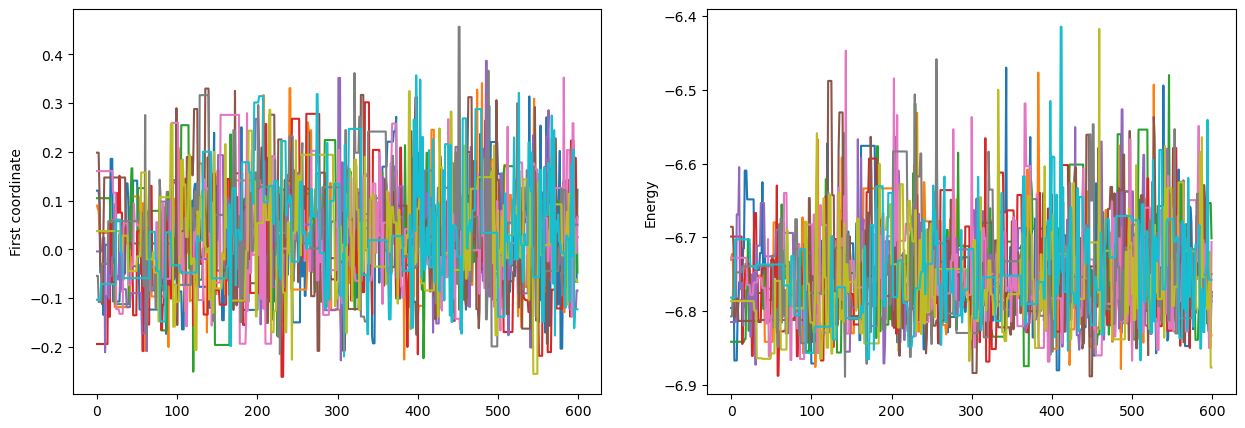

In [16]:
process_id = 29941690
xs, us = load_samples_n_energies('xs_adaptive', 0, process_id, project_path=subproject_path + '/1-adaptive/')

df_args = dic_args['ab-flowMC-wo-NP']
n_chains = df_args.loc[df_args['process_id'] == process_id]['n_chains'].values[0]

xs = xs.reshape(-1, n_chains, 12)
us = us.reshape(-1, n_chains)
# print(x.shape)
plt.figure(figsize=(15, 5))
axs = [plt.subplot(1, 2, i+1) for i in range(2)]
plt.sca(axs[0])
plt.plot(xs[:, :10, 0].numpy())

# xs_byslice = xs.reshape(30, -1, n_chains, 12)
# plt.plot(xs_byslice[0, :, :4, 0].numpy(), '.-')

plt.ylabel('First coordinate')

plt.sca(axs[1])
plt.plot(us[:, :10].numpy())
plt.ylabel('Energy')

# x = load_samples_n_energies('xs_proposals', 0, 29941690)



In [16]:
# kinds = ['ab-flowMC-wo-NP'] #, 'ab-flowMC']

# batch_size = 1000 ## best to be selected - not necessarily everywhere

# for isomer in mode_labels:
#     plt.figure()
#     plt.title('isomer {:d}'.format(isomer))

#     for kind in kinds:
#         df_args = dic_args[kind]

#         df_isomer = df_args.loc[(df_args['flow_batch_size'] == batch_size) & (df_args['isomer_label'] == isomer)]

#         samples, energies = load_samples_n_energies(kind, isomer)
#         print('{:s} - {:d} samples'.format(kind, samples.shape[0]))
#         plt.hist(energies, 50, alpha=0.5, label=kind, density=True)
#         plt.xlim(-7, -5.8)
#     plt.legend()

### 0.z - Inspecting the models

#### 0.z.1 - ab-flowMC-wo-NP

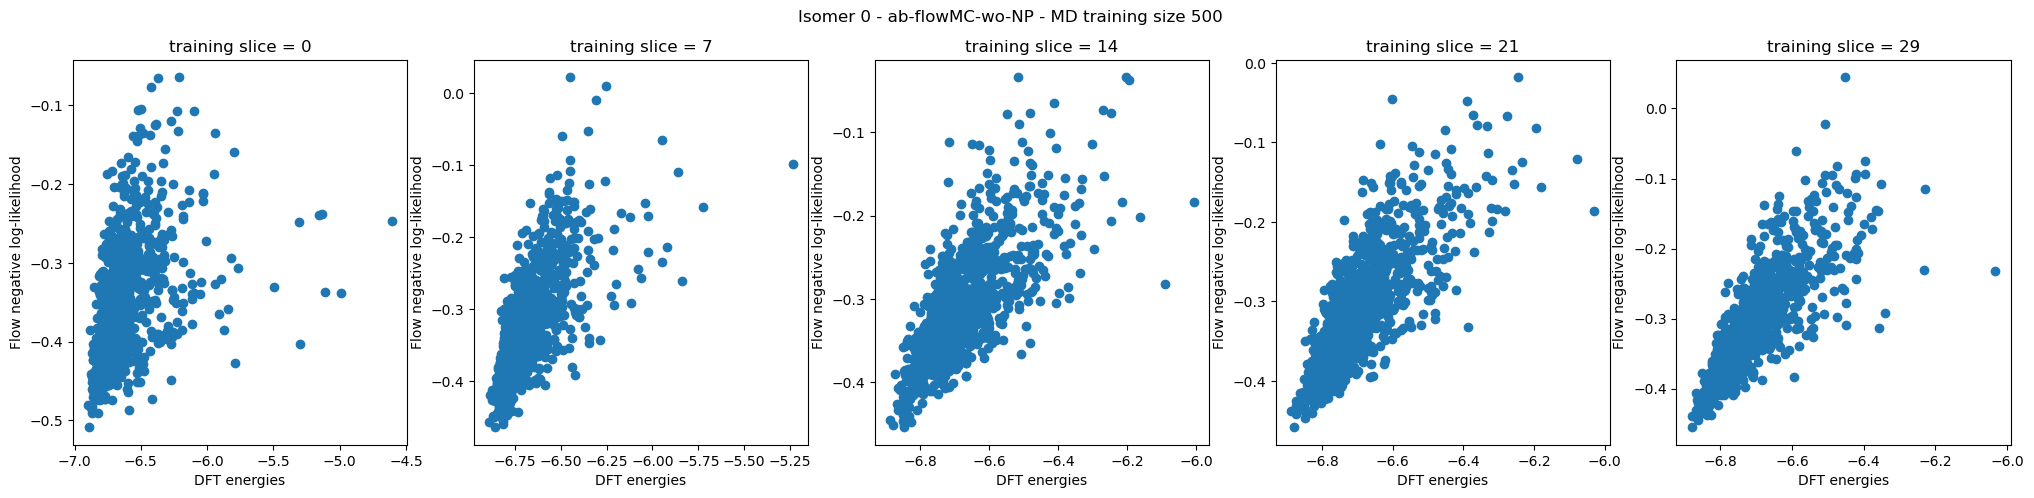

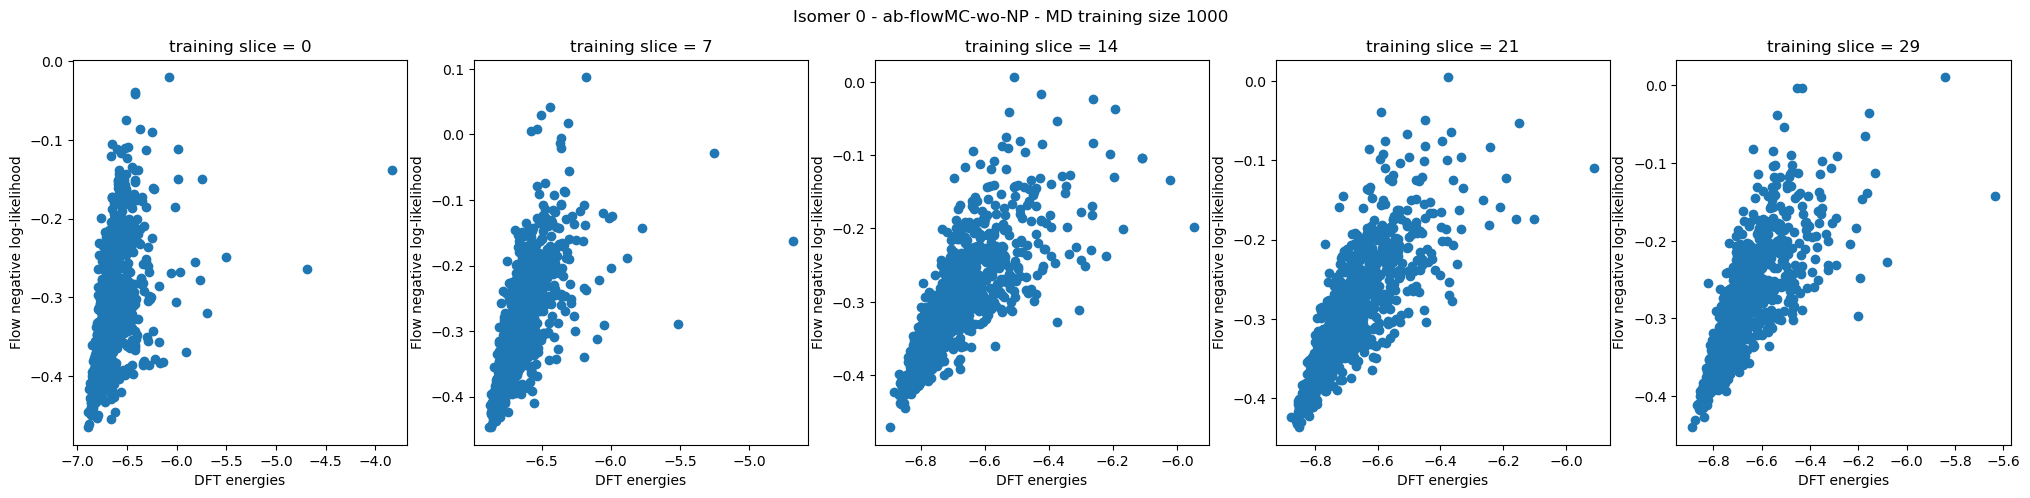

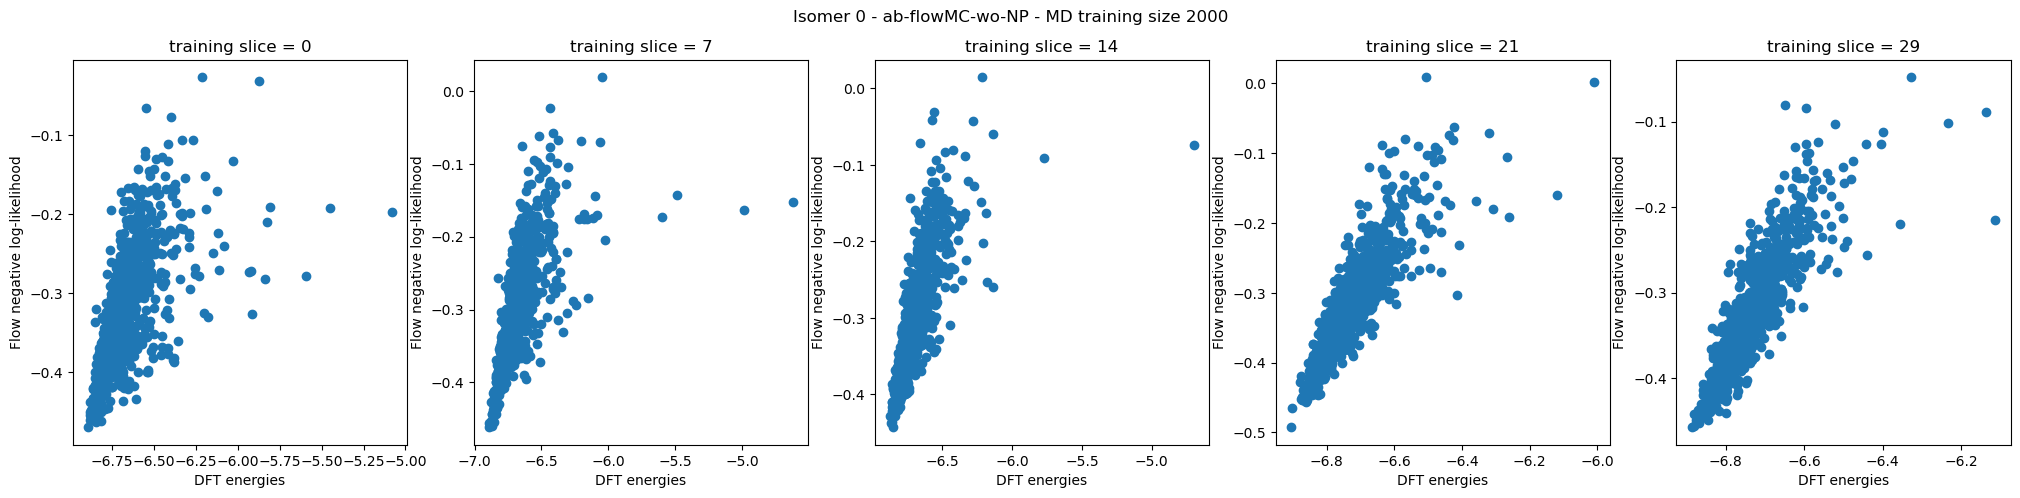

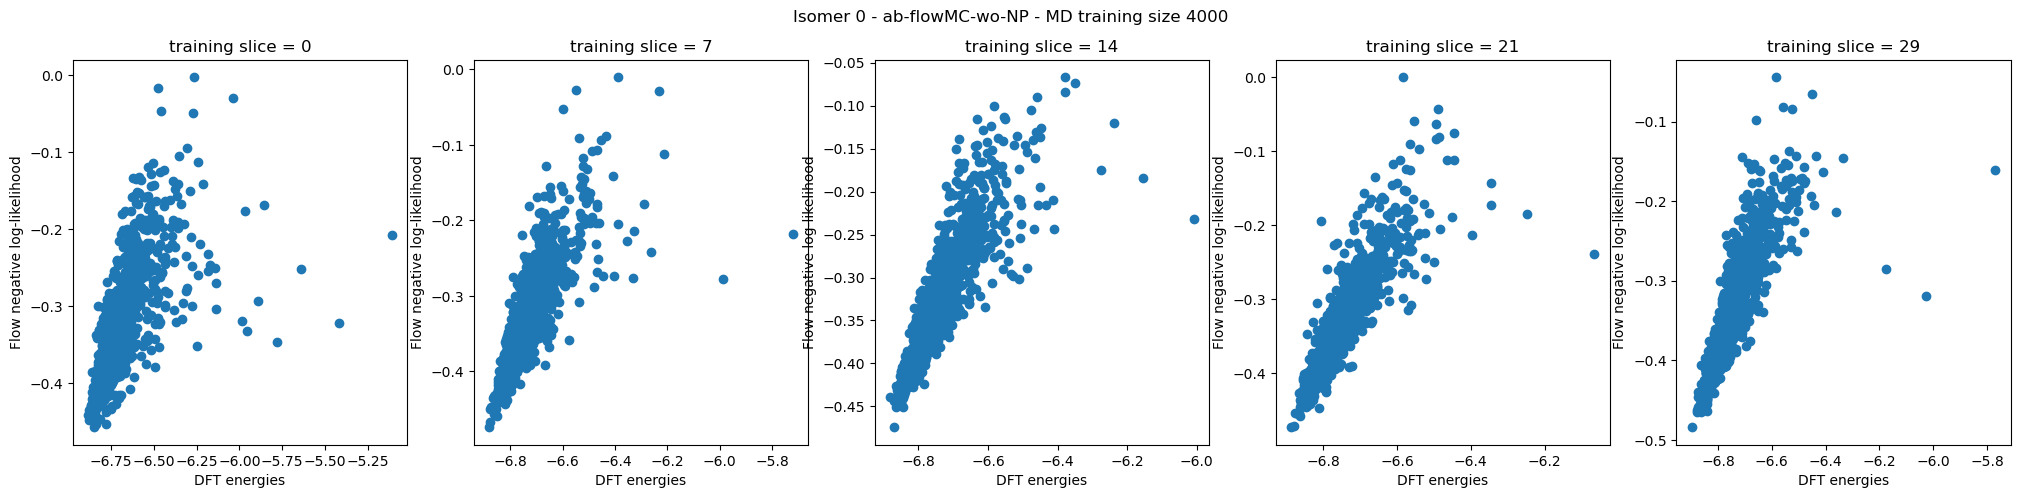

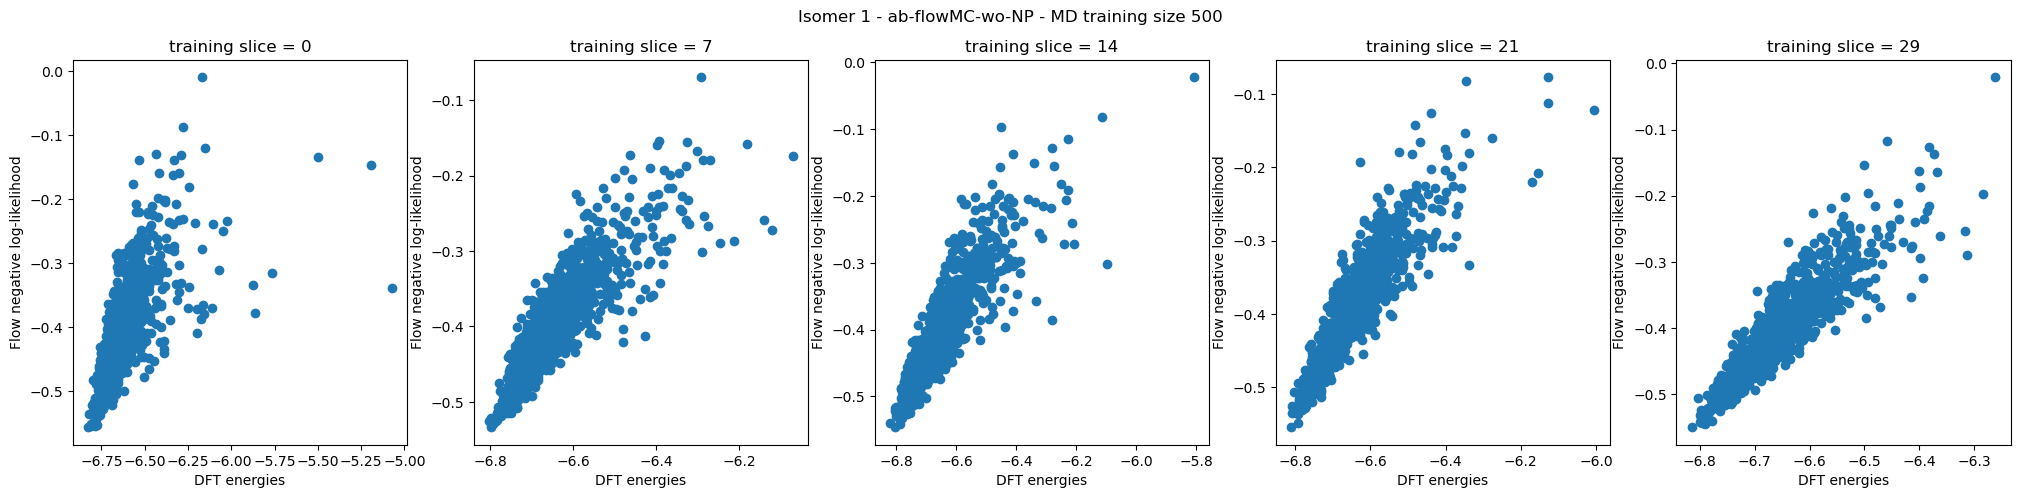

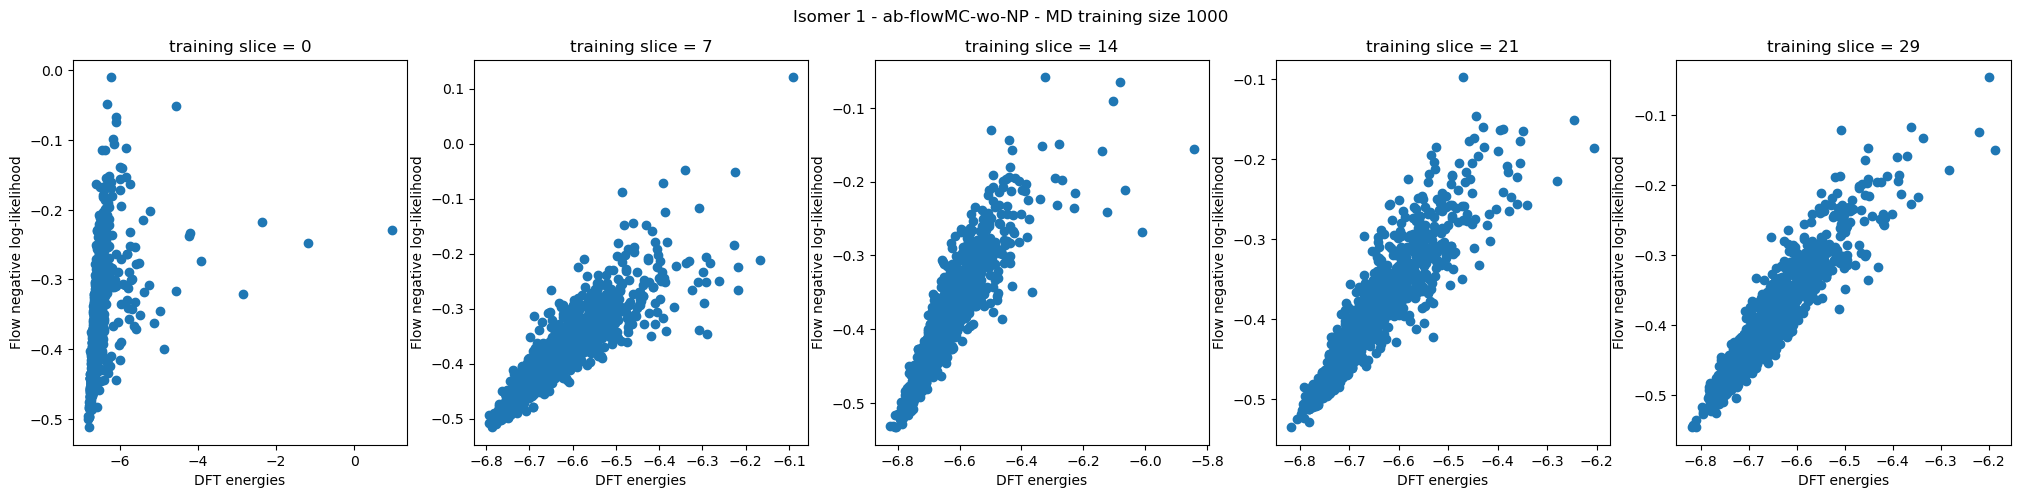

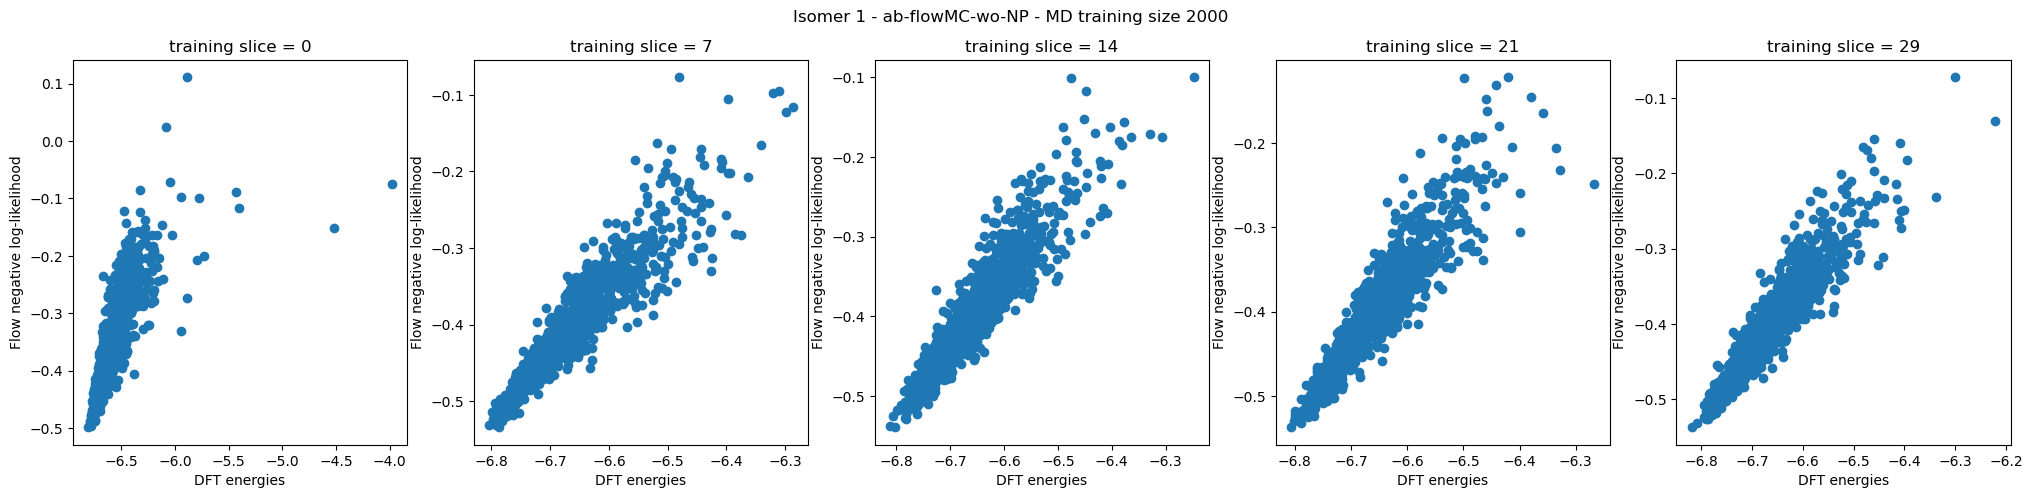

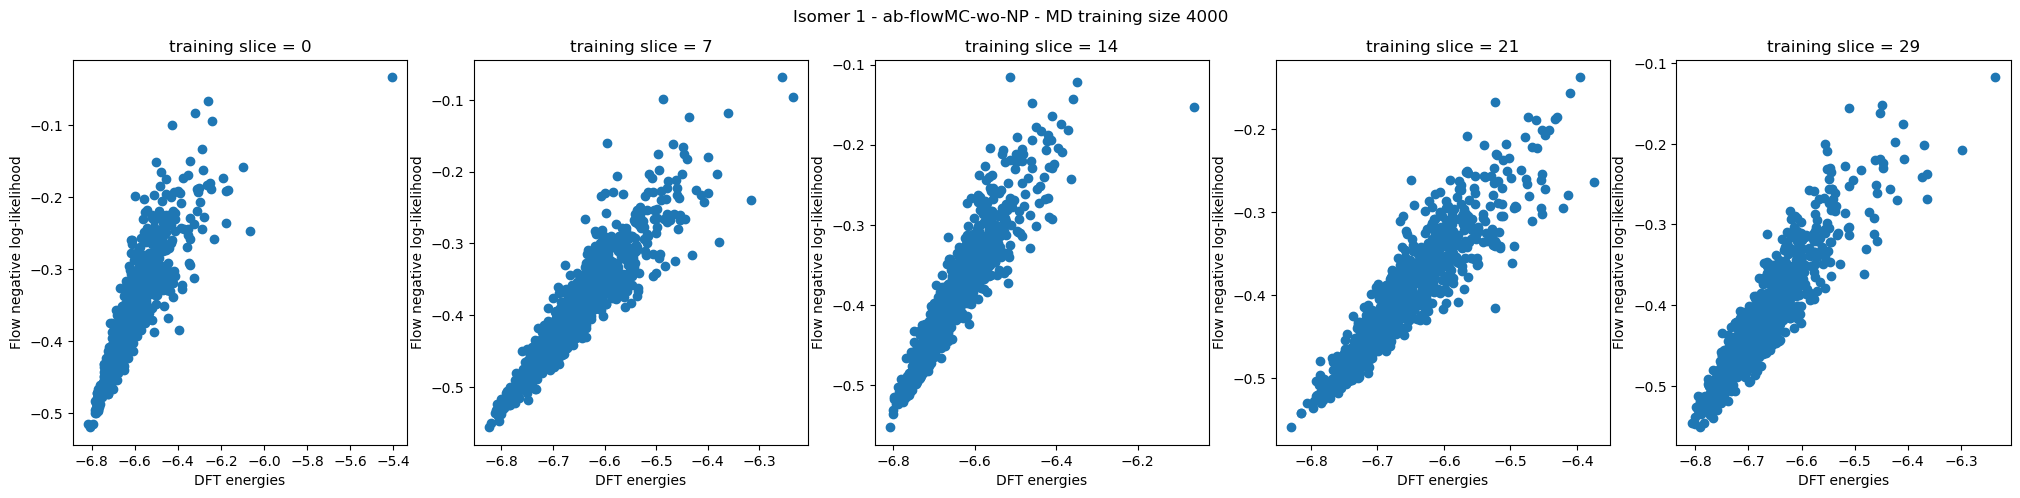

In [441]:
kind = 'ab-flowMC-wo-NP'
df_args = dic_args[kind]
n_train_slice = 5

for isomer_id in mode_labels:
    df_isomer = df_args.loc[(df_args['flow_batch_size'] == batch_size) & (df_args['isomer_label'] == isomer_id)]
    
    md_training_sizes = df_isomer['N'].values
    process_ids = df_isomer['process_id'].values

    for md_training_size, process_id in zip(md_training_sizes, process_ids):

        models = load_models(isomer_id, process_id, project_path=subproject_path + '/1-adaptive/') 
        train_slices = (np.linspace(0, len(models)-2, n_train_slice)).astype(int)

        prop_samples, energy_target = load_samples_n_energies('xs_proposals', isomer_id, process_id, project_path=subproject_path + '/1-adaptive/')

        # mask = np.ones(prop_samples.shape[0], dtype=bool)
        # for n in range(30):
        #     mask[50 * n:50 * (n+1)] = False

        # prop_samples = prop_samples[mask]
        # energy_target = energy_target[mask]
        # print('Cleaned prop samples : ', prop_samples.shape[0], 'samples')

        plt.figure(figsize=(5 * n_train_slice / 1, 5 * 1))
        plt.suptitle('Isomer {:d} - {:s} - MD training size {:d}'.format(isomer_id, kind, md_training_size))
        axs = [plt.subplot(1, int(n_train_slice // 1), i+1) for i in range(n_train_slice)]

        n_chains = df_isomer.loc[df_isomer['process_id'] == process_id]['n_chains'].values[0]
        
        # prop_samples = prop_samples.reshape(-1, n_chains, 12)
        prop_samples = prop_samples.reshape(len(models) - 1, -1, 12)
        # energy_target = energy_target.reshape(-1, n_chains)
        energy_target = energy_target.reshape(len(models) - 1, -1)

        for t, train_slice in enumerate(train_slices):
            # print('prop_samples_t.shape = ', prop_samples_t.shape)
            
            logprob_prop = (- models[train_slice].nll(prop_samples[train_slice])).detach().numpy()
            logprob_target = (- beta * energy_target[train_slice]).detach().numpy()
            
            plt.sca(axs[t])
            plt.scatter( - logprob_target / beta, - logprob_prop / beta)
            plt.xlabel('DFT energies')
            plt.ylabel('Flow negative log-likelihood')
            plt.title('training slice = {:d}'.format(train_slice))

THAT WON'T BE THE CASE ANYMORE: Checking that the xs_proposals and us_proposals are the same in the csv file and the dic_trainings,

In [261]:
# f = 'adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id)
# dic_trainings = load_pickle_file(f, path=subproject_path + '/1-adaptive')

# prop_samples, energy_target = load_samples_n_energies('xs_proposals', isomer_id, process_id, project_path=subproject_path + '/1-adaptive/')
# torch.stack(dic_trainings['xs_proposals']).reshape(-1, 12) - prop_samples
# torch.stack(dic_trainings['us_proposals']).reshape(-1) - energy_target 

#### 0.z.2 - ab-flowMC

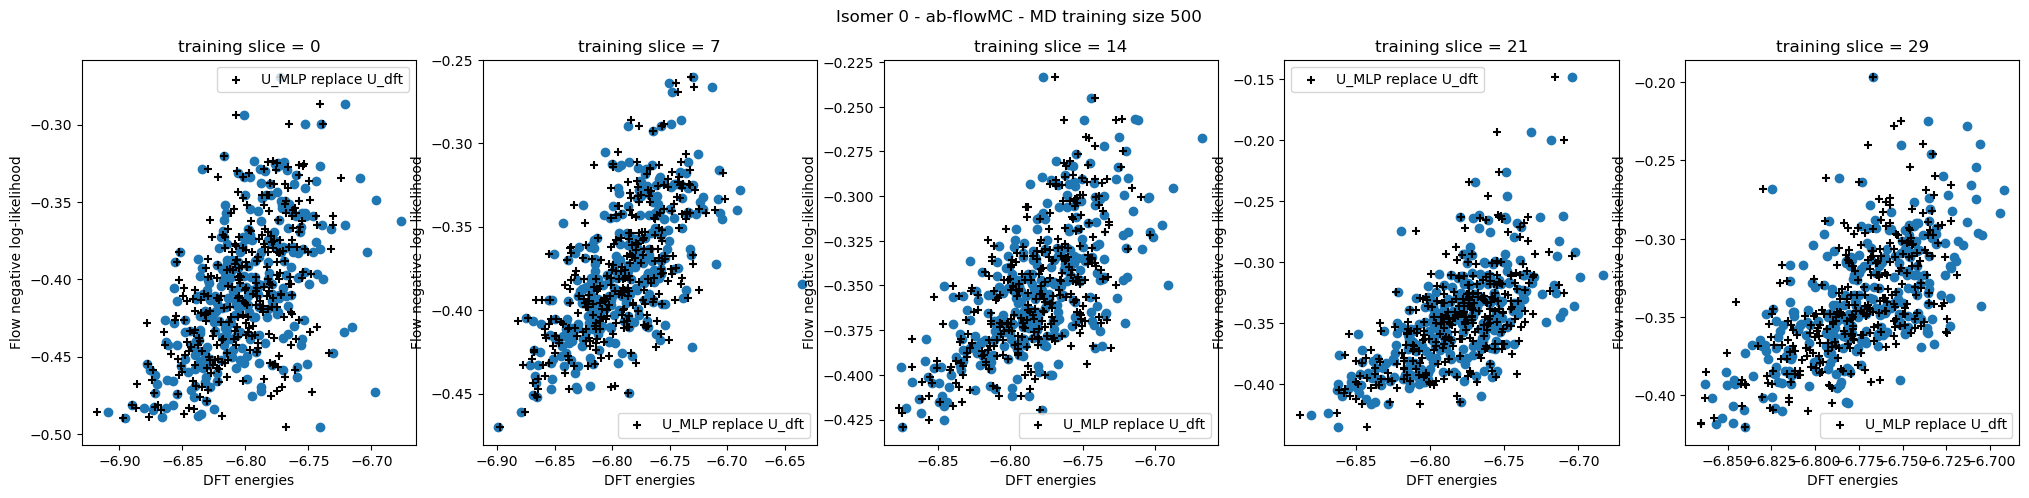

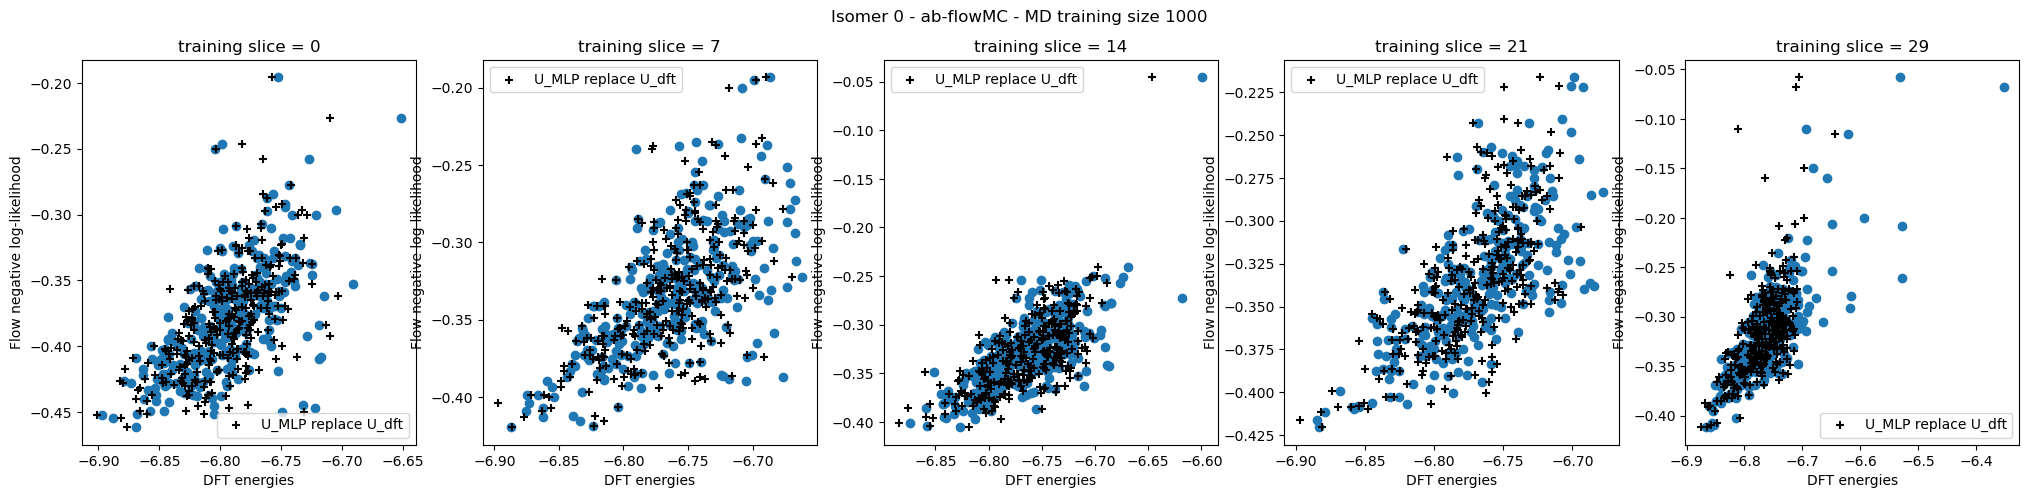

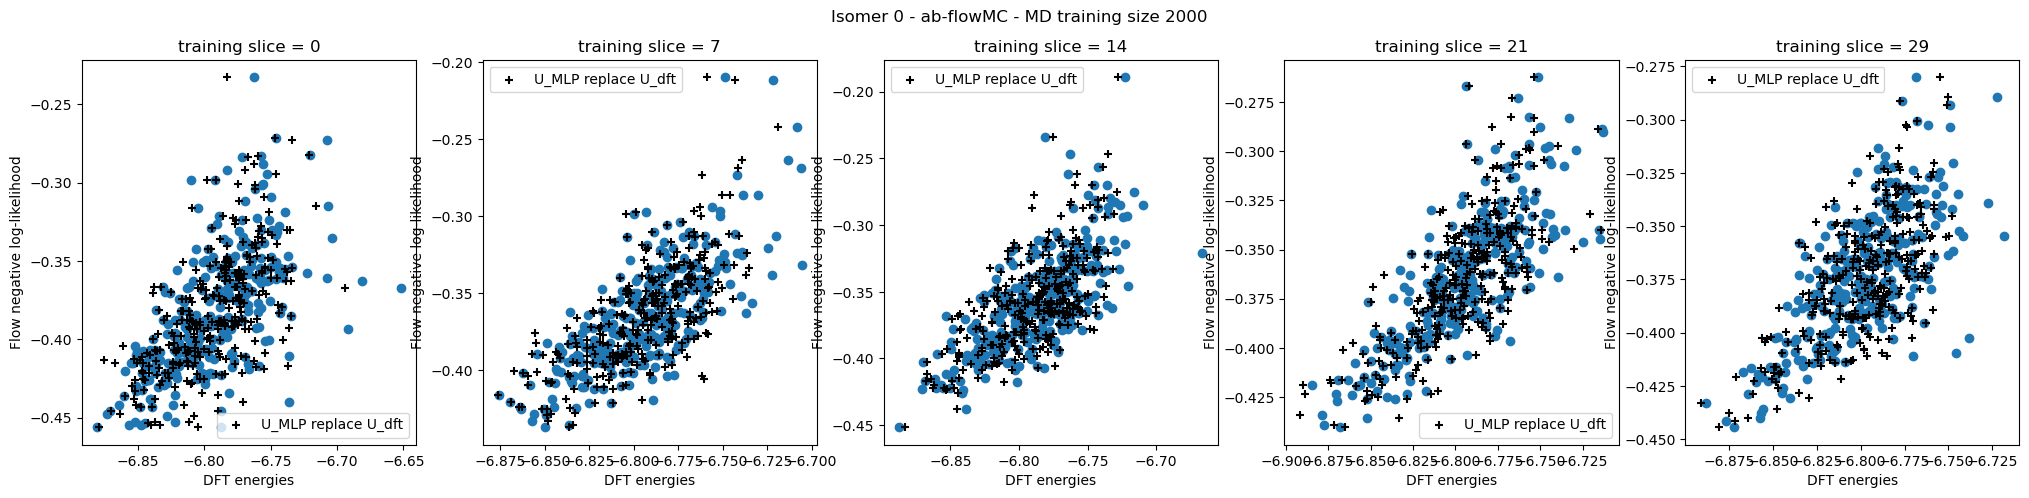

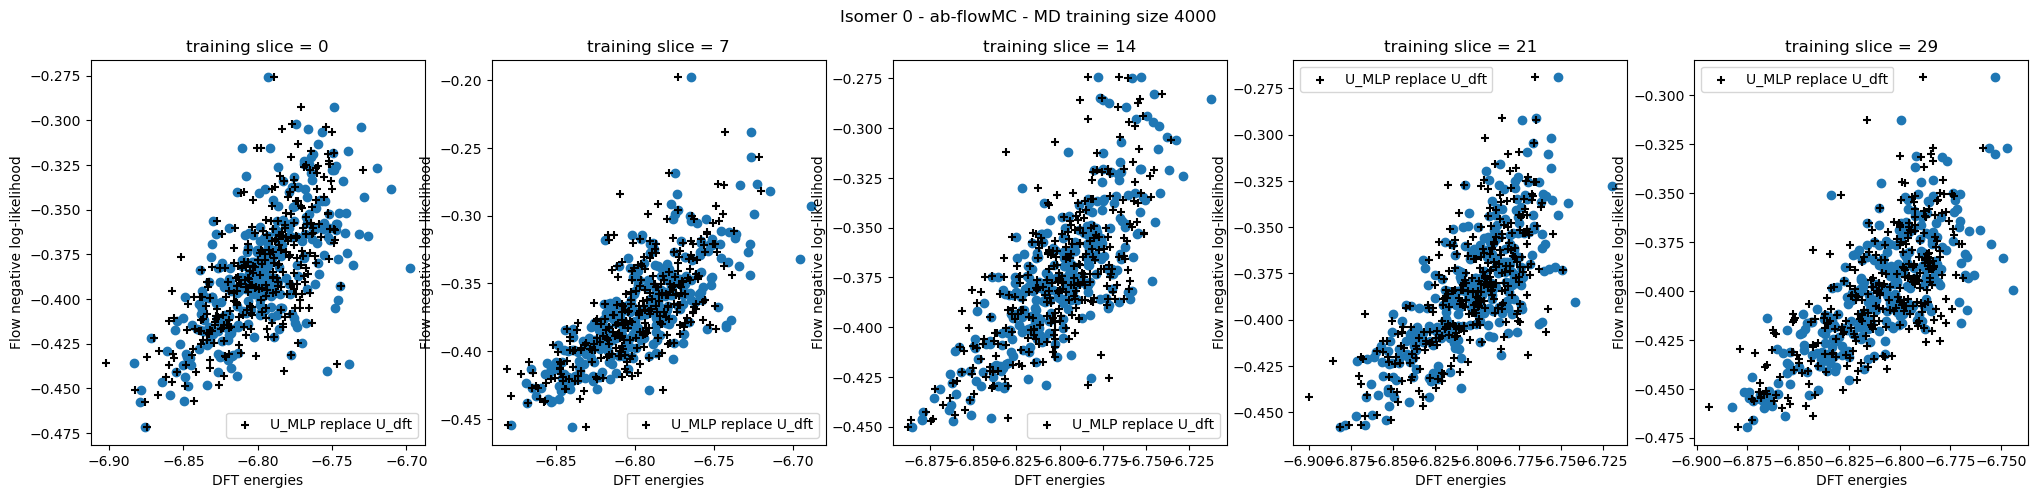

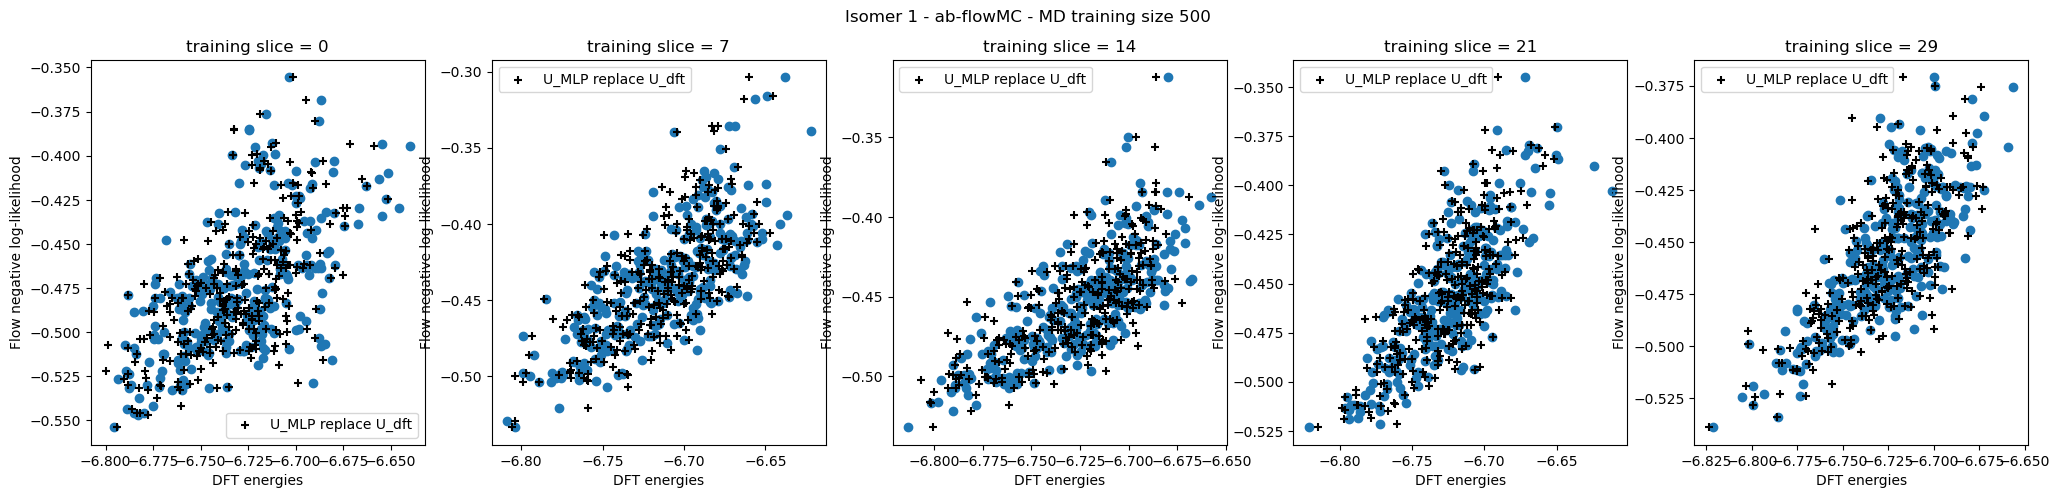

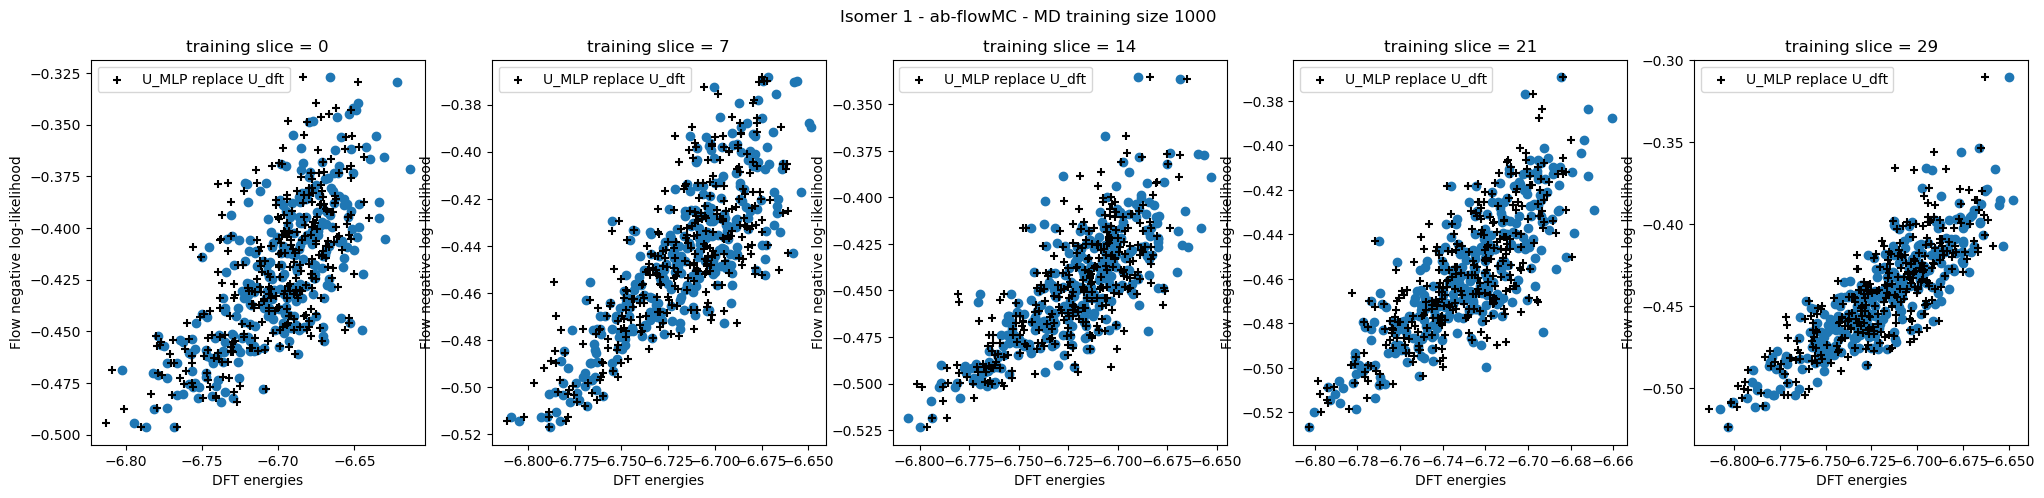

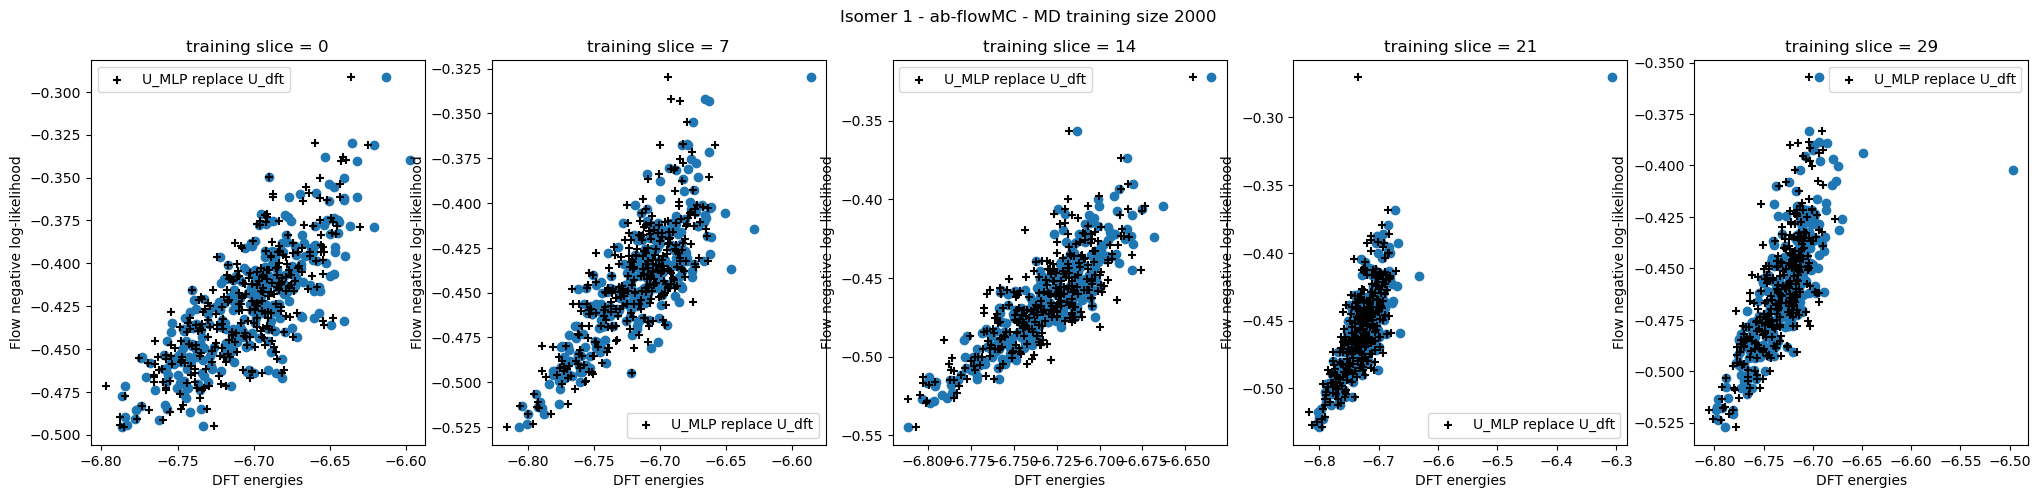

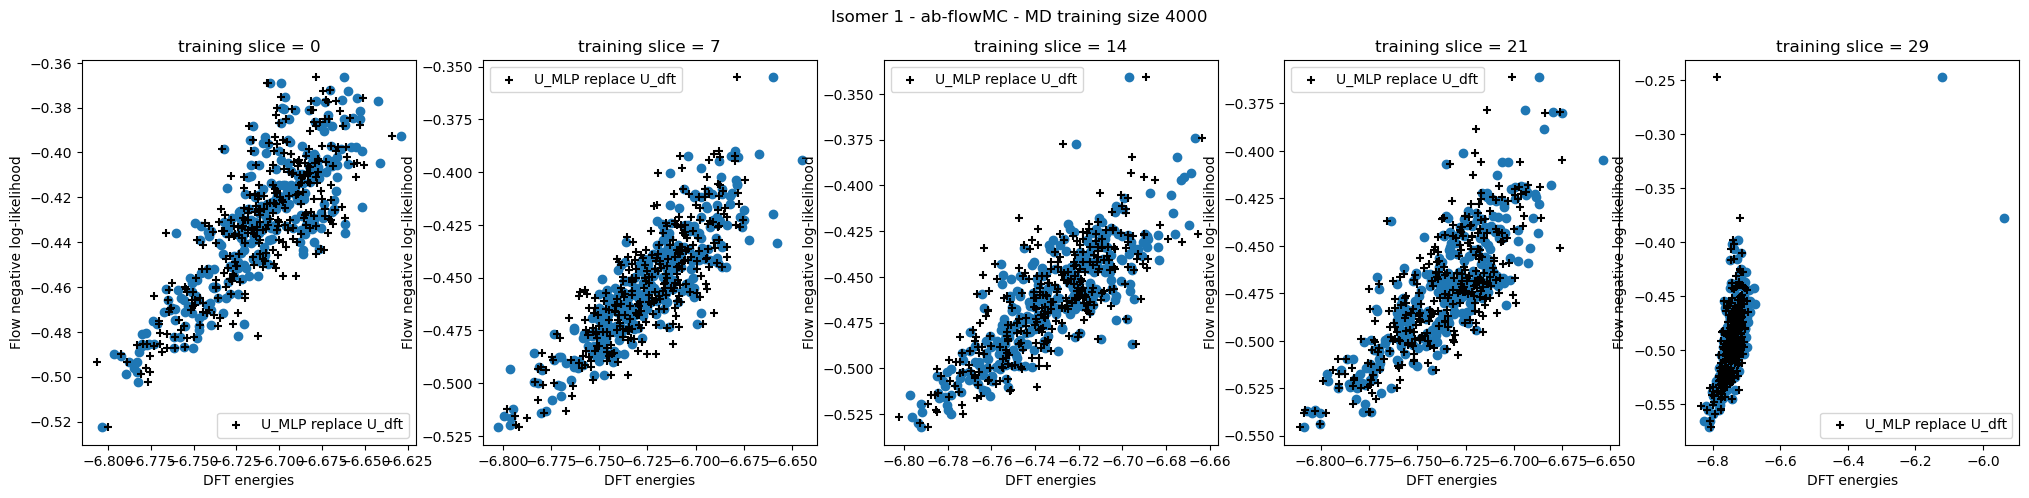

In [442]:
kind = 'ab-flowMC'
df_args = dic_args[kind]
n_train_slice = 5
for isomer_id in mode_labels:
    df_isomer = df_args.loc[(df_args['flow_batch_size'] == batch_size) & (df_args['isomer_label'] == isomer_id)]
    
    md_training_sizes = df_isomer['N'].values
    process_ids = df_isomer['process_id'].values

    for md_training_size, process_id in zip(md_training_sizes, process_ids):

        models = load_models(isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/') 
        mlp_models = load_mlp_models(isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/')
        
        train_slices = (np.linspace(0, len(models)-2, n_train_slice)).astype(int)

        prop_samples, energy_target = load_samples_n_energies('xs_proposals', isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/')
        # mc_samples, mc_energy_target = load_samples_n_energies('xs_adaptive', isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/')
        
        # mask = np.ones(prop_samples.shape[0], dtype=bool)
        # for n in range(30):
        #     mask[50 * n:50 * (n+1)] = False

        # prop_samples = prop_samples[mask]
        # energy_target = energy_target[mask]
        # print('Cleaned prop samples : ', prop_samples.shape[0], 'samples')

        # prop_samples, energy_target = load_samples_n_energies('xs_adaptive', isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/')
        # print('Loading the ADAPTIVE samples for NOW as no proposals in the folder')

        plt.figure(figsize=(5 * n_train_slice / 1, 5 * 1))
        plt.suptitle('Isomer {:d} - {:s} - MD training size {:d}'.format(isomer_id, kind, md_training_size))
        axs = [plt.subplot(1, int(n_train_slice // 1), i+1) for i in range(n_train_slice)]

        n_chains = df_isomer.loc[df_isomer['process_id'] == process_id]['n_chains'].values[0]
        
        # prop_samples = prop_samples.reshape(-1, n_chains, 12)
        prop_samples = prop_samples.reshape(len(models) - 1, -1, 12)
        # energy_target = energy_target.reshape(-1, n_chains)
        energy_target = energy_target.reshape(len(models) - 1, -1)

        for t, train_slice in enumerate(train_slices):

            # print('prop_samples_t.shape = ', prop_samples_t.shape)
            
            logprob_prop = (- models[train_slice].nll(prop_samples[train_slice])).detach().numpy()
            logprob_target = (- beta * energy_target[train_slice]).detach().numpy()
            logprob_mlp = (- beta * mlp_models[train_slice](prop_samples[train_slice])).detach().numpy()
            
            plt.sca(axs[t])
            plt.scatter( - logprob_target / beta, - logprob_prop / beta)
            plt.scatter(- logprob_mlp / beta, - logprob_prop / beta, c='k', marker='+', label='U_MLP replace U_dft')
            plt.xlabel('DFT energies')
            plt.ylabel('Flow negative log-likelihood')
            plt.title('training slice = {:d}'.format(train_slice))
            plt.legend()

In [283]:
f = 'adaptive_sampling_is{:d}_{:d}.pkl'.format(isomer_id, process_id)
dic_trainings = load_pickle_file(f, path=subproject_path + '/2-adaptive-mlp')

# prop_samples, energy_target = load_samples_n_energies('xs_proposals', isomer_id, process_id, project_path=subproject_path + '/1-adaptive/')
# torch.stack(dic_trainings['xs_proposals']).reshape(-1, 12) - prop_samples
# torch.stack(dic_trainings['us_proposals']).reshape(-1) - energy_target 

#### 0.z.3 - MD only

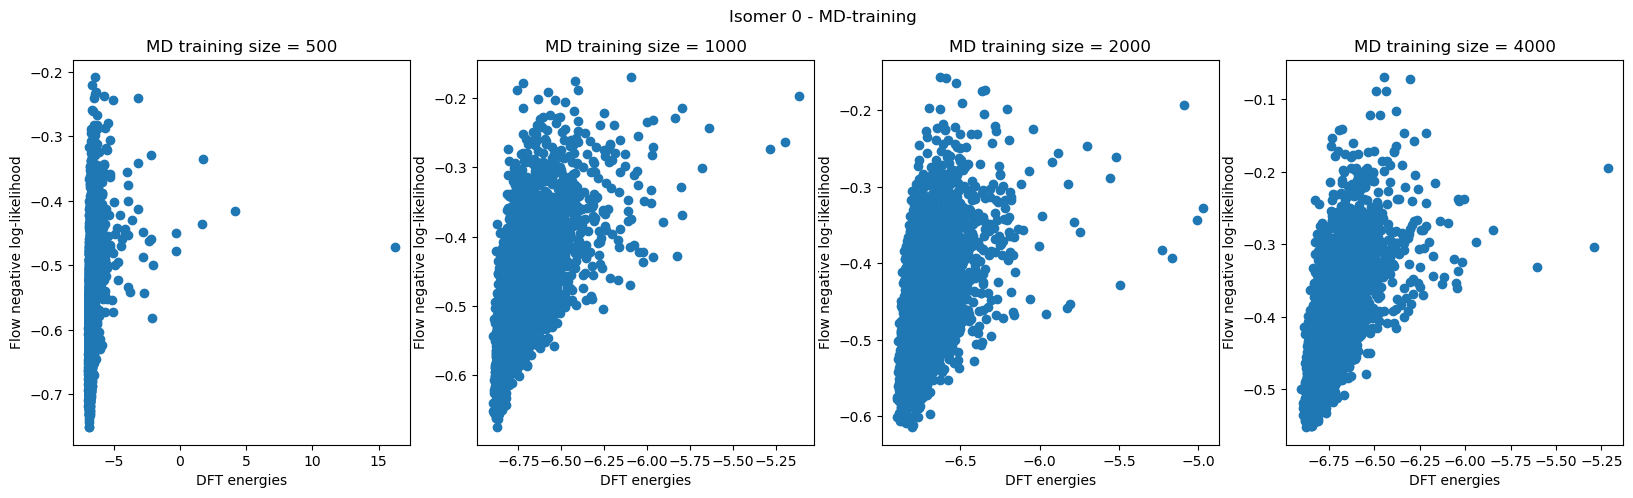

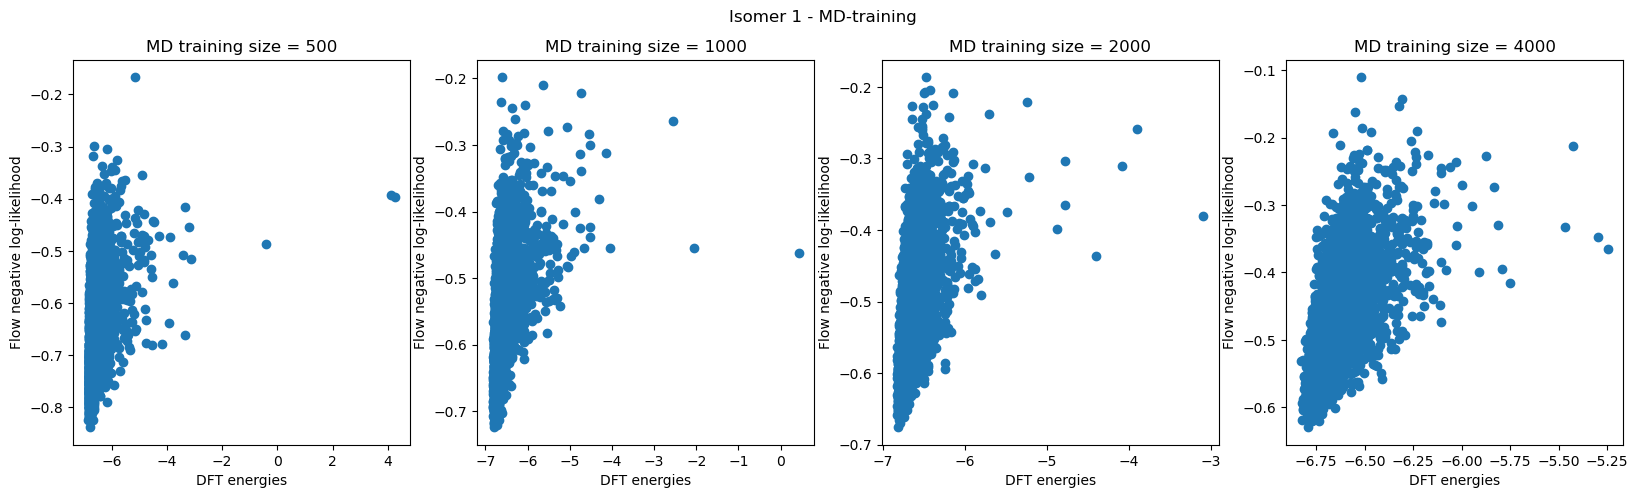

In [356]:
kind = 'MD-training'
df_args = dic_args[kind]

df_args_sample = dic_args['MD-sampling']


for isomer_id in mode_labels:
    df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id)]
    df_isomer_sample = df_args_sample.loc[(df_args_sample['isomer_label'] == isomer_id)]
    
    md_training_sizes = df_isomer['N'].values
    process_ids = df_isomer['process_id'].values
    samples_ids = df_isomer_sample['process_id'].values

    plt.figure(figsize=(5 * 4 / 1, 5 * 1))
    plt.suptitle('Isomer {:d} - {:s}'.format(isomer_id, kind))
    axs = [plt.subplot(1, int(4 // 1), i+1) for i in range(4)]
    ax_ = 0

    for md_training_size, process_id, samples_id in zip(md_training_sizes, process_ids, samples_ids):

        models = load_models(isomer_id, process_id, project_path=subproject_path + '/3-flows-md/') 

        prop_samples, energy_target = load_samples_n_energies('MD', isomer_id, samples_id, project_path=subproject_path + '/3-flows-md/')
        # mc_samples, mc_energy_target = load_samples_n_energies('xs_adaptive', isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/')
            
        logprob_prop = (- models[0].nll(prop_samples)).detach().numpy()
        logprob_target = (- beta * energy_target).detach().numpy()
    
        plt.sca(axs[ax_])
        plt.scatter( - logprob_target / beta, - logprob_prop / beta)
        plt.xlabel('DFT energies')
        plt.ylabel('Flow negative log-likelihood')
        plt.title('MD training size = {:d}'.format(md_training_size))

        ax_ += 1

## 1 - TFEP computations: 

### 1.1 - ab-flowMC w.o. NP - Flows trained on DFT without neural predictor

Isomer 0, MD training size = 500, process_id 29941690
1000 samples per training slice --> n_trial = 3
Isomer 0, MD training size = 1000, process_id 29941691
1000 samples per training slice --> n_trial = 3
Isomer 0, MD training size = 2000, process_id 29941692
1000 samples per training slice --> n_trial = 3
Isomer 0, MD training size = 4000, process_id 29941693
1000 samples per training slice --> n_trial = 3
Isomer 1, MD training size = 500, process_id 29941694
1000 samples per training slice --> n_trial = 3
Isomer 1, MD training size = 1000, process_id 29941695
1000 samples per training slice --> n_trial = 3
Isomer 1, MD training size = 2000, process_id 29941696
1000 samples per training slice --> n_trial = 3
Isomer 1, MD training size = 4000, process_id 29941697
1000 samples per training slice --> n_trial = 3


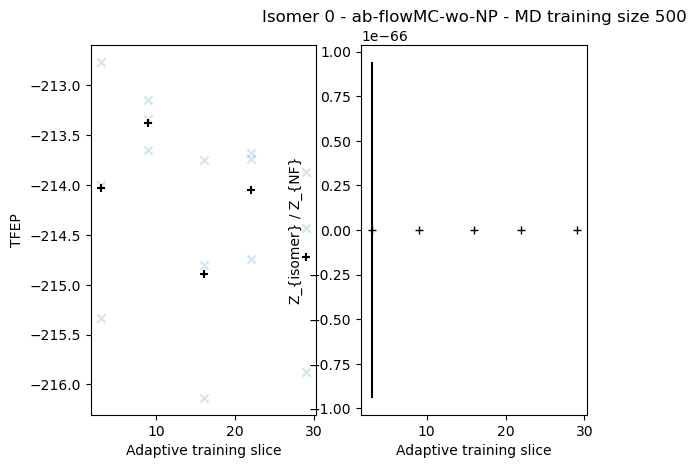

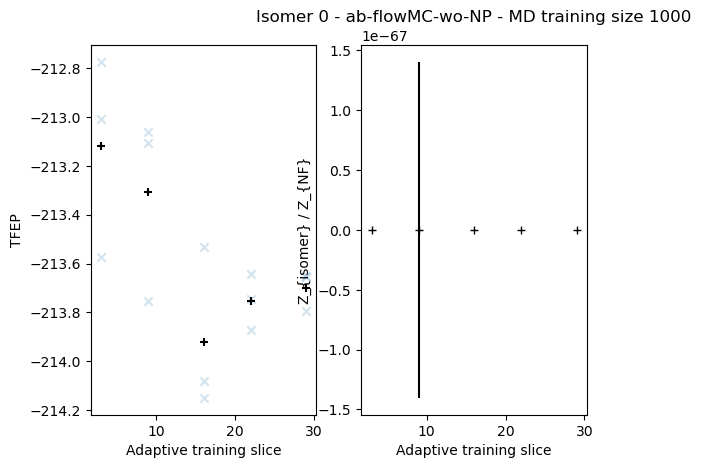

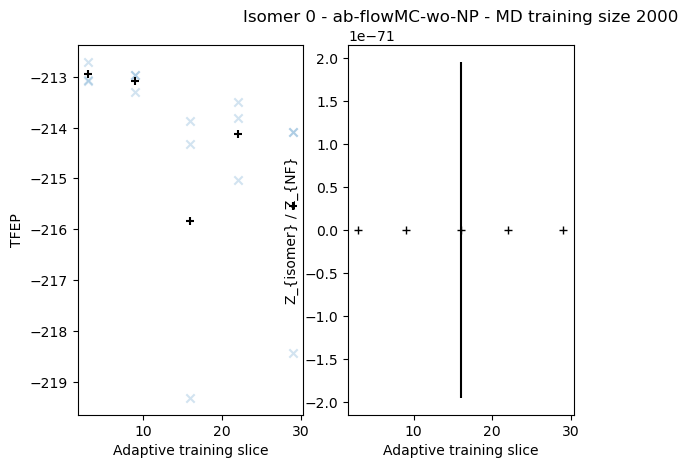

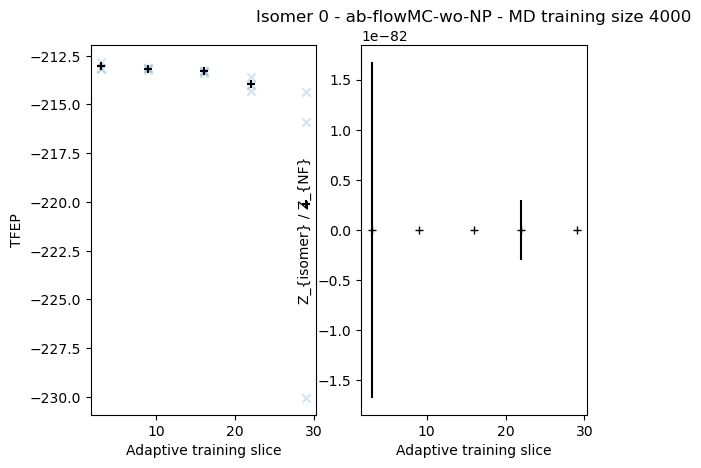

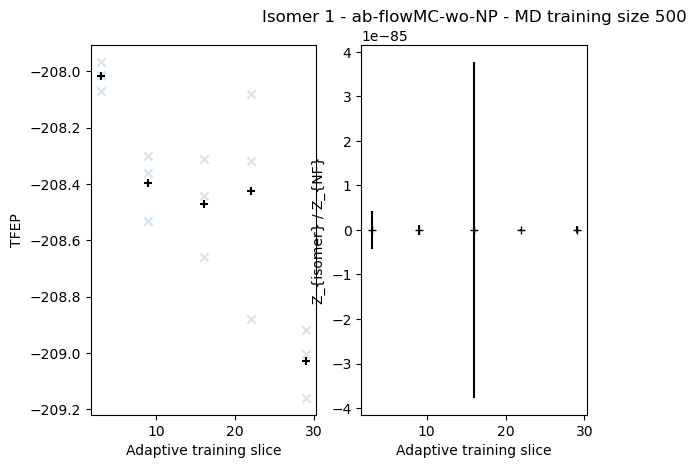

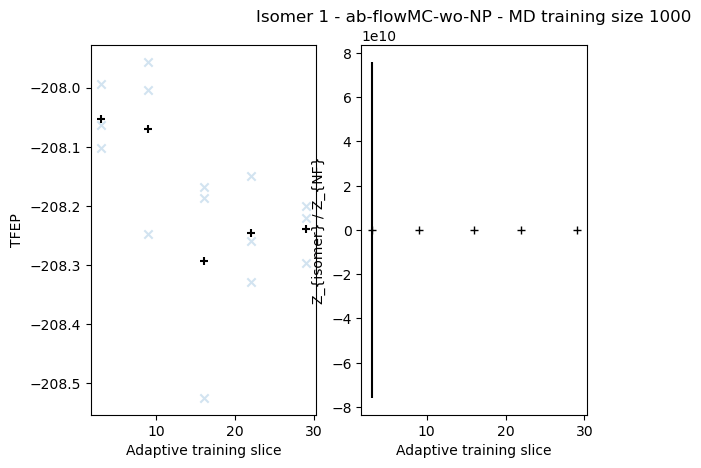

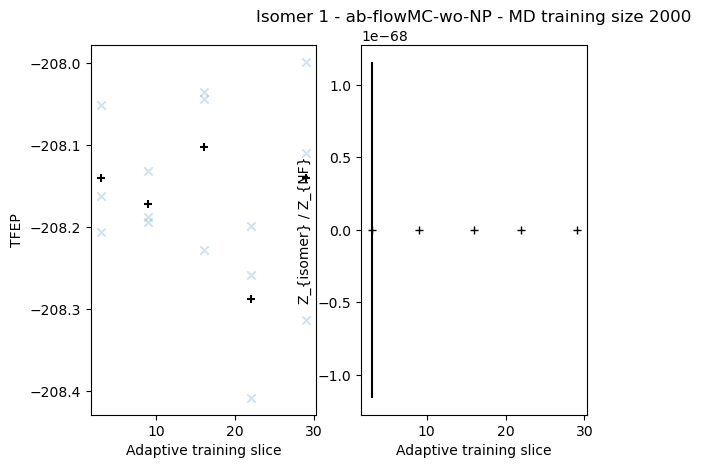

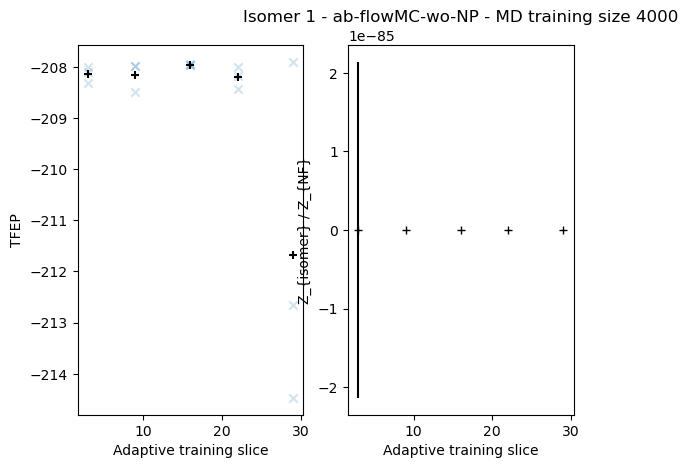

In [17]:
# flow that has been trained by dft 
kind = 'ab-flowMC-wo-NP'
batch_size = 1000 ## best trainings to be selected - not necessarily everywhere
df_args = dic_args[kind]

n_train_slice = 5
n_samples = 1000
n_training_slices_per_eval = 3
dic_results_TFPs = {}
for isomer_id in mode_labels:
    df_isomer = df_args.loc[(df_args['flow_batch_size'] == batch_size) & (df_args['isomer_label'] == isomer_id)]
    
    md_training_sizes = df_isomer['N'].values
    process_ids = df_isomer['process_id'].values

    
    dic_results_TFPs[isomer_id] = {}
    

    for md_training_size, process_id in zip(md_training_sizes, process_ids):
        print('Isomer {:d}, MD training size = {:d}, process_id {:d}'.format(isomer_id, md_training_size, process_id))
        models = load_models(isomer_id, process_id, project_path=subproject_path + '/1-adaptive/') 
        train_slices = (np.linspace(n_training_slices_per_eval, len(models)-2, n_train_slice)).astype(int)

        prop_samples, energy_target = load_samples_n_energies('xs_proposals', isomer_id, process_id, project_path=subproject_path + '/1-adaptive/')
        
        # mask = np.ones(prop_samples.shape[0], dtype=bool)
        # for n in range(30):
        #     mask[50 * n:50 * (n+1)] = False

        # prop_samples = prop_samples[mask]
        # energy_target = energy_target[mask]
        # print('Cleaned prop samples : ', prop_samples.shape[0], 'samples')

        n_chains = df_isomer.loc[df_isomer['process_id'] == process_id]['n_chains'].values[0]
        
        # prop_samples = prop_samples.reshape(-1, n_chains, 12)
        prop_samples = prop_samples.reshape(len(models) - 1, -1, 12)
        # energy_target = energy_target.reshape(-1, n_chains)
        energy_target = energy_target.reshape(len(models) - 1, -1)
        n_samples_avail = energy_target.shape[1] 
        n_trial = (n_samples_avail * n_training_slices_per_eval) // n_samples
        print(n_samples_avail, 'samples per training slice --> n_trial = {:d}'.format(n_trial))
        
        
        dic_results_TFPs[isomer_id][md_training_size] = {}

        plt.figure()
        axs = [plt.subplot(1,2,1), plt.subplot(1,2,2)]
        plt.title('Isomer {:d} - {:s} - MD training size {:d}'.format(isomer_id, kind, md_training_size))
        plt.sca(axs[0])
        plt.xlabel('Adaptive training slice')
        plt.ylabel('TFEP')
        plt.sca(axs[1])
        plt.xlabel('Adaptive training slice')
        plt.ylabel(r'Z_{isomer} / Z_{NF}')

        # plt.figure(figsize=(5 * n_train_slice / 1, 5 * 1))
        # plt.title('Isomer {:d} - {:s} - MD training size {:d}'.format(isomer_id, kind, md_training_size))
        # axs = [plt.subplot(1, int(n_train_slice // 1), i+1) for i in range(n_train_slice)]

        dic_results_TFPs[isomer_id][md_training_size]['means'] = []
        dic_results_TFPs[isomer_id][md_training_size]['stds'] = []
        dic_results_TFPs[isomer_id][md_training_size]['r_std_fromsum'] = []
        dic_results_TFPs[isomer_id][md_training_size]['train_slices'] = train_slices

        for t, train_slice in enumerate(train_slices):
            log_ratio_0_TFPs = []
            std_r_0_TFPs = []

            perm = np.random.permutation(n_samples_avail * n_training_slices_per_eval)
            prop_samples_t = prop_samples[train_slice-n_training_slices_per_eval:train_slice].reshape(-1, 12)
            energy_target_t = energy_target[train_slice-n_training_slices_per_eval:train_slice].reshape(-1)
            # print('prop_samples_t.shape = ', prop_samples_t.shape)
            for trial in range(n_trial):
                idx = perm[trial*n_samples:(trial+1)*n_samples]

                logprob_prop = (- models[train_slice].nll(prop_samples_t[idx])).detach().numpy()
                logprob_target = (- beta * energy_target_t[idx]).detach().numpy()
                logr_TFP_0, std_r_TFP_0 = compute_TFP_from_samples(logprob_prop, logprob_target)
                log_ratio_0_TFPs.append(logr_TFP_0)
                std_r_0_TFPs.append(std_r_TFP_0)

                
            dic_results_TFPs[isomer_id][md_training_size]['means'].append(np.array(log_ratio_0_TFPs).mean())
            dic_results_TFPs[isomer_id][md_training_size]['stds'].append(np.array(log_ratio_0_TFPs).std())
            dic_results_TFPs[isomer_id][md_training_size]['r_std_fromsum'].append(std_r_0_TFPs)

            plt.sca(axs[0])
            plt.scatter(np.ones(len(log_ratio_0_TFPs))*train_slice, log_ratio_0_TFPs, c='C0', marker='x', alpha=0.2)
            plt.scatter(train_slice, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')
            
            plt.sca(axs[1])
            plt.errorbar(train_slice, np.exp(np.array(log_ratio_0_TFPs).mean()), yerr=std_r_TFP_0, c='k', marker='+')

            
            # plt.sca(axs[t])
            # plt.scatter( - logprob_target / beta, - logprob_prop / beta)
            # plt.xlabel('DFT energies')
            # plt.ylabel('Flow negative log-likelihood')
            # plt.title('training slice = {:d}'.format(train_slice))

dic_results_TFPs_flow_dft = copy.deepcopy(dic_results_TFPs)

In [18]:
std_r_0_TFPs

[4.000426440980272e-90, 6.370731382722932e-89, 5.05693568669557e-90]

### 1.2 - ab-flowMC

Isomer 0, MD training size = 500, process_id 30019620
300 samples per training slice --> n_trial = 2
Isomer 0, MD training size = 1000, process_id 30019621
300 samples per training slice --> n_trial = 2
Isomer 0, MD training size = 2000, process_id 30019622
300 samples per training slice --> n_trial = 2
Isomer 0, MD training size = 4000, process_id 30019623
300 samples per training slice --> n_trial = 2
Isomer 1, MD training size = 500, process_id 30019624
300 samples per training slice --> n_trial = 2
Isomer 1, MD training size = 1000, process_id 30019625
300 samples per training slice --> n_trial = 2
Isomer 1, MD training size = 2000, process_id 30019626
300 samples per training slice --> n_trial = 2
Isomer 1, MD training size = 4000, process_id 30019627
300 samples per training slice --> n_trial = 2


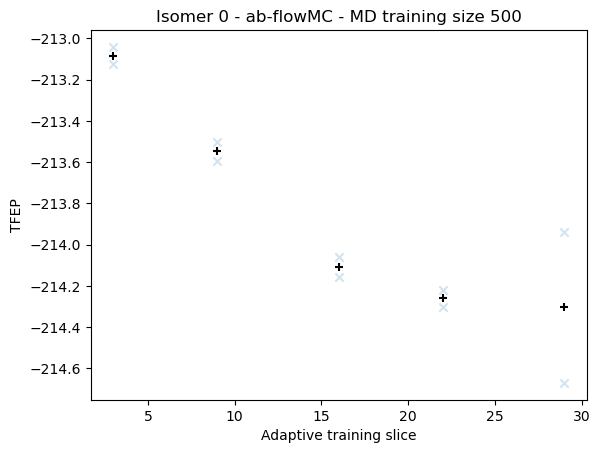

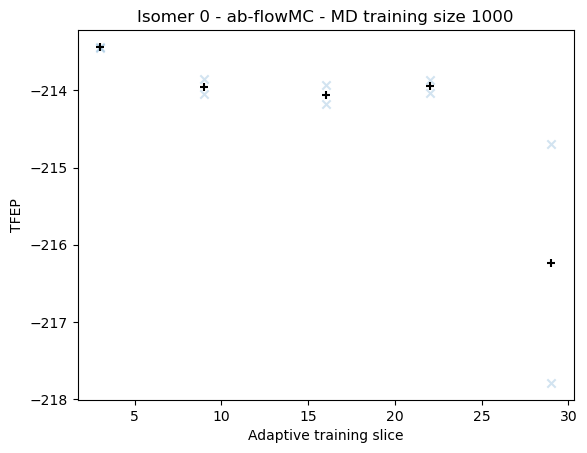

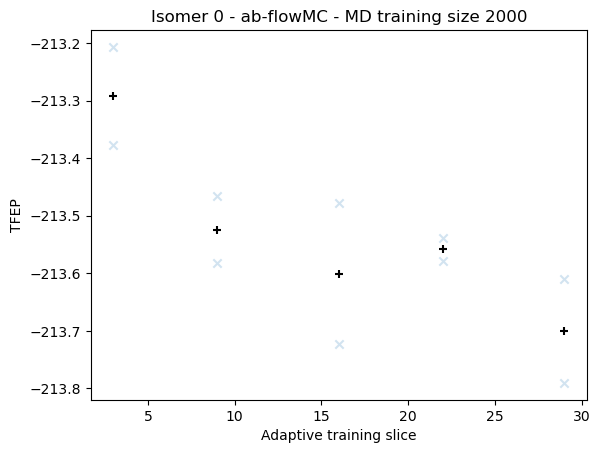

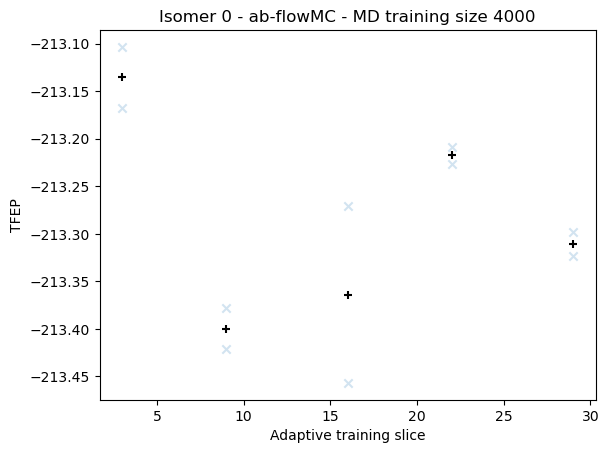

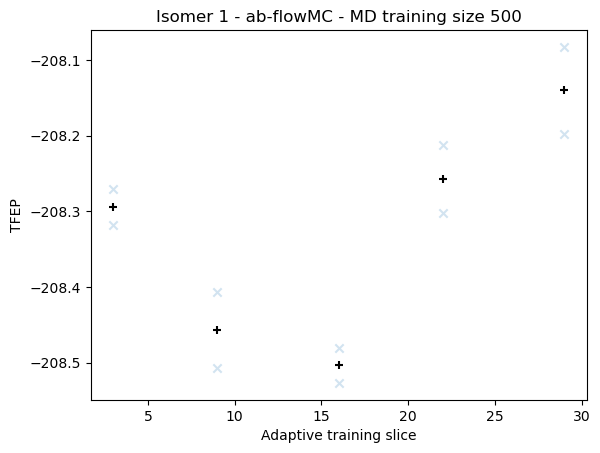

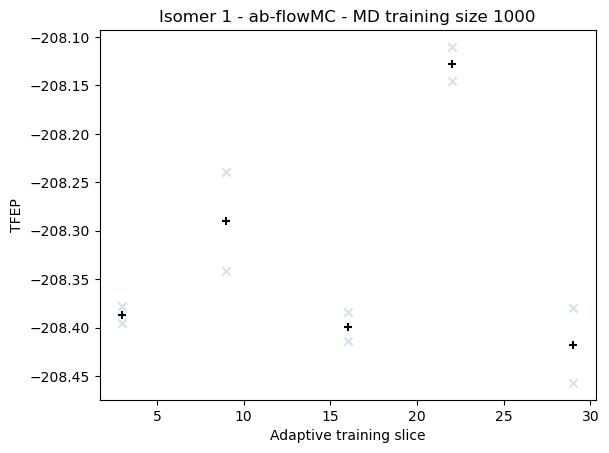

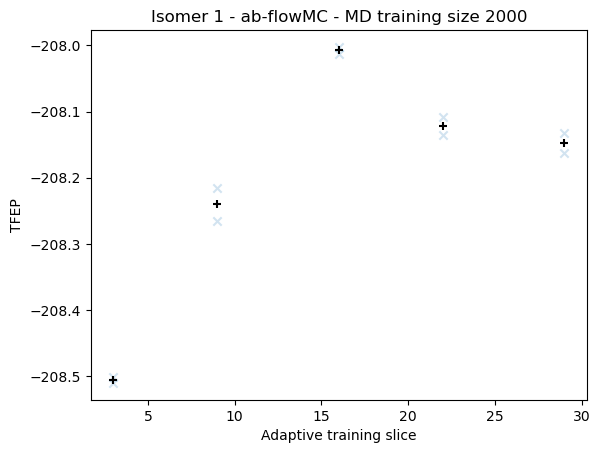

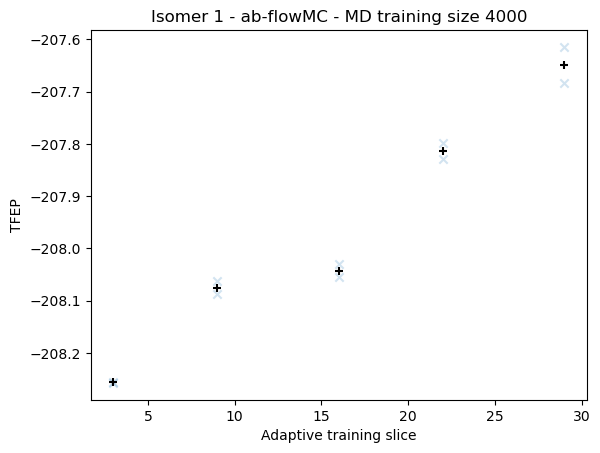

In [546]:
# flow that has been trained by dft 
kind = 'ab-flowMC'
batch_size = 1000 ## best trainings to be selected - not necessarily everywhere
df_args = dic_args[kind]

n_train_slice = 5
n_samples = 400
n_training_slices_per_eval = 3

dic_results_TFPs = {}
for isomer_id in mode_labels:
    df_isomer = df_args.loc[(df_args['flow_batch_size'] == batch_size) & (df_args['isomer_label'] == isomer_id)]
    
    md_training_sizes = df_isomer['N'].values
    process_ids = df_isomer['process_id'].values

    
    dic_results_TFPs[isomer_id] = {}
    

    for md_training_size, process_id in zip(md_training_sizes, process_ids):
        print('Isomer {:d}, MD training size = {:d}, process_id {:d}'.format(isomer_id, md_training_size, process_id))
        models = load_models(isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/') 
        train_slices = (np.linspace(n_training_slices_per_eval, len(models)-2, n_train_slice)).astype(int)

        prop_samples, energy_target = load_samples_n_energies('xs_proposals', isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/')
        
        # mask = np.ones(prop_samples.shape[0], dtype=bool)
        # for n in range(30):
        #     mask[50 * n:50 * (n+1)] = False

        # prop_samples = prop_samples[mask]
        # energy_target = energy_target[mask]
        # print('Cleaned prop samples : ', prop_samples.shape[0], 'samples')

        n_chains = df_isomer.loc[df_isomer['process_id'] == process_id]['n_chains'].values[0]
        
        # prop_samples = prop_samples.reshape(-1, n_chains, 12)
        prop_samples = prop_samples.reshape(len(models) - 1, -1, 12)
        # energy_target = energy_target.reshape(-1, n_chains)
        energy_target = energy_target.reshape(len(models) - 1, -1)
        n_samples_avail = energy_target.shape[1] 
        n_trial = (n_samples_avail * n_training_slices_per_eval) // n_samples
        print(n_samples_avail, 'samples per training slice --> n_trial = {:d}'.format(n_trial))
        
        
        dic_results_TFPs[isomer_id][md_training_size] = {}

        plt.figure()
        ax1 = plt.subplot(111)
        plt.title('Isomer {:d} - {:s} - MD training size {:d}'.format(isomer_id, kind, md_training_size))
        plt.xlabel('Adaptive training slice')
        plt.ylabel('TFEP')

        # plt.figure(figsize=(5 * n_train_slice / 1, 5 * 1))
        # plt.title('Isomer {:d} - {:s} - MD training size {:d}'.format(isomer_id, kind, md_training_size))
        # axs = [plt.subplot(1, int(n_train_slice // 1), i+1) for i in range(n_train_slice)]

        dic_results_TFPs[isomer_id][md_training_size]['means'] = []
        dic_results_TFPs[isomer_id][md_training_size]['stds'] = []
        dic_results_TFPs[isomer_id][md_training_size]['r_std_fromsum'] = []
        dic_results_TFPs[isomer_id][md_training_size]['train_slices'] = train_slices

        for t, train_slice in enumerate(train_slices):
            log_ratio_0_TFPs = []
            std_r_0_TFPs = []

            perm = np.random.permutation(n_samples_avail * n_training_slices_per_eval)
            prop_samples_t = prop_samples[train_slice-n_training_slices_per_eval:train_slice].reshape(-1, 12)
            energy_target_t = energy_target[train_slice-n_training_slices_per_eval:train_slice].reshape(-1)
            # print('prop_samples_t.shape = ', prop_samples_t.shape)
            for trial in range(n_trial):
                idx = perm[trial*n_samples:(trial+1)*n_samples]

                logprob_prop = (- models[train_slice].nll(prop_samples_t[idx])).detach().numpy()
                logprob_target = (- beta * energy_target_t[idx]).detach().numpy()
                logr_TFP_0, std_r_TFP_0 = compute_TFP_from_samples(logprob_prop, logprob_target)
                log_ratio_0_TFPs.append(logr_TFP_0)
                std_r_0_TFPs.append(std_r_TFP_0)

                
            dic_results_TFPs[isomer_id][md_training_size]['means'].append(np.array(log_ratio_0_TFPs).mean())
            dic_results_TFPs[isomer_id][md_training_size]['stds'].append(np.array(log_ratio_0_TFPs).std())
            dic_results_TFPs[isomer_id][md_training_size]['r_std_fromsum'].append(std_r_0_TFPs)

            plt.sca(ax1)
            plt.scatter(np.ones(len(log_ratio_0_TFPs))*train_slice, log_ratio_0_TFPs, c='C0', marker='x', alpha=0.2)
            plt.scatter(train_slice, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')
            
            # plt.sca(axs[t])
            # plt.scatter( - logprob_target / beta, - logprob_prop / beta)
            # plt.xlabel('DFT energies')
            # plt.ylabel('Flow negative log-likelihood')
            # plt.title('training slice = {:d}'.format(train_slice))

dic_results_TFPs_flow_dft_mlp = copy.deepcopy(dic_results_TFPs)

#### 1.2.2 - ab-flowMC using NP to make the prediction of the energy in the free energy density

Isomer 0, MD training size = 500, process_id 30019620
300 samples per training slice --> n_trial = 2
Isomer 0, MD training size = 1000, process_id 30019621
300 samples per training slice --> n_trial = 2
Isomer 0, MD training size = 2000, process_id 30019622
300 samples per training slice --> n_trial = 2
Isomer 0, MD training size = 4000, process_id 30019623
300 samples per training slice --> n_trial = 2
Isomer 1, MD training size = 500, process_id 30019624
300 samples per training slice --> n_trial = 2
Isomer 1, MD training size = 1000, process_id 30019625
300 samples per training slice --> n_trial = 2
Isomer 1, MD training size = 2000, process_id 30019626
300 samples per training slice --> n_trial = 2
Isomer 1, MD training size = 4000, process_id 30019627
300 samples per training slice --> n_trial = 2


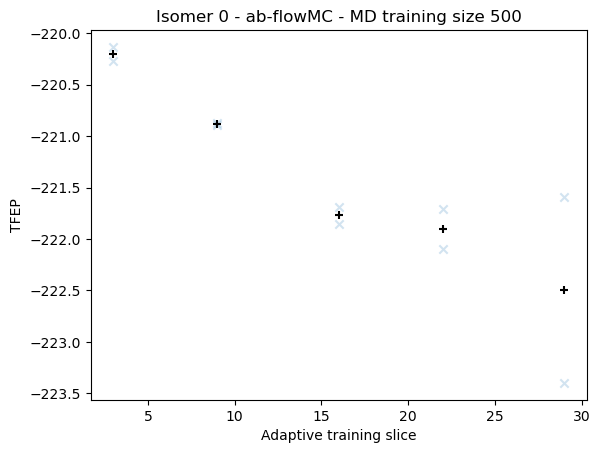

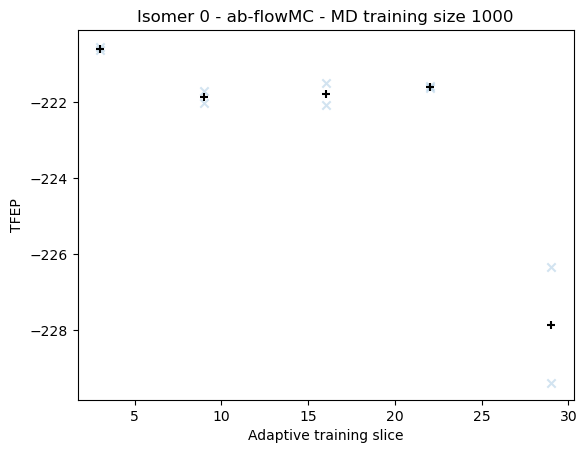

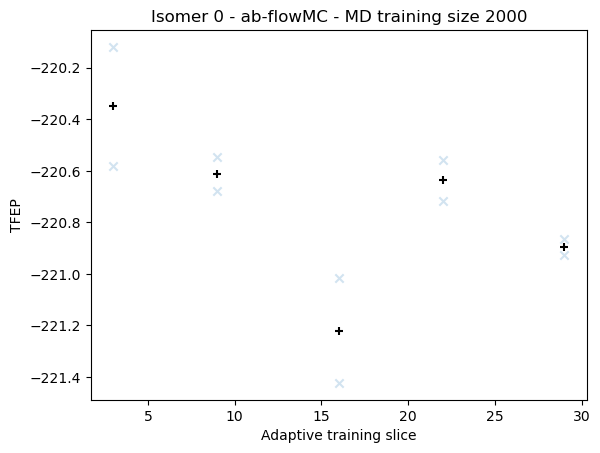

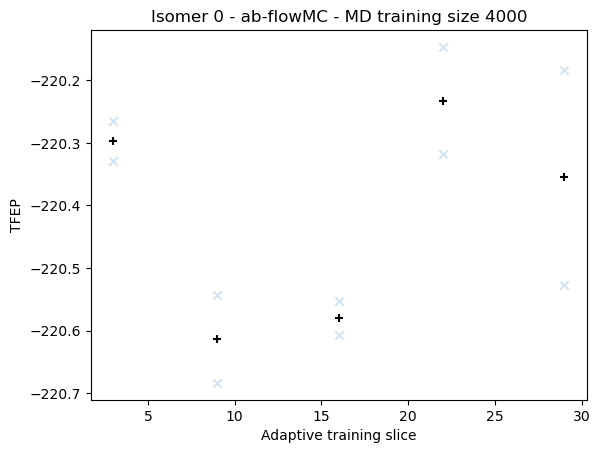

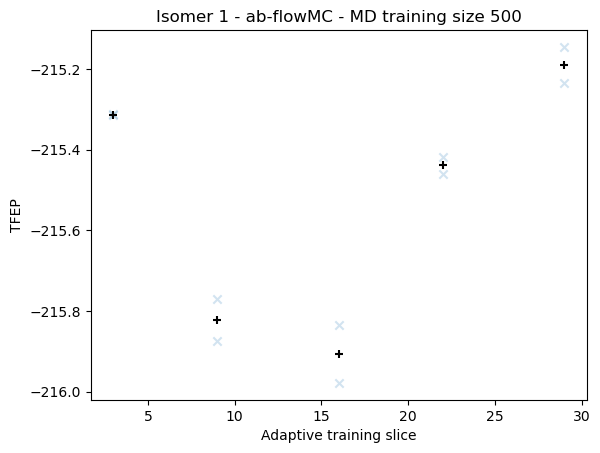

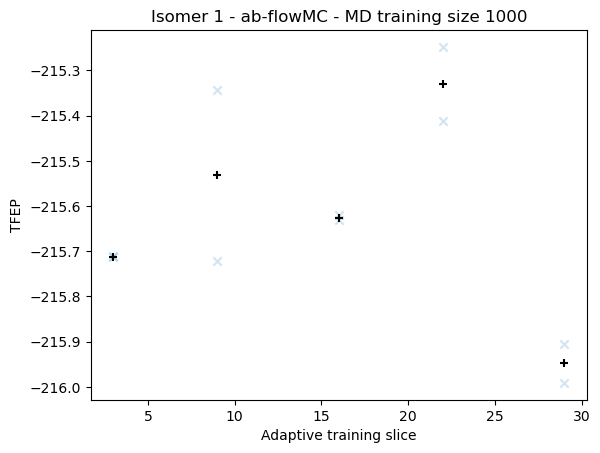

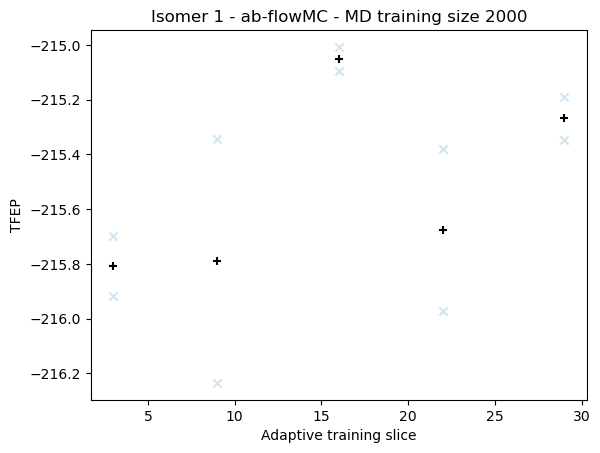

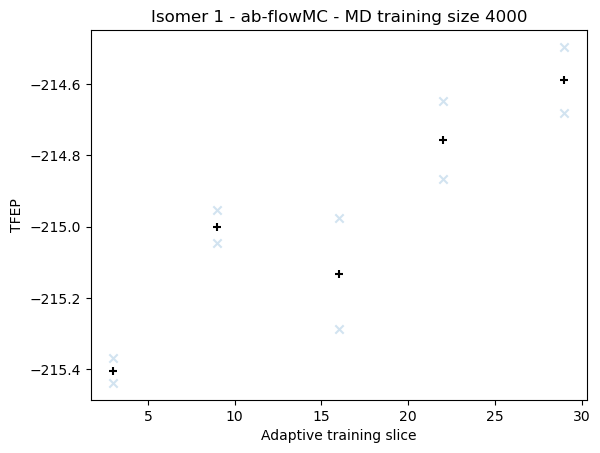

In [16]:
# flow that has been trained by dft 
kind = 'ab-flowMC'
batch_size = 1000 ## best trainings to be selected - not necessarily everywhere
df_args = dic_args[kind]

n_train_slice = 5
n_samples = 450
n_training_slices_per_eval = 3

dic_results_TFPs = {}
for isomer_id in mode_labels:
    df_isomer = df_args.loc[(df_args['flow_batch_size'] == batch_size) & (df_args['isomer_label'] == isomer_id)]
    
    md_training_sizes = df_isomer['N'].values
    process_ids = df_isomer['process_id'].values

    
    dic_results_TFPs[isomer_id] = {}
    

    for md_training_size, process_id in zip(md_training_sizes, process_ids):
        print('Isomer {:d}, MD training size = {:d}, process_id {:d}'.format(isomer_id, md_training_size, process_id))
        models = load_models(isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/') 
        mlp_models = load_mlp_models(isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/')
        train_slices = (np.linspace(n_training_slices_per_eval, len(models)-2, n_train_slice)).astype(int)

        prop_samples, energy_target = load_samples_n_energies('xs_proposals', isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/')
        
        # mask = np.ones(prop_samples.shape[0], dtype=bool)
        # for n in range(30):
        #     mask[50 * n:50 * (n+1)] = False

        # prop_samples = prop_samples[mask]
        # energy_target = energy_target[mask]
        # print('Cleaned prop samples : ', prop_samples.shape[0], 'samples')

        n_chains = df_isomer.loc[df_isomer['process_id'] == process_id]['n_chains'].values[0]
        
        # prop_samples = prop_samples.reshape(-1, n_chains, 12)
        prop_samples = prop_samples.reshape(len(models) - 1, -1, 12)
        # energy_target = energy_target.reshape(-1, n_chains)
        energy_target = energy_target.reshape(len(models) - 1, -1)
        n_samples_avail = energy_target.shape[1] 
        n_trial = (n_samples_avail * n_training_slices_per_eval) // n_samples
        print(n_samples_avail, 'samples per training slice --> n_trial = {:d}'.format(n_trial))
        
        
        dic_results_TFPs[isomer_id][md_training_size] = {}

        plt.figure()
        ax1 = plt.subplot(111)
        plt.title('Isomer {:d} - {:s} - MD training size {:d}'.format(isomer_id, kind, md_training_size))
        plt.xlabel('Adaptive training slice')
        plt.ylabel('TFEP')

        # plt.figure(figsize=(5 * n_train_slice / 1, 5 * 1))
        # plt.title('Isomer {:d} - {:s} - MD training size {:d}'.format(isomer_id, kind, md_training_size))
        # axs = [plt.subplot(1, int(n_train_slice // 1), i+1) for i in range(n_train_slice)]

        dic_results_TFPs[isomer_id][md_training_size]['means'] = []
        dic_results_TFPs[isomer_id][md_training_size]['stds'] = []
        dic_results_TFPs[isomer_id][md_training_size]['r_std_fromsum'] = []
        dic_results_TFPs[isomer_id][md_training_size]['train_slices'] = train_slices

        for t, train_slice in enumerate(train_slices):
            log_ratio_0_TFPs = []
            std_r_0_TFPs = []

            # energy_target = mlp_models[train_slice](prop_samples[train_slice]).detach().numpy()

            perm = np.random.permutation(n_samples_avail * n_training_slices_per_eval)
            prop_samples_t = prop_samples[train_slice-n_training_slices_per_eval:train_slice].reshape(-1, 12)
            energy_target_t = mlp_models[train_slice](prop_samples_t)
            # energy_target_t = energy_target[train_slice-n_training_slices_per_eval:train_slice].reshape(-1)
            # print('prop_samples_t.shape = ', prop_samples_t.shape)
            for trial in range(n_trial):
                idx = perm[trial*n_samples:(trial+1)*n_samples]

                logprob_prop = (- models[train_slice].nll(prop_samples_t[idx])).detach().numpy()
                logprob_target = (- beta * energy_target_t[idx]).detach().numpy()
                logr_TFP_0, std_r_TFP_0 = compute_TFP_from_samples(logprob_prop, logprob_target)
                log_ratio_0_TFPs.append(logr_TFP_0)
                std_r_0_TFPs.append(std_r_TFP_0)

                
            dic_results_TFPs[isomer_id][md_training_size]['means'].append(np.array(log_ratio_0_TFPs).mean())
            dic_results_TFPs[isomer_id][md_training_size]['stds'].append(np.array(log_ratio_0_TFPs).std())
            dic_results_TFPs[isomer_id][md_training_size]['r_std_fromsum'].append(std_r_0_TFPs)

            plt.sca(ax1)
            plt.scatter(np.ones(len(log_ratio_0_TFPs))*train_slice, log_ratio_0_TFPs, c='C0', marker='x', alpha=0.2)
            plt.scatter(train_slice, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')
            
            # plt.sca(axs[t])
            # plt.scatter( - logprob_target / beta, - logprob_prop / beta)
            # plt.xlabel('DFT energies')
            # plt.ylabel('Flow negative log-likelihood')
            # plt.title('training slice = {:d}'.format(train_slice))

dic_results_TFPs_flow_dft_mlp_target_mlp = copy.deepcopy(dic_results_TFPs)

In [19]:
std_r_0_TFPs

[nan, nan]

#### 1.2.3 - ab-flowMC using larger batches by relying purely on NP to make the prediction of the energy in the free energy density

Isomer 0, MD training size = 500, process_id 30019620
Isomer 0, MD training size = 1000, process_id 30019621
Isomer 0, MD training size = 2000, process_id 30019622
Isomer 0, MD training size = 4000, process_id 30019623
Isomer 1, MD training size = 500, process_id 30019624
Isomer 1, MD training size = 1000, process_id 30019625
Isomer 1, MD training size = 2000, process_id 30019626
Isomer 1, MD training size = 4000, process_id 30019627


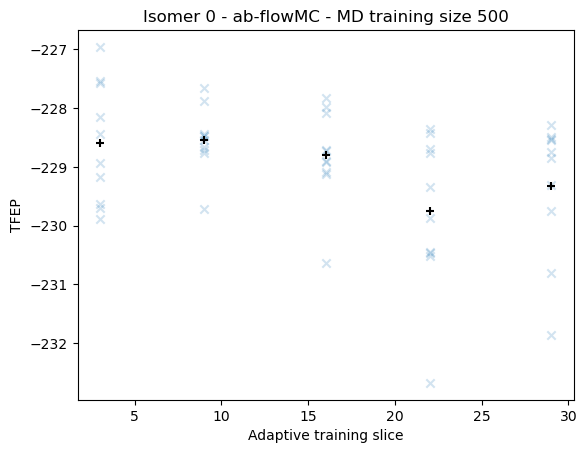

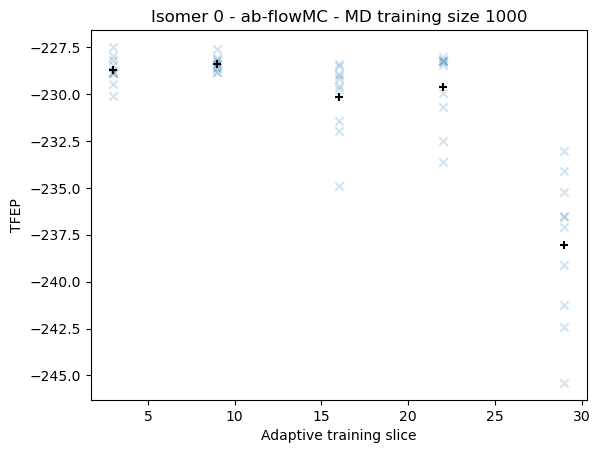

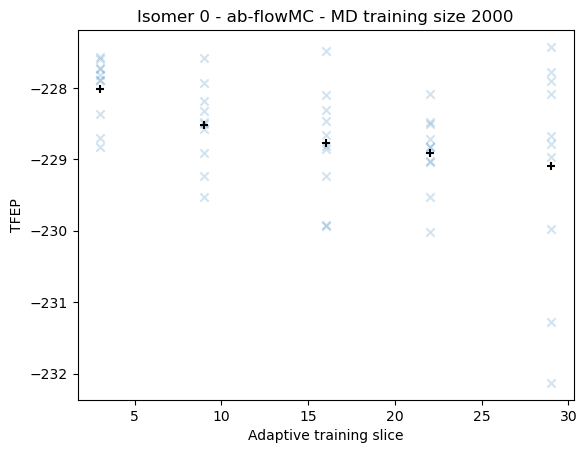

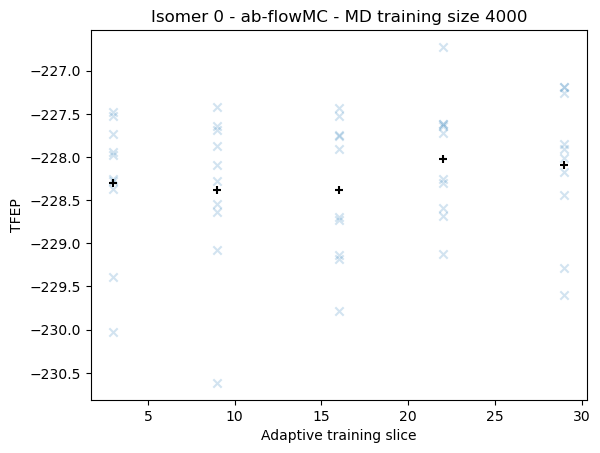

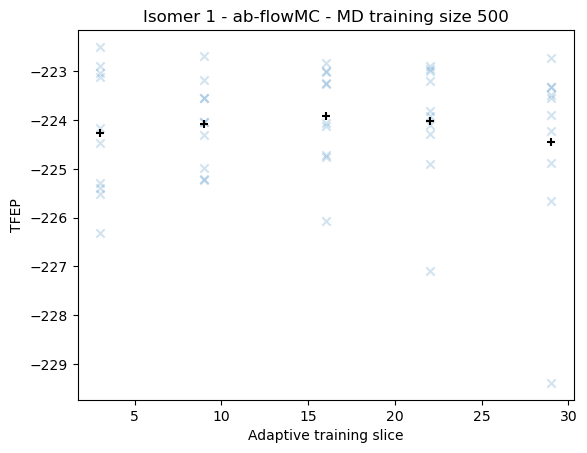

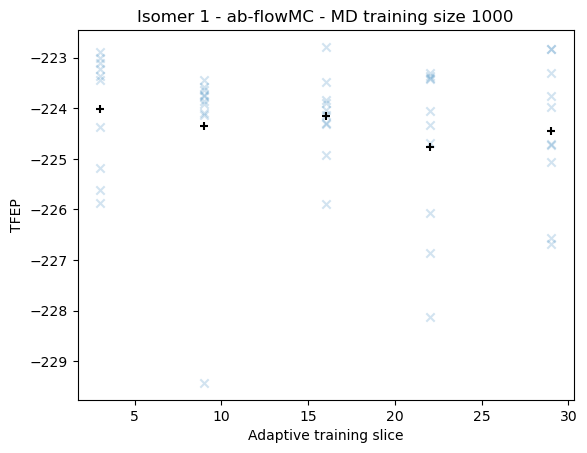

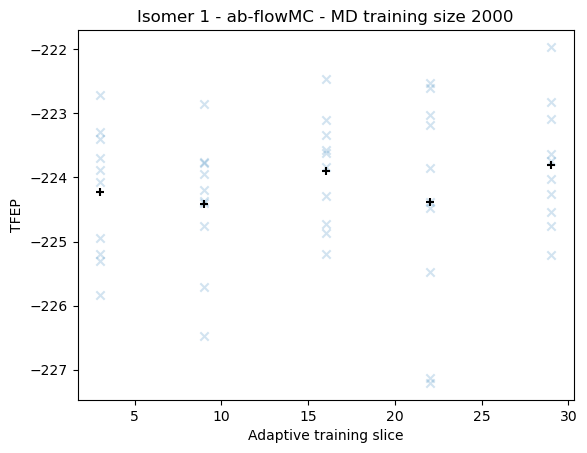

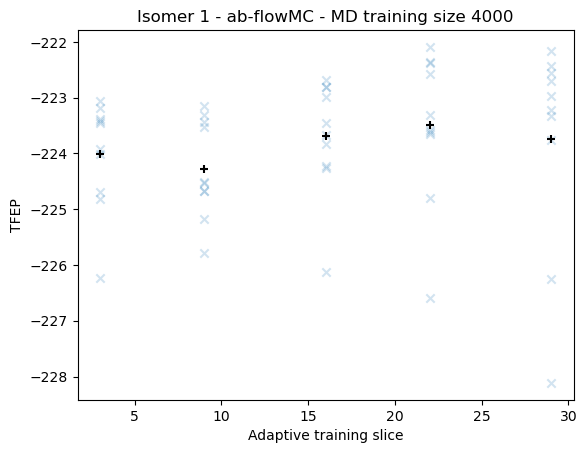

In [540]:
# flow that has been trained by dft 
kind = 'ab-flowMC'
batch_size = 1000 ## best trainings to be selected - not necessarily everywhere
df_args = dic_args[kind]

n_samples = 5000
n_trial = 10

dic_results_TFPs = {}
for isomer_id in mode_labels:
    df_isomer = df_args.loc[(df_args['flow_batch_size'] == batch_size) & (df_args['isomer_label'] == isomer_id)]
    
    md_training_sizes = df_isomer['N'].values
    process_ids = df_isomer['process_id'].values

    
    dic_results_TFPs[isomer_id] = {}
    

    for md_training_size, process_id in zip(md_training_sizes, process_ids):
        print('Isomer {:d}, MD training size = {:d}, process_id {:d}'.format(isomer_id, md_training_size, process_id))
        models = load_models(isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/') 
        mlp_models = load_mlp_models(isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/')
        train_slices = (np.linspace(n_training_slices_per_eval, len(models)-2, n_train_slice)).astype(int)

        dic_results_TFPs[isomer_id][md_training_size] = {}

        plt.figure()
        ax1 = plt.subplot(111)
        plt.title('Isomer {:d} - {:s} - MD training size {:d}'.format(isomer_id, kind, md_training_size))
        plt.xlabel('Adaptive training slice')
        plt.ylabel('TFEP')

        # plt.figure(figsize=(5 * n_train_slice / 1, 5 * 1))
        # plt.title('Isomer {:d} - {:s} - MD training size {:d}'.format(isomer_id, kind, md_training_size))
        # axs = [plt.subplot(1, int(n_train_slice // 1), i+1) for i in range(n_train_slice)]

        dic_results_TFPs[isomer_id][md_training_size]['means'] = []
        dic_results_TFPs[isomer_id][md_training_size]['stds'] = []
        dic_results_TFPs[isomer_id][md_training_size]['r_std_fromsum'] = []
        dic_results_TFPs[isomer_id][md_training_size]['train_slices'] = train_slices

        for t, train_slice in enumerate(train_slices):
            log_ratio_0_TFPs = []
            std_r_0_TFPs = []

    
            for trial in range(n_trial):
                prop_samples = models[train_slice].sample(n_samples)
                logprob_prop = (- models[train_slice].nll(prop_samples)).detach().numpy()
                logprob_target = (- beta * mlp_models[train_slice](prop_samples)).detach().numpy()
                logr_TFP_0, std_r_TFP_0 = compute_TFP_from_samples(logprob_prop, logprob_target)
                log_ratio_0_TFPs.append(logr_TFP_0)
                std_r_0_TFPs.append(std_r_TFP_0)

                
            dic_results_TFPs[isomer_id][md_training_size]['means'].append(np.array(log_ratio_0_TFPs).mean())
            dic_results_TFPs[isomer_id][md_training_size]['stds'].append(np.array(log_ratio_0_TFPs).std())
            dic_results_TFPs[isomer_id][md_training_size]['r_std_fromsum'].append(std_r_0_TFPs)

            plt.sca(ax1)
            plt.scatter(np.ones(len(log_ratio_0_TFPs))*train_slice, log_ratio_0_TFPs, c='C0', marker='x', alpha=0.2)
            plt.scatter(train_slice, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')
            
            # plt.sca(axs[t])
            # plt.scatter( - logprob_target / beta, - logprob_prop / beta)
            # plt.xlabel('DFT energies')
            # plt.ylabel('Flow negative log-likelihood')
            # plt.title('training slice = {:d}'.format(train_slice))

dic_results_TFPs_flow_dft_mlp_target_mlp_new_samples = copy.deepcopy(dic_results_TFPs)

### 1.3 Flows trained on MD 

Isomer 0, MD training size = 500, process_id 30064790
5000 samples per Md trainig size --> n_trial = 5
Isomer 0, MD training size = 1000, process_id 30064791
5000 samples per Md trainig size --> n_trial = 5
Isomer 0, MD training size = 2000, process_id 30064792
5000 samples per Md trainig size --> n_trial = 5
Isomer 0, MD training size = 4000, process_id 30064793
5000 samples per Md trainig size --> n_trial = 5
Isomer 1, MD training size = 500, process_id 30064794
5000 samples per Md trainig size --> n_trial = 5
Isomer 1, MD training size = 1000, process_id 30064795
5000 samples per Md trainig size --> n_trial = 5
Isomer 1, MD training size = 2000, process_id 30064796
5000 samples per Md trainig size --> n_trial = 5
Isomer 1, MD training size = 4000, process_id 30064797
5000 samples per Md trainig size --> n_trial = 5


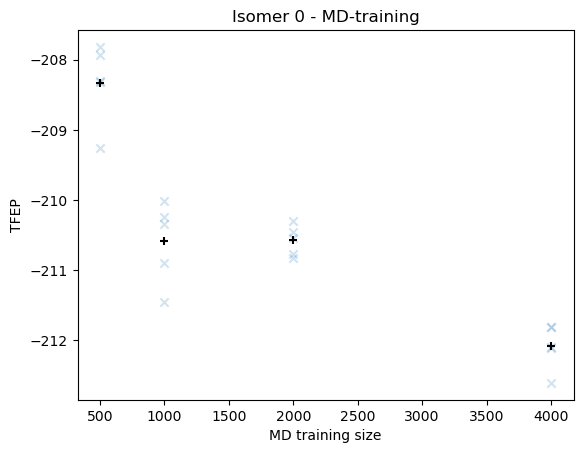

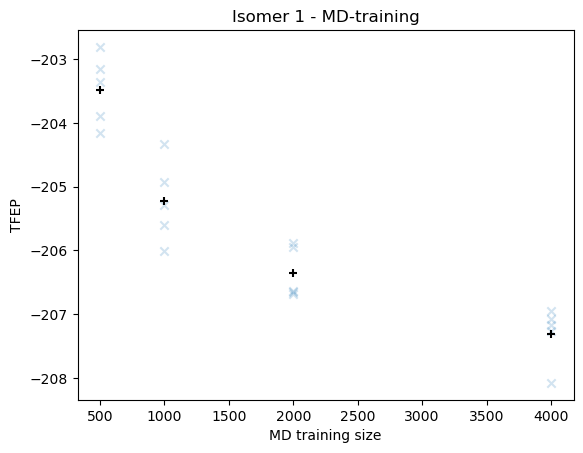

In [579]:
# flow that has been trained by dft 
kind = 'MD-training'
batch_size = 250 ## best trainings to be selected - not necessarily everywhere
df_args = dic_args[kind]
df_args_sample = dic_args['MD-sampling']

n_samples = 1000

dic_results_TFPs = {}
for isomer_id in mode_labels:
    df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id)]
    df_isomer_sample = df_args_sample.loc[(df_args_sample['isomer_label'] == isomer_id)]
    
    md_training_sizes = df_isomer['N'].values
    process_ids = df_isomer['process_id'].values
    samples_ids = df_isomer_sample['process_id'].values

    
    dic_results_TFPs[isomer_id] = {}

    dic_results_TFPs[isomer_id]['means'] = []
    dic_results_TFPs[isomer_id]['stds'] = []
    dic_results_TFPs[isomer_id]['md_training_size'] = md_training_sizes

    plt.figure()
    ax1 = plt.subplot(111)
    plt.title('Isomer {:d} - {:s}'.format(isomer_id, kind))
    plt.xlabel('MD training size')
    plt.ylabel('TFEP')
    

    for md_training_size, process_id, samples_id in zip(md_training_sizes, process_ids, samples_ids):
        print('Isomer {:d}, MD training size = {:d}, process_id {:d}'.format(isomer_id, md_training_size, process_id))
        models = load_models(isomer_id, process_id, project_path=subproject_path + '/3-flows-md/') 

        prop_samples, energy_target = load_samples_n_energies('MD-sampling', isomer_id, samples_id, project_path=subproject_path + '/3-flows-md/')
        
        n_samples_avail = energy_target.shape[0]
        n_trial = n_samples_avail // n_samples
        print(n_samples_avail, 'samples per Md trainig size --> n_trial = {:d}'.format(n_trial))
        perm = np.random.permutation(n_samples_avail)
        
        
        dic_results_TFPs[isomer_id][md_training_size] = {}
        log_ratio_0_TFPs = []
        # std_r_0_TFPs = []

        # energy_target_t = energy_target[train_slice-n_training_slices_per_eval:train_slice].reshape(-1)
        # print('prop_samples_t.shape = ', prop_samples_t.shape)
        for trial in range(n_trial):
            idx = perm[trial*n_samples:(trial+1)*n_samples]

            ## ONLY ONE MODEL WAS SAVED
            logprob_prop = (- models[0].nll(prop_samples[idx])).detach().numpy()
            logprob_target = (- beta * energy_target[idx]).detach().numpy()
            logr_TFP_0, std_r_TFP_0 = compute_TFP_from_samples(logprob_prop, logprob_target)
            log_ratio_0_TFPs.append(logr_TFP_0)
            # std_r_0_TFPs.append(std_r_TFP_0)

            
        dic_results_TFPs[isomer_id]['means'].append(np.array(log_ratio_0_TFPs).mean())
        dic_results_TFPs[isomer_id]['stds'].append(np.array(log_ratio_0_TFPs).std())
        # dic_results_TFPs[isomer_id]['r_std_fromsum'].append(std_r_0_TFPs)

        plt.sca(ax1)
        plt.scatter(np.ones(len(log_ratio_0_TFPs))*md_training_size, log_ratio_0_TFPs, c='C0', marker='x', alpha=0.2)
        plt.scatter(md_training_size, np.array(log_ratio_0_TFPs).mean(), c='k', marker='+')
        
        # plt.sca(axs[t])
        # plt.scatter( - logprob_target / beta, - logprob_prop / beta)
        # plt.xlabel('DFT energies')
        # plt.ylabel('Flow negative log-likelihood')
        # plt.title('training slice = {:d}'.format(train_slice))

dic_results_TFPs_flow_md = copy.deepcopy(dic_results_TFPs)

### 1.z Combining the plots

KeyError: 0

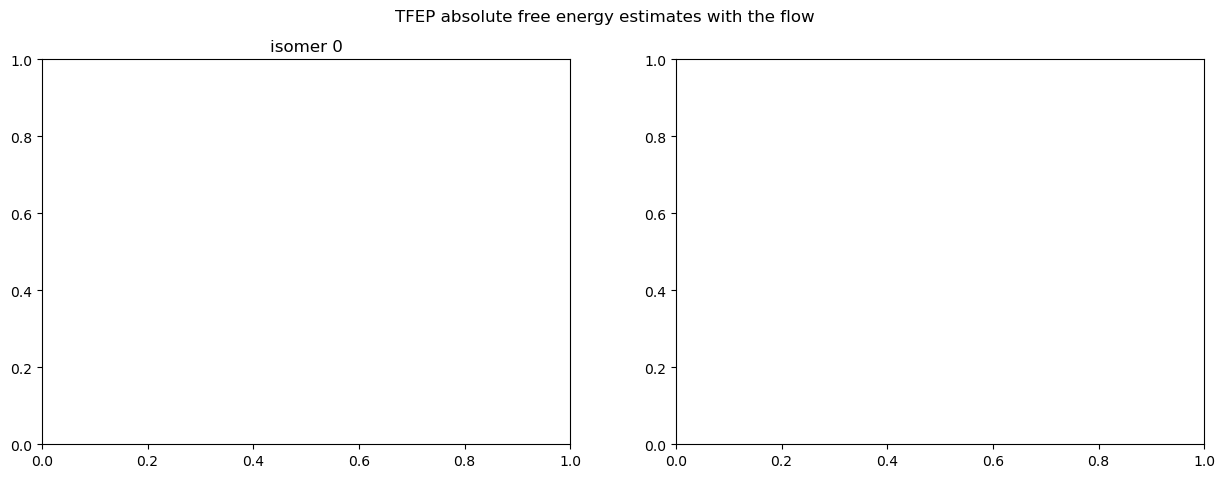

In [389]:
dic_results_TFPs_flow_dft
dic_results_TFPs_flow_md

plt.figure(figsize=(15, 5))
plt.suptitle('TFEP absolute free energy estimates with the flow')
axs = [plt.subplot(1, 2, i+1) for i in range(2)]
for isomer_id in mode_labels:
    plt.sca(axs[isomer_id])
    plt.title('isomer {:d}'.format(isomer_id))

    for md_training_size in dic_results_TFPs_flow_dft[isomer_id]['md_training_size']:

        ############################
        plt.plot(dic_results_TFPs_flow_dft[isomer_id]['md_training_size']['train_slices'],
                    dic_results_TFPs_flow_dft[isomer_id]['means'],  '.-',
                    label='flow_dft')
        # plt.fill_between(dic_results_TFPs_flow_dft['n_samples'],
        #                 np.array(dic_results_TFPs_flow_dft[isomer_id]['means']) - np.array(dic_results_TFPs_flow_dft[isomer_id]['']),
        #                 np.array(dic_results_TFPs_flow_dft[isomer_id]['means']) + np.array(dic_results_TFPs_flow_dft[isomer_id]['stds']),
        #                 alpha=0.2)
        plt.fill_between(dic_results_TFPs_flow_dft[isomer_id]['md_training_size']['train_slices'],
                        np.array(dic_results_TFPs_flow_dft[isomer_id]['means']) - np.array(dic_results_TFPs_flow_dft[isomer_id]['stds_logr']),
                        np.array(dic_results_TFPs_flow_dft[isomer_id]['means']) + np.array(dic_results_TFPs_flow_dft[isomer_id]['stds_logr']),
                        alpha=0.2)
        # ############################
        # plt.plot(dic_results_TFPs_flow_md['n_samples'], 
        #             dic_results_TFPs_flow_md[isomer_id]['means'], '.-',
        #             label='flow_md')
        
        # plt.fill_between(dic_results_TFPs_flow_md['n_samples'],
        #                 np.array(dic_results_TFPs_flow_md[isomer_id]['means']) - np.array(dic_results_TFPs_flow_md[isomer_id]['stds_logr']),
        #                 np.array(dic_results_TFPs_flow_md[isomer_id]['means']) + np.array(dic_results_TFPs_flow_md[isomer_id]['stds_logr']),
        #                 alpha=0.2)
        
        # ############################
        # plt.plot(dic_results_TFPs_flow_dft_mlp['n_samples'],
        #             dic_results_TFPs_flow_dft_mlp[isomer_id]['means'],  '.-',
        #             label='flow_dft_mlp')
        
        # plt.fill_between(dic_results_TFPs_flow_dft_mlp['n_samples'],
        #                 np.array(dic_results_TFPs_flow_dft_mlp[isomer_id]['means']) - np.array(dic_results_TFPs_flow_dft_mlp[isomer_id]['stds_logr']),
        #                 np.array(dic_results_TFPs_flow_dft_mlp[isomer_id]['means']) + np.array(dic_results_TFPs_flow_dft_mlp[isomer_id]['stds_logr']),
        #                 alpha=0.2)
        
        # ############################
        # plt.plot(dic_results_TFPs_flow_dft_mlp_target_mlp['n_samples'],
        #             dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id]['means'],  '.-',
        #             label='flow_dft_mlp_target_mlp')
        
        # plt.fill_between(dic_results_TFPs_flow_dft_mlp_target_mlp['n_samples'],
        #                 np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id]['means']) - np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id]['stds']),
        #                 np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id]['means']) + np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id]['stds']),
        #                 alpha=0.2)

    plt.legend()
    plt.xlabel('Adaptive training slice')
    plt.ylabel(r' $\beta \Delta F$') 
    

plt.figure()
plt.suptitle('Ratio of partition function - with TFEP free energy diff between isomers')
plt.plot(dic_results_TFPs_flow_dft['n_samples'],
            np.exp( np.array(dic_results_TFPs_flow_dft[0]['means']) - np.array(dic_results_TFPs_flow_dft[1]['means'])),  '.-',
            label='flow_dft')
# plt.plot(dic_results_TFPs_flow_md['n_samples'],
#             np.exp( np.array(dic_results_TFPs_flow_md[0]['means']) - np.array(dic_results_TFPs_flow_md[1]['means'])),  '.-',
#             label='flow_md')
# plt.plot(dic_results_TFPs_flow_dft_mlp['n_samples'],
#             np.exp( np.array(dic_results_TFPs_flow_dft_mlp[0]['means']) - np.array(dic_results_TFPs_flow_dft_mlp[1]['means'])),  '.-',
#             label='flow_dft_mlp')
# plt.plot(dic_results_TFPs_flow_dft_mlp_target_mlp['n_samples'],
#             np.exp(np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[0]['means']) - np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[1]['means'])),  '.-',
#             label='flow_dft_mlp_target_mlp')
plt.ylabel('Ratio of partition functions')

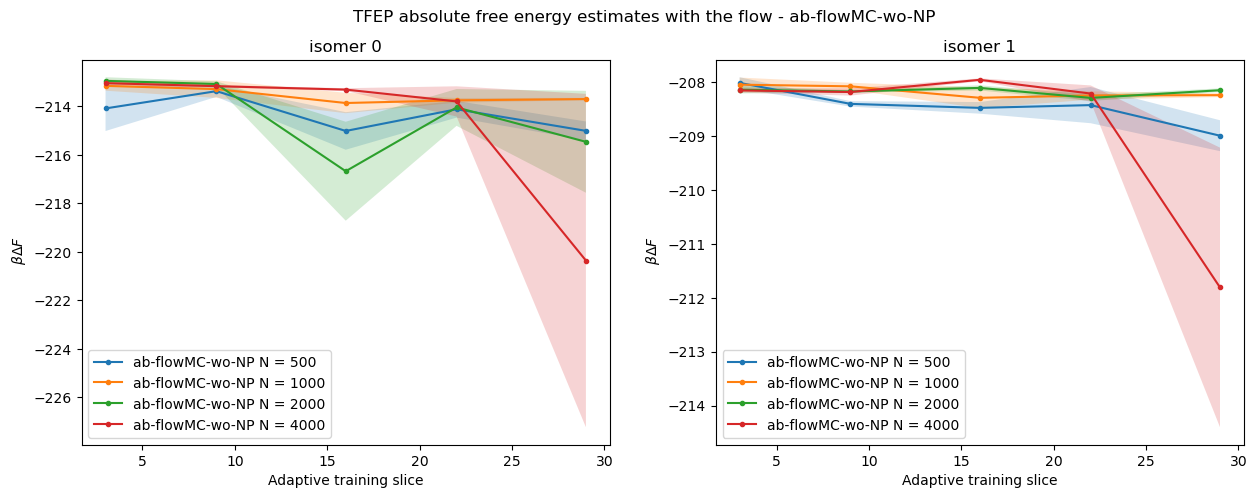

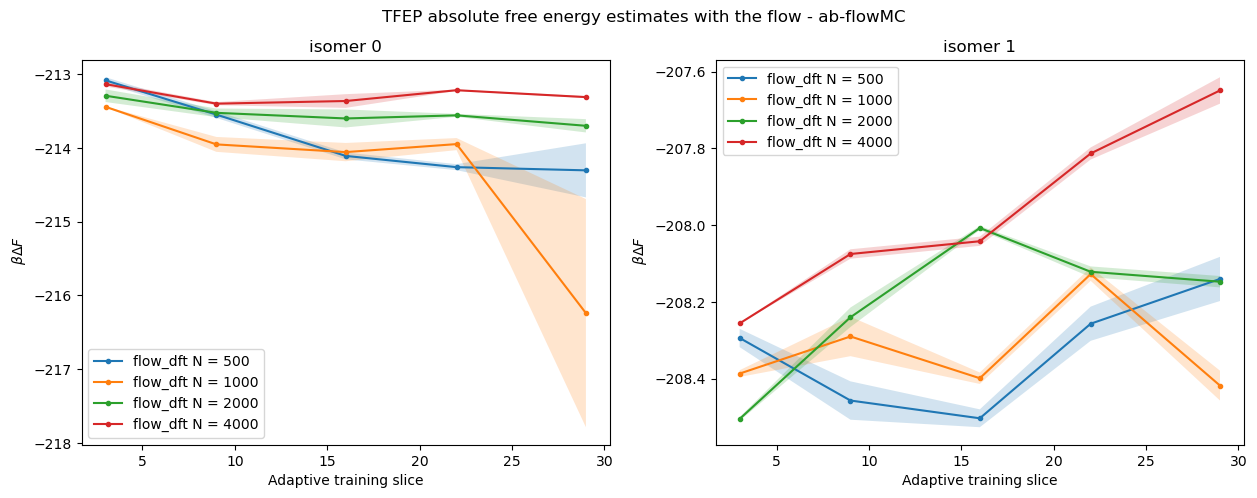

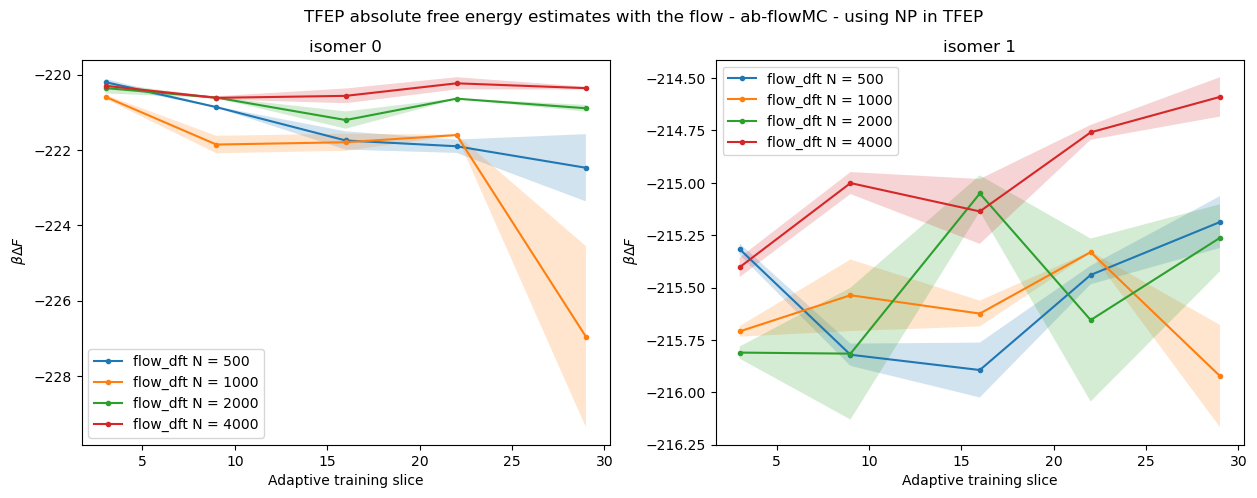

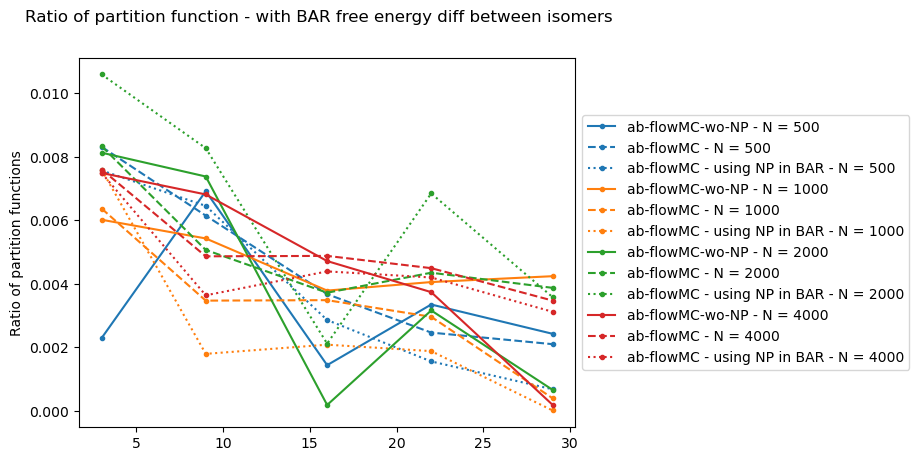

In [549]:

############################ ab-flowMC-wo-NP
plt.figure(figsize=(15, 5))
plt.suptitle('TFEP absolute free energy estimates with the flow - ab-flowMC-wo-NP')
for md_training_size in dic_results_TFPs_flow_dft[isomer_id].keys():
    

    
    axs = [plt.subplot(1, 2, i+1) for i in range(2)]
    for isomer_id in mode_labels:
        plt.sca(axs[isomer_id])
        plt.title('isomer {:d}'.format(isomer_id))

        plt.plot(dic_results_TFPs_flow_dft[isomer_id][md_training_size]['train_slices'],
                    dic_results_TFPs_flow_dft[isomer_id][md_training_size]['means'],  '.-',
                    label='ab-flowMC-wo-NP N = {:d}'.format(md_training_size))
        plt.fill_between(dic_results_TFPs_flow_dft[isomer_id][md_training_size]['train_slices'],
                        np.array(dic_results_TFPs_flow_dft[isomer_id][md_training_size]['means']) - np.array(dic_results_TFPs_flow_dft[isomer_id][md_training_size]['stds']),
                        np.array(dic_results_TFPs_flow_dft[isomer_id][md_training_size]['means']) + np.array(dic_results_TFPs_flow_dft[isomer_id][md_training_size]['stds']),
                        alpha=0.2)
        plt.legend()
        plt.xlabel('Adaptive training slice')
        plt.ylabel(r' $\beta \Delta F$') 


############################ ab-flowMC
plt.figure(figsize=(15, 5))
plt.suptitle('TFEP absolute free energy estimates with the flow - ab-flowMC')
for md_training_size in dic_results_TFPs_flow_dft_mlp[isomer_id].keys():
    
    axs = [plt.subplot(1, 2, i+1) for i in range(2)]
    for isomer_id in mode_labels:
        plt.sca(axs[isomer_id])
        plt.title('isomer {:d}'.format(isomer_id))

        plt.plot(dic_results_TFPs_flow_dft_mlp[isomer_id][md_training_size]['train_slices'],
                    dic_results_TFPs_flow_dft_mlp[isomer_id][md_training_size]['means'],  '.-',
                    label='flow_dft N = {:d}'.format(md_training_size))
        plt.fill_between(dic_results_TFPs_flow_dft_mlp[isomer_id][md_training_size]['train_slices'],
                        np.array(dic_results_TFPs_flow_dft_mlp[isomer_id][md_training_size]['means']) - np.array(dic_results_TFPs_flow_dft_mlp[isomer_id][md_training_size]['stds']),
                        np.array(dic_results_TFPs_flow_dft_mlp[isomer_id][md_training_size]['means']) + np.array(dic_results_TFPs_flow_dft_mlp[isomer_id][md_training_size]['stds']),
                        alpha=0.2)
        plt.legend()
        plt.xlabel('Adaptive training slice')
        plt.ylabel(r' $\beta \Delta F$') 


############################ ab-flowMC - target mlp
plt.figure(figsize=(15, 5))
plt.suptitle('TFEP absolute free energy estimates with the flow - ab-flowMC - using NP in TFEP')
for md_training_size in dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id].keys():
    
    axs = [plt.subplot(1, 2, i+1) for i in range(2)]
    for isomer_id in mode_labels:
        plt.sca(axs[isomer_id])
        plt.title('isomer {:d}'.format(isomer_id))

        plt.plot(dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['train_slices'],
                    dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['means'],  '.-',
                    label='flow_dft N = {:d}'.format(md_training_size))
        plt.fill_between(dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['train_slices'],
                        np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['means']) - np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['stds']),
                        np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['means']) + np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['stds']),
                        alpha=0.2)
        plt.legend()
        plt.xlabel('Adaptive training slice')
        plt.ylabel(r' $\beta \Delta F$') 



plt.figure()
plt.suptitle('Ratio of partition function - with BAR free energy diff between isomers')
for c,md_training_size in enumerate(dic_results_TFPs_flow_dft[isomer_id].keys()):
    plt.plot(dic_results_TFPs_flow_dft[isomer_id][md_training_size]['train_slices'],
                np.exp( np.array(dic_results_TFPs_flow_dft[0][md_training_size]['means']) - np.array(dic_results_TFPs_flow_dft[1][md_training_size]['means'])),  '.-',
                label='ab-flowMC-wo-NP - N = {:d}'.format(md_training_size), c='C{:d}'.format(c), ls='-')
    plt.plot(dic_results_TFPs_flow_dft_mlp[isomer_id][md_training_size]['train_slices'],
                np.exp( np.array(dic_results_TFPs_flow_dft_mlp[0][md_training_size]['means']) - np.array(dic_results_TFPs_flow_dft_mlp[1][md_training_size]['means'])),  '.-',
                label='ab-flowMC - N = {:d}'.format(md_training_size), c='C{:d}'.format(c), ls='--')
    plt.plot(dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['train_slices'],
                np.exp(np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[0][md_training_size]['means']) - np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[1][md_training_size]['means'])),  '.-',
                label='ab-flowMC - using NP in BAR - N = {:d}'.format(md_training_size), c='C{:d}'.format(c), ls=':')
plt.ylabel('Ratio of partition functions')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

Text(0, 0.5, ' $\\beta \\Delta F$')

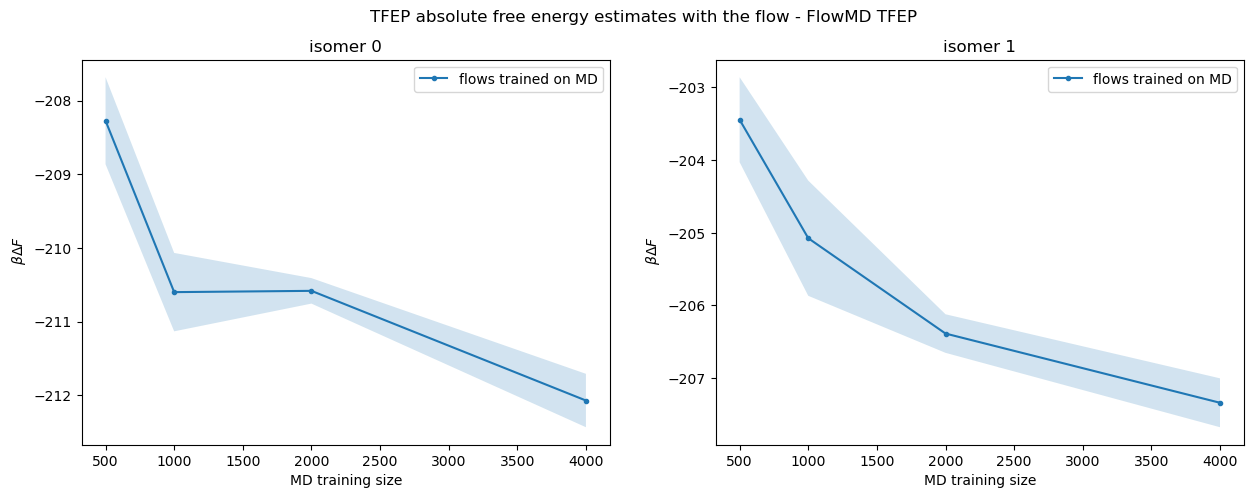

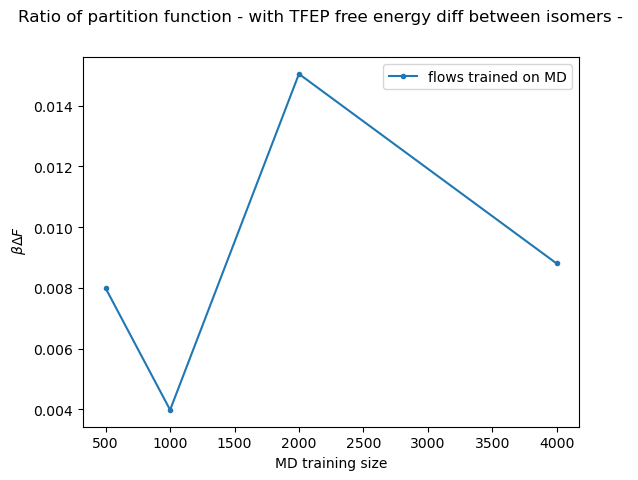

In [557]:
plt.figure(figsize=(15, 5))
plt.suptitle('TFEP absolute free energy estimates with the flow - FlowMD TFEP')

    
axs = [plt.subplot(1, 2, i+1) for i in range(2)]
for isomer_id in mode_labels:
    plt.sca(axs[isomer_id])
    plt.title('isomer {:d}'.format(isomer_id))

    plt.plot(dic_results_TFPs_flow_md[isomer_id]['md_training_size'],
                dic_results_TFPs_flow_md[isomer_id]['means'],  '.-', label='flows trained on MD')
    plt.fill_between(dic_results_TFPs_flow_md[isomer_id]['md_training_size'],
                    np.array(dic_results_TFPs_flow_md[isomer_id]['means']) - np.array(dic_results_TFPs_flow_md[isomer_id]['stds']),
                    np.array(dic_results_TFPs_flow_md[isomer_id]['means']) + np.array(dic_results_TFPs_flow_md[isomer_id]['stds']),
                    alpha=0.2)
    plt.legend()
    plt.xlabel('MD training size')
    plt.ylabel(r' $\beta \Delta F$') 

plt.title('isomer {:d}'.format(isomer_id))

plt.figure()
plt.suptitle('Ratio of partition function - with TFEP free energy diff between isomers - ')
plt.plot(dic_results_TFPs_flow_md[isomer_id]['md_training_size'],
            np.exp( np.array(dic_results_TFPs_flow_md[0]['means']) - np.array(dic_results_TFPs_flow_md[1]['means'])),  '.-', label='flows trained on MD')
# plt.fill_between(dic_results_TFPs_flow_md[isomer_id]['md_training_size'],
#                 np.array(dic_results_TFPs_flow_md[isomer_id]['means']) - np.array(dic_results_TFPs_flow_md[isomer_id]['stds']),
#                 np.array(dic_results_TFPs_flow_md[isomer_id]['means']) + np.array(dic_results_TFPs_flow_md[isomer_id]['stds']),
#                 alpha=0.2)
plt.legend()
plt.xlabel('MD training size')
plt.ylabel(r' $\beta \Delta F$') 

In [ ]:
plt.figure()
plt.suptitle('Ratio of partition function - with BAR free energy diff between isomers')
for c,md_training_size in enumerate(dic_results_TFPs_flow_dft[isomer_id].keys()):
    plt.plot(dic_results_TFPs_flow_dft[isomer_id][md_training_size]['train_slices'],
                np.exp( np.array(dic_results_TFPs_flow_dft[0][md_training_size]['means']) - np.array(dic_results_TFPs_flow_dft[1][md_training_size]['means'])),  '.-',
                label='ab-flowMC-wo-NP - N = {:d}'.format(md_training_size), c='C{:d}'.format(c), ls='-')
    plt.plot(dic_results_TFPs_flow_dft_mlp[isomer_id][md_training_size]['train_slices'],
                np.exp( np.array(dic_results_TFPs_flow_dft_mlp[0][md_training_size]['means']) - np.array(dic_results_TFPs_flow_dft_mlp[1][md_training_size]['means'])),  '.-',
                label='ab-flowMC - N = {:d}'.format(md_training_size), c='C{:d}'.format(c), ls='--')
    plt.plot(dic_results_TFPs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['train_slices'],
                np.exp(np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[0][md_training_size]['means']) - np.array(dic_results_TFPs_flow_dft_mlp_target_mlp[1][md_training_size]['means'])),  '.-',
                label='ab-flowMC - using NP in BAR - N = {:d}'.format(md_training_size), c='C{:d}'.format(c), ls=':')
plt.ylabel('Ratio of partition functions')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

## 2 - BAR computations

### 2.1 MD samples and MD trained flow

In [572]:
from flonacomldft.utils.data_processing import split_data_from_dataframe


path_datasets = subproject_path + 'database/andersen/datasets'
md_training_sizes = [500, 1000, 2000, 4000]

dim = 12

dic_md_training_datasets = {}

for isomer_id in mode_labels:
    dic_md_training_datasets[isomer_id] = {}

    for N in md_training_sizes:
        dic_md_training_datasets[isomer_id][N] = {}

        print('N = {:d}'.format(N))
    
        data = load_csv_file('is{:d}_{:s}_train.csv'.format(mode_labels[i], 'flow'),
                      path=path_datasets)[:N, :dim+2]

        # train_md, test_md = list(split_data_from_dataframe(data, 0.8, sk_seed=42))
        # dic_md_training_datasets[isomer_id][N]['train'] = train_md
        # dic_md_training_datasets[isomer_id][N]['test'] = test_md
        dic_md_training_datasets[isomer_id][N] = data
    
    

N = 500
N = 1000
N = 2000
N = 4000
N = 500
N = 1000
N = 2000
N = 4000


Isomer 0, MD training size = 500, process_id 30064790
500 samples per Md trainig size --> n_trial = 5
dict_keys([0])
Isomer 0, MD training size = 1000, process_id 30064791
1000 samples per Md trainig size --> n_trial = 10
dict_keys([0])
Isomer 0, MD training size = 2000, process_id 30064792
2000 samples per Md trainig size --> n_trial = 20
dict_keys([0])
Isomer 0, MD training size = 4000, process_id 30064793
4000 samples per Md trainig size --> n_trial = 40
dict_keys([0])
Isomer 1, MD training size = 500, process_id 30064794
500 samples per Md trainig size --> n_trial = 5
dict_keys([0, 1])
Isomer 1, MD training size = 1000, process_id 30064795
1000 samples per Md trainig size --> n_trial = 10
dict_keys([0, 1])
Isomer 1, MD training size = 2000, process_id 30064796
2000 samples per Md trainig size --> n_trial = 20
dict_keys([0, 1])
Isomer 1, MD training size = 4000, process_id 30064797
4000 samples per Md trainig size --> n_trial = 40
dict_keys([0, 1])


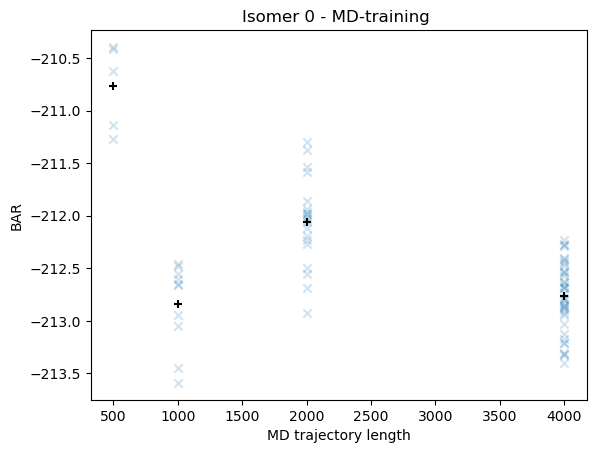

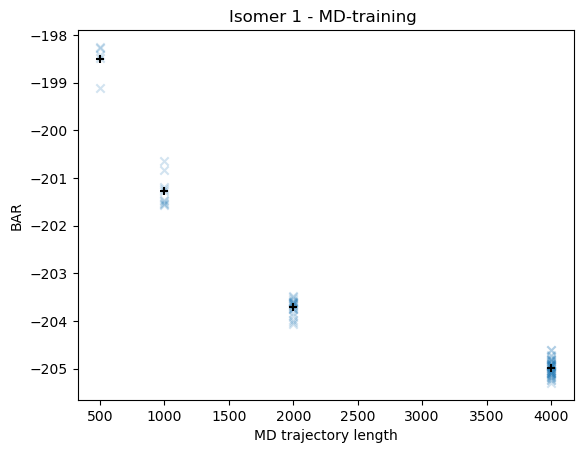

In [600]:
# flow that has been trained by dft 
kind = 'MD-training'
batch_size = 1000 ## best trainings to be selected - not necessarily everywhere
df_args = dic_args[kind]

df_args_sample = dic_args['MD-sampling']

n_train_slice = 5
n_samples = 100
n_training_slices_per_eval = 2

dic_results_BARs = {}
for isomer_id in mode_labels:
    df_isomer = df_args.loc[(df_args['isomer_label'] == isomer_id)]
    df_isomer_sample = df_args_sample.loc[(df_args_sample['isomer_label'] == isomer_id)]
    
    md_training_sizes = df_isomer['N'].values
    process_ids = df_isomer['process_id'].values
    samples_ids = df_isomer_sample['process_id'].values

    dic_results_BARs[isomer_id] = {}
    dic_results_BARs[isomer_id]['md_training_size'] = md_training_sizes
    dic_results_BARs[isomer_id]['means'] = []
    dic_results_BARs[isomer_id]['stds'] = []

    plt.figure()
    ax1 = plt.subplot(111)
    plt.title('Isomer {:d} - {:s} '.format(isomer_id, kind))
    plt.xlabel('MD trajectory length')
    plt.ylabel('BAR')


    for md_training_size, process_id, samples_id in zip(md_training_sizes, process_ids, samples_ids):
        print('Isomer {:d}, MD training size = {:d}, process_id {:d}'.format(isomer_id, md_training_size, process_id))
        models = load_models(isomer_id, process_id, project_path=subproject_path + '/3-flows-md/') 

        prop_samples, prop_energy_target = load_samples_n_energies('MD-sampling', isomer_id, samples_id, project_path=subproject_path + '/3-flows-md/')
        mc_samples = dic_md_training_datasets[isomer_id][md_training_size][:, :12]
        mc_energy_target = dic_md_training_datasets[isomer_id][md_training_size][:, 12]
        
        # # prop_samples = prop_samples.reshape(-1, n_chains, 12)
        # prop_samples = prop_samples.reshape(len(models) - 1, -1, 12)
        # # energy_target = energy_target.reshape(-1, n_chains)
        # prop_energy_target = prop_energy_target.reshape(len(models) - 1, -1)

        # mc_samples = mc_samples.reshape(len(models) - 1, -1, 12)
        # mc_energy_target = mc_energy_target.reshape(len(models) - 1, -1)

        
        n_samples_avail = mc_samples.shape[0] #prop_energy_target.shape[0]
        n_trial = n_samples_avail // n_samples
        print(n_samples_avail, 'samples per Md trainig size --> n_trial = {:d}'.format(n_trial))
        perm = np.random.permutation(n_samples_avail)
        

        log_ratio_0_BARs = []
        log_err_0_BARs = []

        prop = models[0]

        # print('prop_samples_t.shape = ', prop_samples_t.shape)
        for trial in range(n_trial):
            # idx = perm[trial*n_samples:(trial+1)*n_samples]

            # logprob_prop = (- models[train_slice].nll(prop_samples_t[idx])).detach().numpy()
            # logprob_target = (- beta * energy_target_t[idx]).detach().numpy()
            # logr_BAR_0, std_r_BAR_0 = compute_BAR_from_samples(logprob_prop, logprob_target)
            # log_ratio_0_BARs.append(logr_BAR_0)
            # std_r_0_BARs.append(std_r_BAR_0)

            idx = perm[trial*n_samples:(trial+1)*n_samples]
            logprop_prop = - prop.nll(prop_samples[idx]).detach().numpy() 
            logprop_mc = - prop.nll(mc_samples[idx]).detach().numpy() 
            logtgt_prop = - beta * prop_energy_target[idx].detach().numpy()
            logtgt_mc = - beta * mc_energy_target[idx].detach().numpy()


            logr, logr_err = compute_BAR_from_samples(logprop_prop, logprop_mc, logtgt_prop, logtgt_mc, 
                                        maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
            log_ratio_0_BARs.append(logr)
            log_err_0_BARs.append(logr_err)

            
        dic_results_BARs[isomer_id]['means'].append(np.array(log_ratio_0_BARs).mean())
        dic_results_BARs[isomer_id]['stds'].append(np.array(log_ratio_0_BARs).std())
        # dic_results_BARs[isomer_id][md_training_size]['r_std_fromsum'].append(std_r_0_BARs)

        plt.sca(ax1)
        plt.scatter(np.ones(len(log_ratio_0_BARs))*md_training_size, log_ratio_0_BARs, c='C0', marker='x', alpha=0.2)
        plt.scatter(md_training_size, np.array(log_ratio_0_BARs).mean(), c='k', marker='+')

        print(dic_results_BARs.keys())
            
            # plt.sca(axs[t])
            # plt.scatter( - logprob_target / beta, - logprob_prop / beta)
            # plt.xlabel('DFT energies')
            # plt.ylabel('Flow negative log-likelihood')
            # plt.title('training slice = {:d}'.format(train_slice))

dic_results_BARs_flow_md = copy.deepcopy(dic_results_BARs)

### 2.2 ab-flowMC w.o. NP

In [145]:
# runs = adaptive_dft_dics[isomer_id]['dict_flows_training']
# model = runs[-2][0]['models'][-1]

# kind = 'flow_dft_samples'

# prop_samples, prop_energy_target = load_samples_n_energies(kind, isomer_id)
# print('Number of dft computed for proposal:', prop_energy_target.shape[0])

# kind = 'mcmc_dft_samples'
# mc_samples, mc_energy_target = load_samples_n_energies(kind, isomer_id)
# print('Number of dft computed for adpative MCMC:', mc_energy_target.shape[0])

# prop = model

# logprop_prop = - prop.nll(prop_samples).detach().numpy() 
# logprop_mc = - prop.nll(mc_samples).detach().numpy() 
# logtgt_prop = - prop_energy_target.detach().numpy()
# logtgt_mc = - mc_energy_target.detach().numpy()


# logr, logr_err = compute_BAR_from_samples(logprop_prop, logprop_mc, logtgt_prop, logtgt_mc, 
#                              maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)

Number of dft computed for proposal: 10000
Number of dft computed for MD: 10000


Isomer 0, MD training size = 500, process_id 29941690
1000 samples per training slice --> n_trial = 4
dict_keys([0])
Isomer 0, MD training size = 1000, process_id 29941691
1000 samples per training slice --> n_trial = 4
dict_keys([0])
Isomer 0, MD training size = 2000, process_id 29941692
1000 samples per training slice --> n_trial = 4
dict_keys([0])
Isomer 0, MD training size = 4000, process_id 29941693
1000 samples per training slice --> n_trial = 4
dict_keys([0])
Isomer 1, MD training size = 500, process_id 29941694
1000 samples per training slice --> n_trial = 4
dict_keys([0, 1])
Isomer 1, MD training size = 1000, process_id 29941695
1000 samples per training slice --> n_trial = 4
dict_keys([0, 1])
Isomer 1, MD training size = 2000, process_id 29941696
1000 samples per training slice --> n_trial = 4
dict_keys([0, 1])
Isomer 1, MD training size = 4000, process_id 29941697
1000 samples per training slice --> n_trial = 4
dict_keys([0, 1])


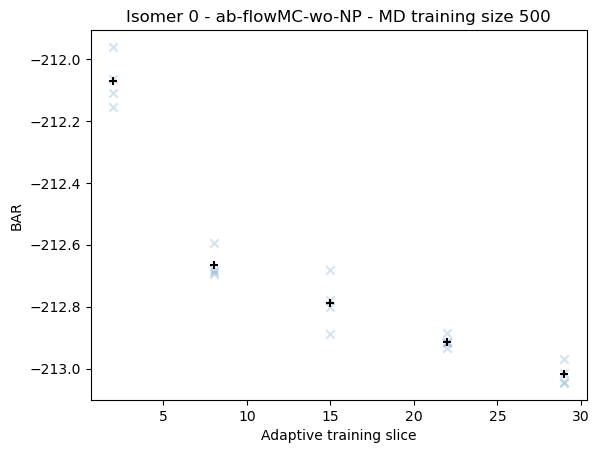

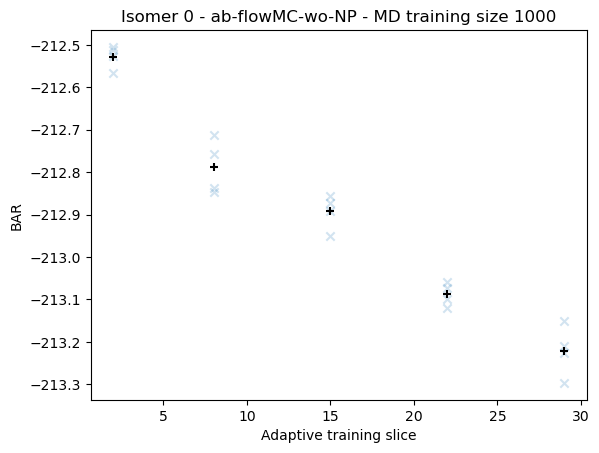

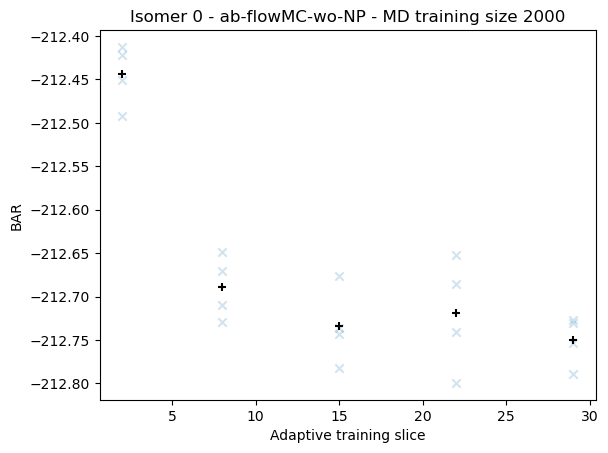

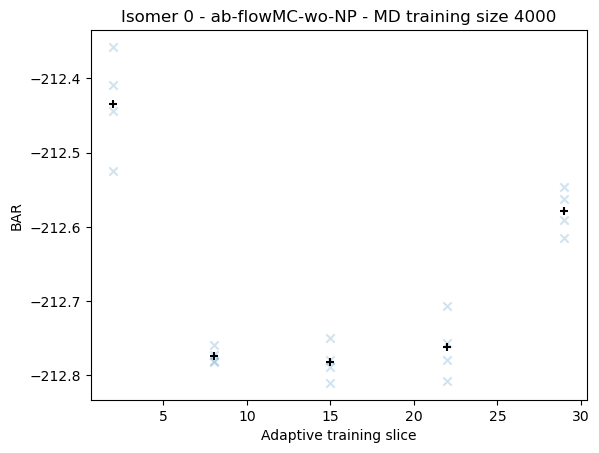

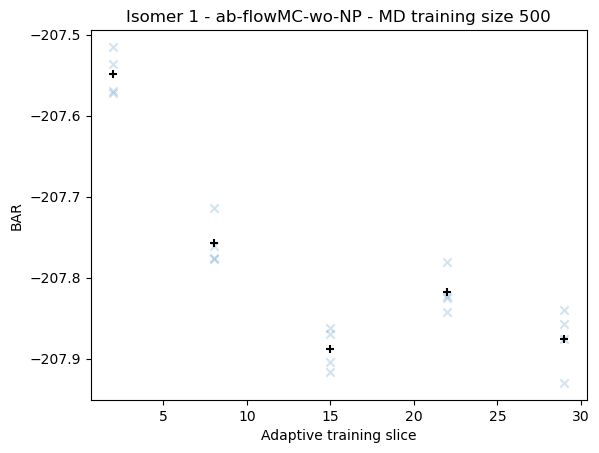

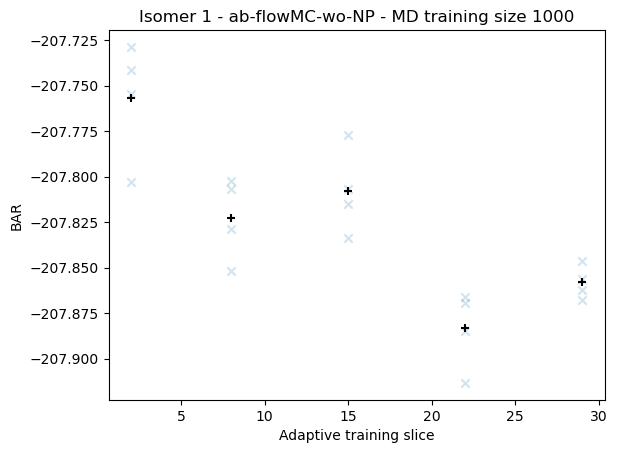

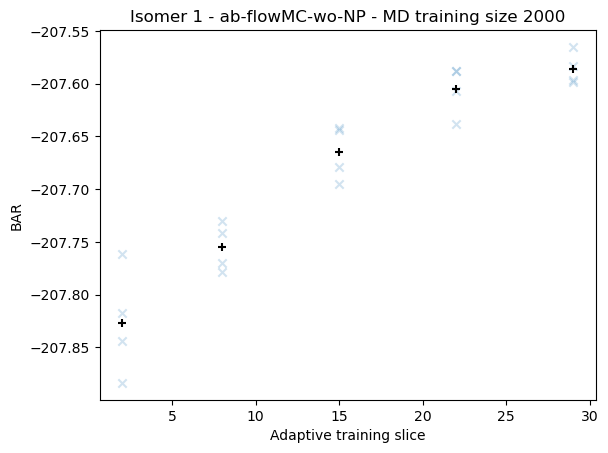

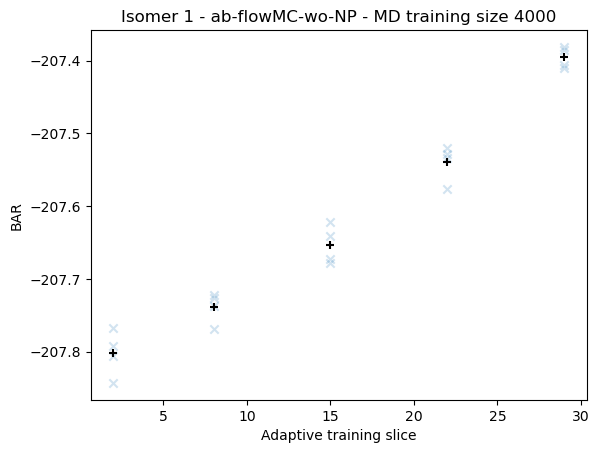

In [589]:
# flow that has been trained by dft 
kind = 'ab-flowMC-wo-NP'
batch_size = 1000 ## best trainings to be selected - not necessarily everywhere
df_args = dic_args[kind]

n_train_slice = 5
n_samples = 500
n_training_slices_per_eval = 2

dic_results_BARs = {}
for isomer_id in mode_labels:
    df_isomer = df_args.loc[(df_args['flow_batch_size'] == batch_size) & (df_args['isomer_label'] == isomer_id)]
    
    md_training_sizes = df_isomer['N'].values
    process_ids = df_isomer['process_id'].values

    dic_results_BARs[isomer_id] = {}

    for md_training_size, process_id in zip(md_training_sizes, process_ids):
        print('Isomer {:d}, MD training size = {:d}, process_id {:d}'.format(isomer_id, md_training_size, process_id))
        models = load_models(isomer_id, process_id, project_path=subproject_path + '/1-adaptive/') 
        train_slices = (np.linspace(n_training_slices_per_eval, len(models)-2, n_train_slice)).astype(int)
        
        prop_samples, prop_energy_target = load_samples_n_energies('xs_proposals', isomer_id, process_id, project_path=subproject_path + '/1-adaptive/')
        mc_samples, mc_energy_target = load_samples_n_energies('xs_adaptive', isomer_id, process_id, project_path=subproject_path + '/1-adaptive/')
        
        # mask = np.ones(prop_samples.shape[0], dtype=bool)
        # for n in range(30):
        #     mask[50 * n:50 * (n+1)] = False
        # prop_samples = prop_samples[mask]
        # prop_energy_target = prop_energy_target[mask]
        # print('Cleaned prop samples : ', prop_samples.shape[0], 'samples')

        n_chains = df_isomer.loc[df_isomer['process_id'] == process_id]['n_chains'].values[0]
        
        # prop_samples = prop_samples.reshape(-1, n_chains, 12)
        prop_samples = prop_samples.reshape(len(models) - 1, -1, 12)
        # energy_target = energy_target.reshape(-1, n_chains)
        prop_energy_target = prop_energy_target.reshape(len(models) - 1, -1)

        mc_samples = mc_samples.reshape(len(models) - 1, -1, 12)
        mc_energy_target = mc_energy_target.reshape(len(models) - 1, -1)

        assert prop_samples.shape[0] == mc_samples.shape[0]
        n_samples_avail = prop_energy_target.shape[1] 
        n_trial = (n_samples_avail * n_training_slices_per_eval) // n_samples
        print(n_samples_avail, 'samples per training slice --> n_trial = {:d}'.format(n_trial))
        
        
        dic_results_BARs[isomer_id][md_training_size] = {}
        dic_results_BARs[isomer_id][md_training_size]['train_slices'] = train_slices

        plt.figure()
        ax1 = plt.subplot(111)
        plt.title('Isomer {:d} - {:s} - MD training size {:d}'.format(isomer_id, kind, md_training_size))
        plt.xlabel('Adaptive training slice')
        plt.ylabel('BAR')

#         plt.figure(figsize=(5 * n_train_slice / 1, 5 * 1))
#         plt.title('Isomer {:d} - {:s} - MD training size {:d}'.format(isomer_id, kind, md_training_size))
#         axs = [plt.subplot(1, int(n_train_slice // 1), i+1) for i in range(n_train_slice)]

        dic_results_BARs[isomer_id][md_training_size]['means'] = []
        dic_results_BARs[isomer_id][md_training_size]['stds'] = []
        dic_results_BARs[isomer_id][md_training_size]['train_slices'] = train_slices

        for t, train_slice in enumerate(train_slices):
            log_ratio_0_BARs = []
            log_err_0_BARs = []

            prop = models[train_slice]

            perm = np.random.permutation(n_samples_avail * n_training_slices_per_eval)

            prop_samples_t = prop_samples[train_slice-n_training_slices_per_eval:train_slice].reshape(-1, 12)
            prop_energy_target_t = prop_energy_target[train_slice-n_training_slices_per_eval:train_slice].reshape(-1)
            mc_samples_t = mc_samples[train_slice-n_training_slices_per_eval:train_slice].reshape(-1, 12)
            mc_energy_target_t = mc_energy_target[train_slice-n_training_slices_per_eval:train_slice].reshape(-1)
            # print('prop_samples_t.shape = ', prop_samples_t.shape)
            for trial in range(n_trial):
                # idx = perm[trial*n_samples:(trial+1)*n_samples]

                # logprob_prop = (- models[train_slice].nll(prop_samples_t[idx])).detach().numpy()
                # logprob_target = (- beta * energy_target_t[idx]).detach().numpy()
                # logr_BAR_0, std_r_BAR_0 = compute_BAR_from_samples(logprob_prop, logprob_target)
                # log_ratio_0_BARs.append(logr_BAR_0)
                # std_r_0_BARs.append(std_r_BAR_0)

                idx = perm[trial*n_samples:(trial+1)*n_samples]
                logprop_prop = - prop.nll(prop_samples_t[idx]).detach().numpy() 
                logprop_mc = - prop.nll(mc_samples_t[idx]).detach().numpy() 
                logtgt_prop = - beta * prop_energy_target_t[idx].detach().numpy()
                logtgt_mc = - beta * mc_energy_target_t[idx].detach().numpy()


                logr, logr_err = compute_BAR_from_samples(logprop_prop, logprop_mc, logtgt_prop, logtgt_mc, 
                                            maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
                log_ratio_0_BARs.append(logr)
                log_err_0_BARs.append(logr_err)

                
            dic_results_BARs[isomer_id][md_training_size]['means'].append(np.array(log_ratio_0_BARs).mean())
            dic_results_BARs[isomer_id][md_training_size]['stds'].append(np.array(log_ratio_0_BARs).std())
            # dic_results_BARs[isomer_id][md_training_size]['r_std_fromsum'].append(std_r_0_BARs)

            plt.sca(ax1)
            plt.scatter(np.ones(len(log_ratio_0_BARs))*train_slice, log_ratio_0_BARs, c='C0', marker='x', alpha=0.2)
            plt.scatter(train_slice, np.array(log_ratio_0_BARs).mean(), c='k', marker='+')

        print(dic_results_BARs.keys())
            
            # plt.sca(axs[t])
            # plt.scatter( - logprob_target / beta, - logprob_prop / beta)
            # plt.xlabel('DFT energies')
            # plt.ylabel('Flow negative log-likelihood')
            # plt.title('training slice = {:d}'.format(train_slice))

dic_results_BARs_flow_dft = copy.deepcopy(dic_results_BARs)

In [408]:
dic_results_BARs_flow_dft[0].keys()

dict_keys([500, 1000, 2000, 4000])

### 2.3 Adaptive flow trained on DFT+MLP

Isomer 0, MD training size = 500, process_id 30019620
300 samples per training slice --> n_trial = 6
Isomer 0, MD training size = 1000, process_id 30019621
300 samples per training slice --> n_trial = 6
Isomer 0, MD training size = 2000, process_id 30019622
300 samples per training slice --> n_trial = 6
Isomer 0, MD training size = 4000, process_id 30019623
300 samples per training slice --> n_trial = 6
Isomer 1, MD training size = 500, process_id 30019624
300 samples per training slice --> n_trial = 6
Isomer 1, MD training size = 1000, process_id 30019625
300 samples per training slice --> n_trial = 6
Isomer 1, MD training size = 2000, process_id 30019626
300 samples per training slice --> n_trial = 6
Isomer 1, MD training size = 4000, process_id 30019627
300 samples per training slice --> n_trial = 6


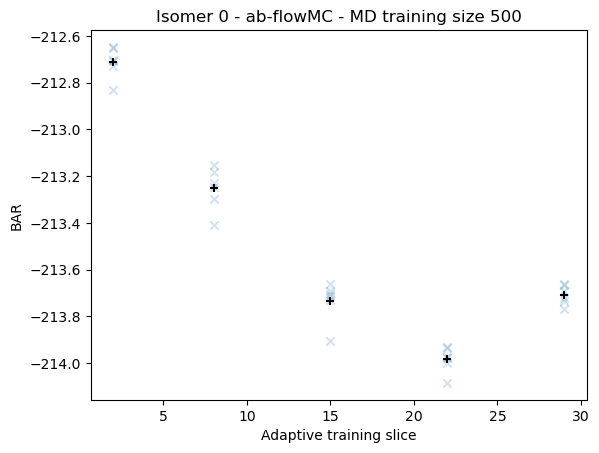

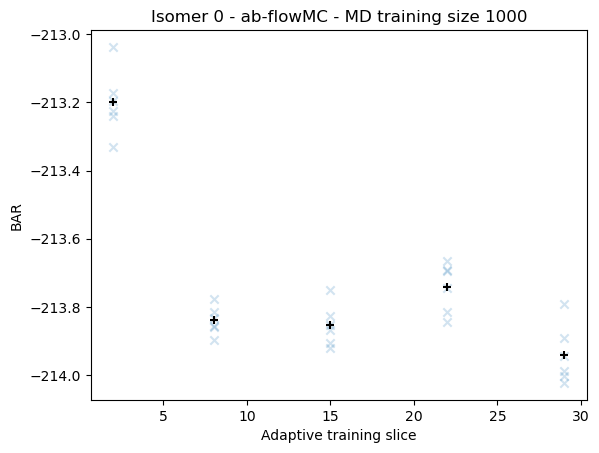

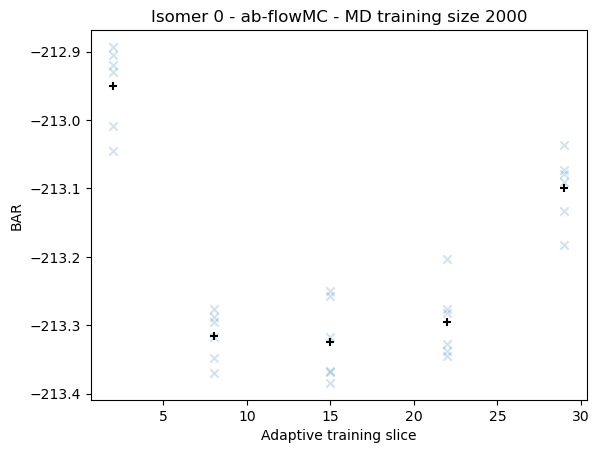

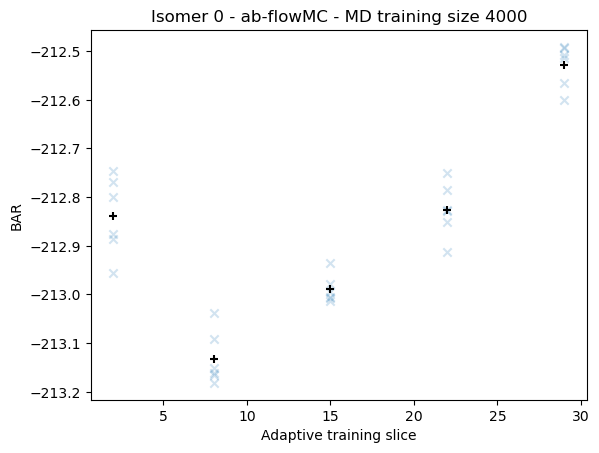

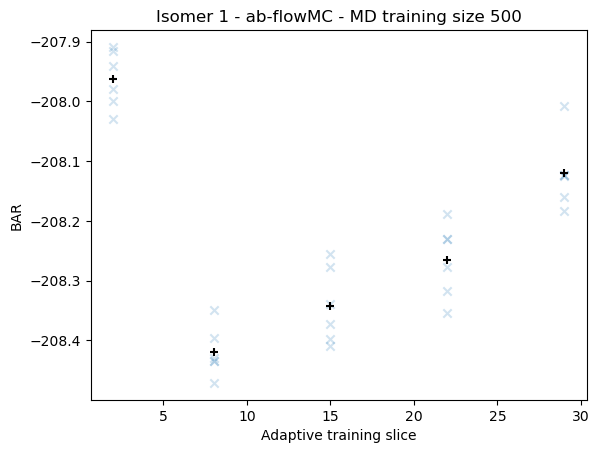

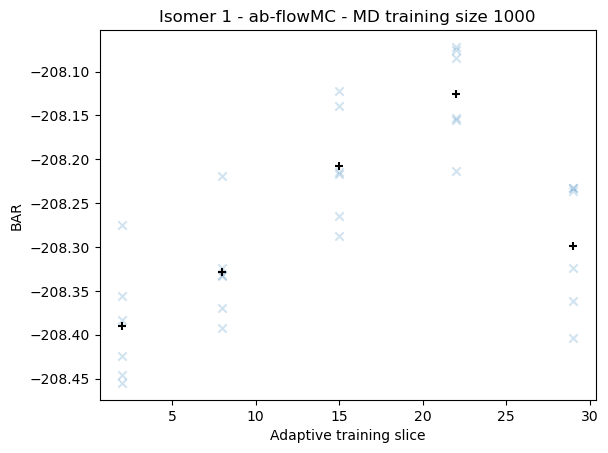

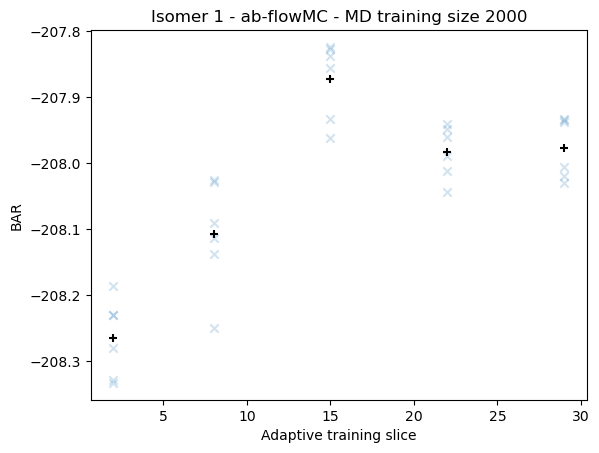

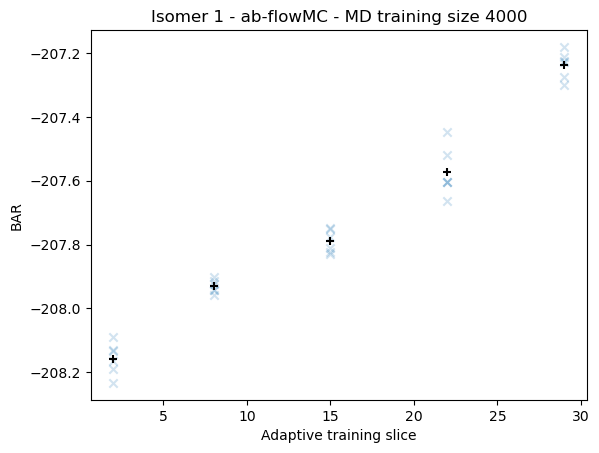

In [617]:
# flow that has been trained by dft 
kind = 'ab-flowMC'
batch_size = 1000 ## best trainings to be selected - not necessarily everywhere
df_args = dic_args[kind]

n_train_slice = 5
n_samples = 100
n_training_slices_per_eval = 2

dic_results_BARs = {}

for isomer_id in mode_labels:
    df_isomer = df_args.loc[(df_args['flow_batch_size'] == batch_size) & (df_args['isomer_label'] == isomer_id)]
    
    md_training_sizes = df_isomer['N'].values
    process_ids = df_isomer['process_id'].values

    dic_results_BARs[isomer_id] = {}
    
    for md_training_size, process_id in zip(md_training_sizes, process_ids):
        print('Isomer {:d}, MD training size = {:d}, process_id {:d}'.format(isomer_id, md_training_size, process_id))
        models = load_models(isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/') 
        train_slices = (np.linspace(n_training_slices_per_eval, len(models)-2, n_train_slice)).astype(int)
        
        prop_samples, prop_energy_target = load_samples_n_energies('xs_proposals', isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/')
        mc_samples, mc_energy_target = load_samples_n_energies('xs_adaptive', isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/')
        
        # mask = np.ones(prop_samples.shape[0], dtype=bool)
        # for n in range(30):
        #     mask[50 * n:50 * (n+1)] = False
        # prop_samples = prop_samples[mask]
        # prop_energy_target = prop_energy_target[mask]
        # print('Cleaned prop samples : ', prop_samples.shape[0], 'samples')

        # n_chains = df_isomer.loc[df_isomer['process_id'] == process_id]['n_chains'].values[0]
        
        # prop_samples = prop_samples.reshape(-1, n_chains, 12)
        prop_samples = prop_samples.reshape(len(models) - 1, -1, 12)
        # energy_target = energy_target.reshape(-1, n_chains)
        prop_energy_target = prop_energy_target.reshape(len(models) - 1, -1)

        mc_samples = mc_samples.reshape(len(models) - 1, -1, 12)
        mc_energy_target = mc_energy_target.reshape(len(models) - 1, -1)

        assert prop_samples.shape[0] == mc_samples.shape[0]
        n_samples_avail = prop_energy_target.shape[1] 
        n_trial = (n_samples_avail * n_training_slices_per_eval) // n_samples
        print(n_samples_avail, 'samples per training slice --> n_trial = {:d}'.format(n_trial))
        
        
        dic_results_BARs[isomer_id][md_training_size] = {}

        plt.figure()
        ax1 = plt.subplot(111)
        plt.title('Isomer {:d} - {:s} - MD training size {:d}'.format(isomer_id, kind, md_training_size))
        plt.xlabel('Adaptive training slice')
        plt.ylabel('BAR')

#         plt.figure(figsize=(5 * n_train_slice / 1, 5 * 1))
#         plt.title('Isomer {:d} - {:s} - MD training size {:d}'.format(isomer_id, kind, md_training_size))
#         axs = [plt.subplot(1, int(n_train_slice // 1), i+1) for i in range(n_train_slice)]

        dic_results_BARs[isomer_id][md_training_size]['means'] = []
        dic_results_BARs[isomer_id][md_training_size]['stds'] = []
        dic_results_BARs[isomer_id][md_training_size]['train_slices'] = train_slices

        for t, train_slice in enumerate(train_slices):
            log_ratio_0_BARs = []
            log_err_0_BARs = []

            prop = models[train_slice]

            perm = np.random.permutation(n_samples_avail * n_training_slices_per_eval)

            prop_samples_t = prop_samples[train_slice-n_training_slices_per_eval:train_slice].reshape(-1, 12)
            prop_energy_target_t = prop_energy_target[train_slice-n_training_slices_per_eval:train_slice].reshape(-1)
            mc_samples_t = mc_samples[train_slice-n_training_slices_per_eval:train_slice].reshape(-1, 12)
            mc_energy_target_t = mc_energy_target[train_slice-n_training_slices_per_eval:train_slice].reshape(-1)
            # print('prop_samples_t.shape = ', prop_samples_t.shape)
            for trial in range(n_trial):
                # idx = perm[trial*n_samples:(trial+1)*n_samples]

                # logprob_prop = (- models[train_slice].nll(prop_samples_t[idx])).detach().numpy()
                # logprob_target = (- beta * energy_target_t[idx]).detach().numpy()
                # logr_BAR_0, std_r_BAR_0 = compute_BAR_from_samples(logprob_prop, logprob_target)
                # log_ratio_0_BARs.append(logr_BAR_0)
                # std_r_0_BARs.append(std_r_BAR_0)

                idx = perm[trial*n_samples:(trial+1)*n_samples]
                logprop_prop = - prop.nll(prop_samples_t[idx]).detach().numpy() 
                logprop_mc = - prop.nll(mc_samples_t[idx]).detach().numpy() 
                logtgt_prop = - beta * prop_energy_target_t[idx].detach().numpy()
                logtgt_mc = - beta * mc_energy_target_t[idx].detach().numpy()


                logr, logr_err = compute_BAR_from_samples(logprop_prop, logprop_mc, logtgt_prop, logtgt_mc, 
                                            maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
                log_ratio_0_BARs.append(logr)
                log_err_0_BARs.append(logr_err)

                
            dic_results_BARs[isomer_id][md_training_size]['means'].append(np.array(log_ratio_0_BARs).mean())
            dic_results_BARs[isomer_id][md_training_size]['stds'].append(np.array(log_ratio_0_BARs).std())
            # dic_results_BARs[isomer_id][md_training_size]['r_std_fromsum'].append(std_r_0_BARs)

            plt.sca(ax1)
            plt.scatter(np.ones(len(log_ratio_0_BARs))*train_slice, log_ratio_0_BARs, c='C0', marker='x', alpha=0.2)
            plt.scatter(train_slice, np.array(log_ratio_0_BARs).mean(), c='k', marker='+')
            
            # plt.sca(axs[t])
            # plt.scatter( - logprob_target / beta, - logprob_prop / beta)
            # plt.xlabel('DFT energies')
            # plt.ylabel('Flow negative log-likelihood')
            # plt.title('training slice = {:d}'.format(train_slice))

dic_results_BARs_flow_dft_mlp = copy.deepcopy(dic_results_BARs)

#### 2.3.2 - ab-flowMC using NP to make the prediction of the energy in the free energy density

Isomer 0, MD training size = 500, process_id 30019620
300 samples per training slice --> n_trial = 6
Isomer 0, MD training size = 1000, process_id 30019621
300 samples per training slice --> n_trial = 6
Isomer 0, MD training size = 2000, process_id 30019622
300 samples per training slice --> n_trial = 6
Isomer 0, MD training size = 4000, process_id 30019623
300 samples per training slice --> n_trial = 6
Isomer 1, MD training size = 500, process_id 30019624
300 samples per training slice --> n_trial = 6
Isomer 1, MD training size = 1000, process_id 30019625
300 samples per training slice --> n_trial = 6
Isomer 1, MD training size = 2000, process_id 30019626
300 samples per training slice --> n_trial = 6
Isomer 1, MD training size = 4000, process_id 30019627
300 samples per training slice --> n_trial = 6


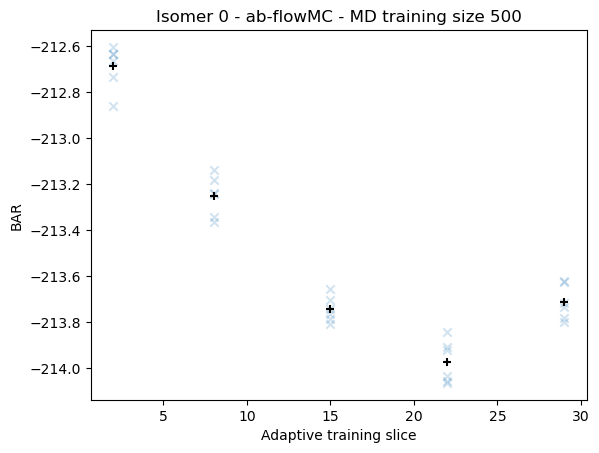

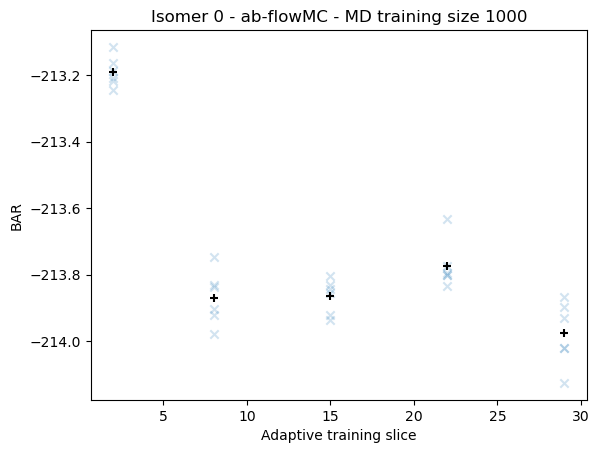

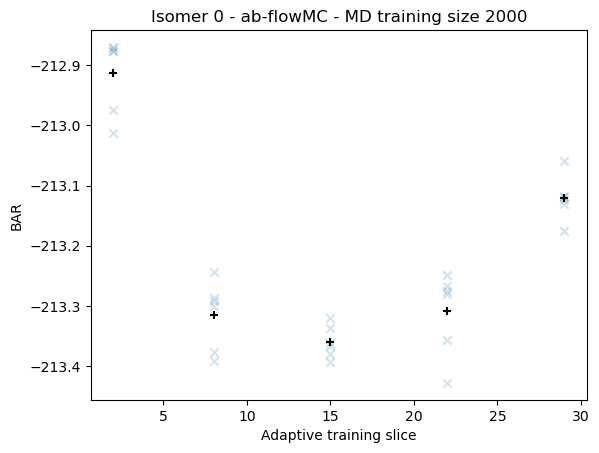

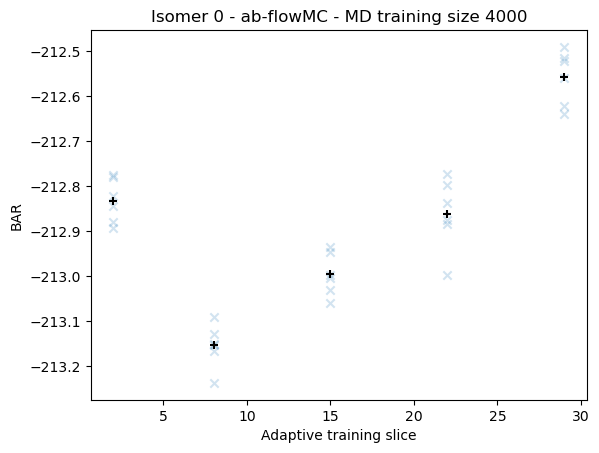

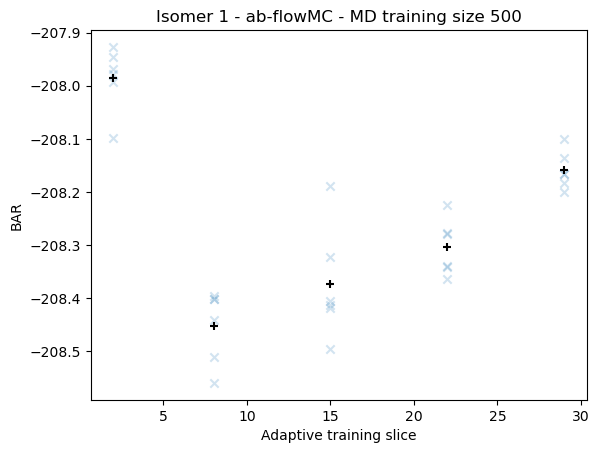

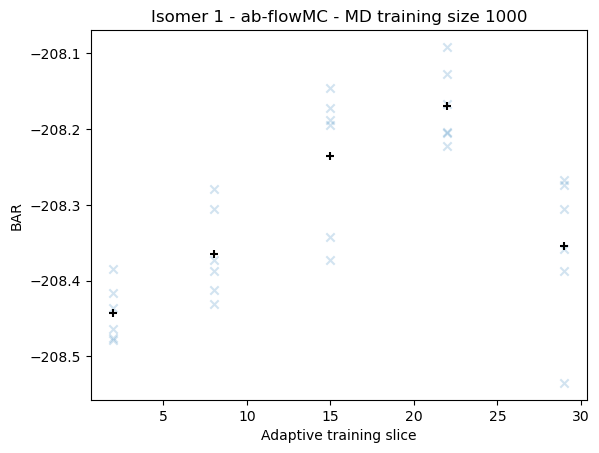

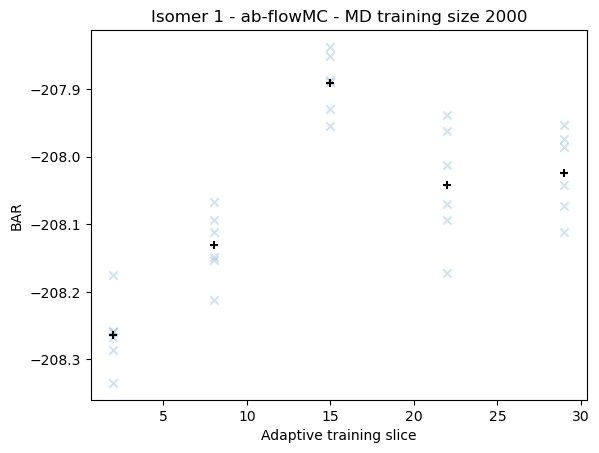

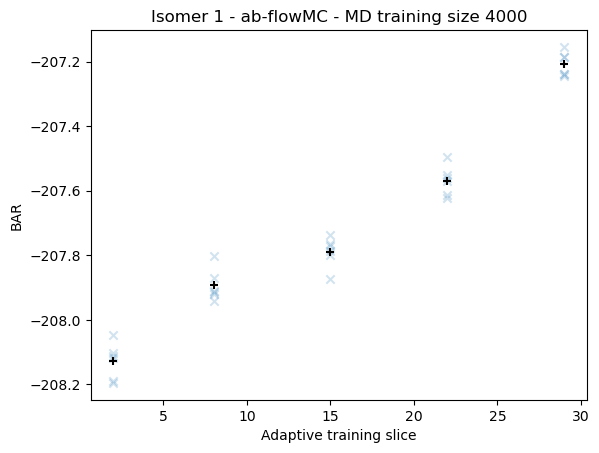

In [569]:
# flow that has been trained by dft 
kind = 'ab-flowMC'
batch_size = 1000 ## best trainings to be selected - not necessarily everywhere
df_args = dic_args[kind]

n_train_slice = 5
n_samples = 100
n_training_slices_per_eval = 2

dic_results_BARs = {}

for isomer_id in mode_labels:
    df_isomer = df_args.loc[(df_args['flow_batch_size'] == batch_size) & (df_args['isomer_label'] == isomer_id)]
    
    md_training_sizes = df_isomer['N'].values
    process_ids = df_isomer['process_id'].values
    
    dic_results_BARs[isomer_id] = {}
    
    for md_training_size, process_id in zip(md_training_sizes, process_ids):
        print('Isomer {:d}, MD training size = {:d}, process_id {:d}'.format(isomer_id, md_training_size, process_id))
        models = load_models(isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/') 
        mlp_models = load_mlp_models(isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/')
        train_slices = (np.linspace(n_training_slices_per_eval, len(models)-2, n_train_slice)).astype(int)
        
        prop_samples, prop_energy_target = load_samples_n_energies('xs_proposals', isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/')
        mc_samples, mc_energy_target = load_samples_n_energies('xs_adaptive', isomer_id, process_id, project_path=subproject_path + '/2-adaptive-mlp/')
        
        # mask = np.ones(prop_samples.shape[0], dtype=bool)
        # for n in range(30):
        #     mask[50 * n:50 * (n+1)] = False
        # prop_samples = prop_samples[mask]
        # prop_energy_target = prop_energy_target[mask]
        # print('Cleaned prop samples : ', prop_samples.shape[0], 'samples')

        n_chains = df_isomer.loc[df_isomer['process_id'] == process_id]['n_chains'].values[0]
        
        # prop_samples = prop_samples.reshape(-1, n_chains, 12)
        prop_samples = prop_samples.reshape(len(models) - 1, -1, 12)
        # energy_target = energy_target.reshape(-1, n_chains)
        prop_energy_target = prop_energy_target.reshape(len(models) - 1, -1)

        mc_samples = mc_samples.reshape(len(models) - 1, -1, 12)
        mc_energy_target = mc_energy_target.reshape(len(models) - 1, -1)

        assert prop_samples.shape[0] == mc_samples.shape[0]
        n_samples_avail = prop_energy_target.shape[1] 
        n_trial = (n_samples_avail * n_training_slices_per_eval) // n_samples
        print(n_samples_avail, 'samples per training slice --> n_trial = {:d}'.format(n_trial))
        
        
        dic_results_BARs[isomer_id][md_training_size] = {}

        plt.figure()
        ax1 = plt.subplot(111)
        plt.title('Isomer {:d} - {:s} - MD training size {:d}'.format(isomer_id, kind, md_training_size))
        plt.xlabel('Adaptive training slice')
        plt.ylabel('BAR')

#         plt.figure(figsize=(5 * n_train_slice / 1, 5 * 1))
#         plt.title('Isomer {:d} - {:s} - MD training size {:d}'.format(isomer_id, kind, md_training_size))
#         axs = [plt.subplot(1, int(n_train_slice // 1), i+1) for i in range(n_train_slice)]

        dic_results_BARs[isomer_id][md_training_size]['means'] = []
        dic_results_BARs[isomer_id][md_training_size]['stds'] = []
        dic_results_BARs[isomer_id][md_training_size]['train_slices'] = train_slices

        for t, train_slice in enumerate(train_slices):
            log_ratio_0_BARs = []
            log_err_0_BARs = []

            prop = models[train_slice]

            perm = np.random.permutation(n_samples_avail * n_training_slices_per_eval)

            prop_samples_t = prop_samples[train_slice-n_training_slices_per_eval:train_slice].reshape(-1, 12)
            prop_energy_target_t = mlp_models[train_slice](prop_samples_t).reshape(-1)
            mc_samples_t = mc_samples[train_slice-n_training_slices_per_eval:train_slice].reshape(-1, 12)
            mc_energy_target_t = mlp_models[train_slice](mc_samples_t).reshape(-1)
            # print('prop_samples_t.shape = ', prop_samples_t.shape)
            for trial in range(n_trial):
                # idx = perm[trial*n_samples:(trial+1)*n_samples]

                # logprob_prop = (- models[train_slice].nll(prop_samples_t[idx])).detach().numpy()
                # logprob_target = (- beta * energy_target_t[idx]).detach().numpy()
                # logr_BAR_0, std_r_BAR_0 = compute_BAR_from_samples(logprob_prop, logprob_target)
                # log_ratio_0_BARs.append(logr_BAR_0)
                # std_r_0_BARs.append(std_r_BAR_0)

                idx = perm[trial*n_samples:(trial+1)*n_samples]
                logprop_prop = - prop.nll(prop_samples_t[idx]).detach().numpy() 
                logprop_mc = - prop.nll(mc_samples_t[idx]).detach().numpy() 
                logtgt_prop = - beta * prop_energy_target_t[idx].detach().numpy()
                logtgt_mc = - beta * mc_energy_target_t[idx].detach().numpy()


                logr, logr_err = compute_BAR_from_samples(logprop_prop, logprop_mc, logtgt_prop, logtgt_mc, 
                                            maxiter=2000, rtol=1e-13, xtol=1e-13, ess=1)
                log_ratio_0_BARs.append(logr)
                log_err_0_BARs.append(logr_err)

                
            dic_results_BARs[isomer_id][md_training_size]['means'].append(np.array(log_ratio_0_BARs).mean())
            dic_results_BARs[isomer_id][md_training_size]['stds'].append(np.array(log_ratio_0_BARs).std())
            # dic_results_BARs[isomer_id][md_training_size]['r_std_fromsum'].append(std_r_0_BARs)

            plt.sca(ax1)
            plt.scatter(np.ones(len(log_ratio_0_BARs))*train_slice, log_ratio_0_BARs, c='C0', marker='x', alpha=0.2)
            plt.scatter(train_slice, np.array(log_ratio_0_BARs).mean(), c='k', marker='+')
            
            # plt.sca(axs[t])
            # plt.scatter( - logprob_target / beta, - logprob_prop / beta)
            # plt.xlabel('DFT energies')
            # plt.ylabel('Flow negative log-likelihood')
            # plt.title('training slice = {:d}'.format(train_slice))

dic_results_BARs_flow_dft_mlp_target_mlp = copy.deepcopy(dic_results_BARs)

### 2.z Combining the plots

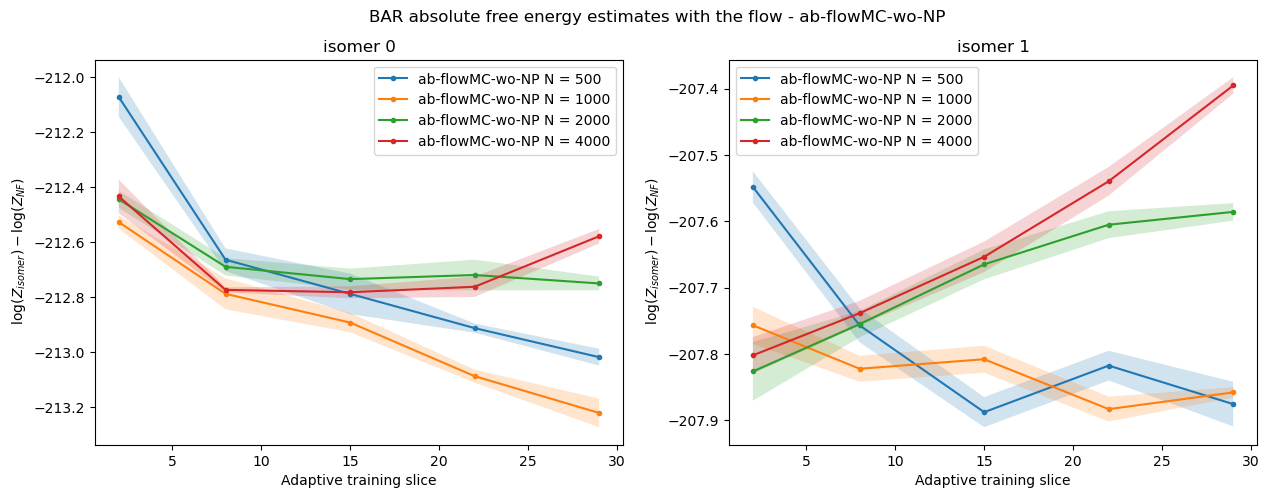

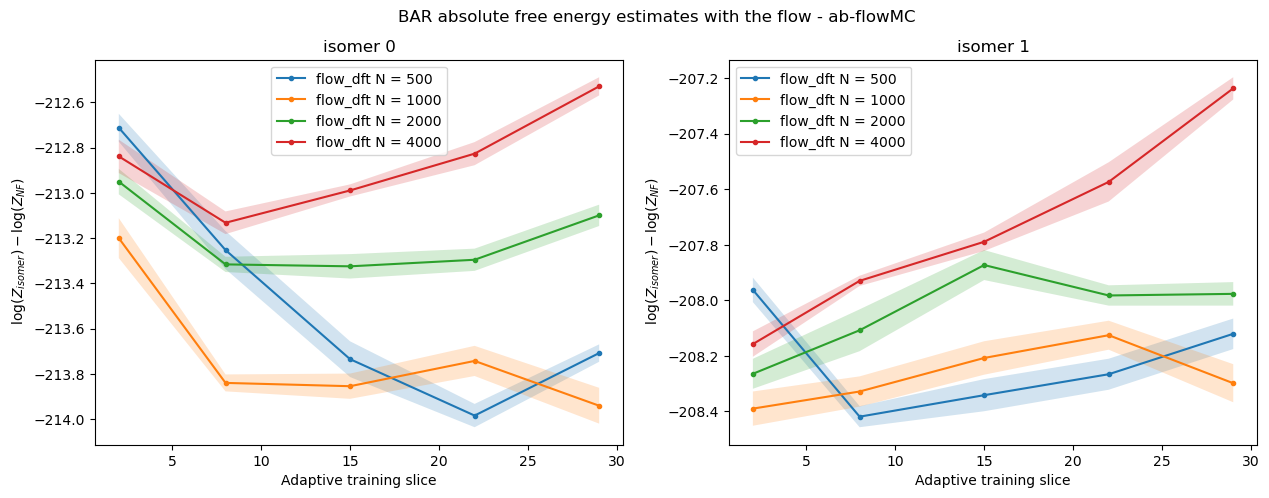

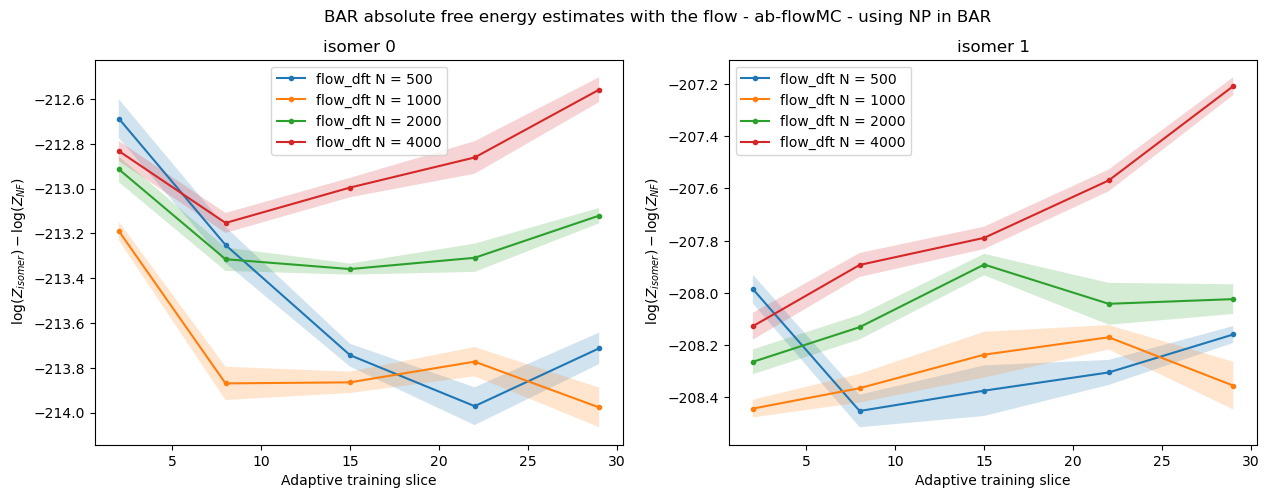

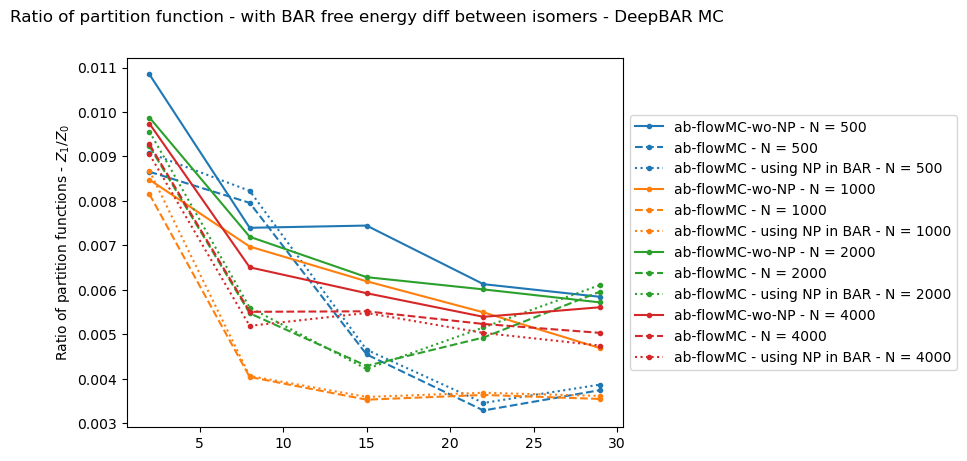

In [618]:

############################ ab-flowMC-wo-NP
plt.figure(figsize=(15, 5))
plt.suptitle('BAR absolute free energy estimates with the flow - ab-flowMC-wo-NP')
for md_training_size in dic_results_BARs_flow_dft[isomer_id].keys():
    

    
    axs = [plt.subplot(1, 2, i+1) for i in range(2)]
    for isomer_id in mode_labels:
        plt.sca(axs[isomer_id])
        plt.title('isomer {:d}'.format(isomer_id))

        plt.plot(dic_results_BARs_flow_dft[isomer_id][md_training_size]['train_slices'],
                    dic_results_BARs_flow_dft[isomer_id][md_training_size]['means'],  '.-',
                    label='ab-flowMC-wo-NP N = {:d}'.format(md_training_size))
        plt.fill_between(dic_results_BARs_flow_dft[isomer_id][md_training_size]['train_slices'],
                        np.array(dic_results_BARs_flow_dft[isomer_id][md_training_size]['means']) - np.array(dic_results_BARs_flow_dft[isomer_id][md_training_size]['stds']),
                        np.array(dic_results_BARs_flow_dft[isomer_id][md_training_size]['means']) + np.array(dic_results_BARs_flow_dft[isomer_id][md_training_size]['stds']),
                        alpha=0.2)
        plt.legend()
        plt.xlabel('Adaptive training slice')
        plt.ylabel(r' $\log(Z_{isomer}) - \log(Z_{NF})$') 


############################ ab-flowMC
plt.figure(figsize=(15, 5))
plt.suptitle('BAR absolute free energy estimates with the flow - ab-flowMC')
for md_training_size in dic_results_BARs_flow_dft_mlp[isomer_id].keys():
    
    axs = [plt.subplot(1, 2, i+1) for i in range(2)]
    for isomer_id in mode_labels:
        plt.sca(axs[isomer_id])
        plt.title('isomer {:d}'.format(isomer_id))

        plt.plot(dic_results_BARs_flow_dft_mlp[isomer_id][md_training_size]['train_slices'],
                    dic_results_BARs_flow_dft_mlp[isomer_id][md_training_size]['means'],  '.-',
                    label='flow_dft N = {:d}'.format(md_training_size))
        plt.fill_between(dic_results_BARs_flow_dft_mlp[isomer_id][md_training_size]['train_slices'],
                        np.array(dic_results_BARs_flow_dft_mlp[isomer_id][md_training_size]['means']) - np.array(dic_results_BARs_flow_dft_mlp[isomer_id][md_training_size]['stds']),
                        np.array(dic_results_BARs_flow_dft_mlp[isomer_id][md_training_size]['means']) + np.array(dic_results_BARs_flow_dft_mlp[isomer_id][md_training_size]['stds']),
                        alpha=0.2)
        plt.legend()
        plt.xlabel('Adaptive training slice')
        plt.ylabel(r' $\log(Z_{isomer}) - \log(Z_{NF})$') 



############################ ab-flowMC - target mlp
plt.figure(figsize=(15, 5))
plt.suptitle('BAR absolute free energy estimates with the flow - ab-flowMC - using NP in BAR')
for md_training_size in dic_results_BARs_flow_dft_mlp_target_mlp[isomer_id].keys():
    
    axs = [plt.subplot(1, 2, i+1) for i in range(2)]
    for isomer_id in mode_labels:
        plt.sca(axs[isomer_id])
        plt.title('isomer {:d}'.format(isomer_id))

        plt.plot(dic_results_BARs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['train_slices'],
                    dic_results_BARs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['means'],  '.-',
                    label='flow_dft N = {:d}'.format(md_training_size))
        plt.fill_between(dic_results_BARs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['train_slices'],
                        np.array(dic_results_BARs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['means']) - np.array(dic_results_BARs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['stds']),
                        np.array(dic_results_BARs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['means']) + np.array(dic_results_BARs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['stds']),
                        alpha=0.2)
        plt.legend()
        plt.xlabel('Adaptive training slice')
        plt.ylabel(r' $\log(Z_{isomer}) - \log(Z_{NF})$') 



plt.figure()
plt.suptitle('Ratio of partition function - with BAR free energy diff between isomers - DeepBAR MC')
for c,md_training_size in enumerate(dic_results_BARs_flow_dft[isomer_id].keys()):
    plt.plot(dic_results_BARs_flow_dft[isomer_id][md_training_size]['train_slices'],
                np.exp( np.array(dic_results_BARs_flow_dft[0][md_training_size]['means']) - np.array(dic_results_BARs_flow_dft[1][md_training_size]['means'])),  '.-',
                label='ab-flowMC-wo-NP - N = {:d}'.format(md_training_size), c='C{:d}'.format(c), ls='-')
    plt.plot(dic_results_BARs_flow_dft_mlp[isomer_id][md_training_size]['train_slices'],
                np.exp( np.array(dic_results_BARs_flow_dft_mlp[0][md_training_size]['means']) - np.array(dic_results_BARs_flow_dft_mlp[1][md_training_size]['means'])),  '.-',
                label='ab-flowMC - N = {:d}'.format(md_training_size), c='C{:d}'.format(c), ls='--')
    plt.plot(dic_results_BARs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['train_slices'],
                np.exp(np.array(dic_results_BARs_flow_dft_mlp_target_mlp[0][md_training_size]['means']) - np.array(dic_results_BARs_flow_dft_mlp_target_mlp[1][md_training_size]['means'])),  '.-',
                label='ab-flowMC - using NP in BAR - N = {:d}'.format(md_training_size), c='C{:d}'.format(c), ls=':')
plt.ylabel(r'Ratio of partition functions - $Z_1 / Z_0$') 
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

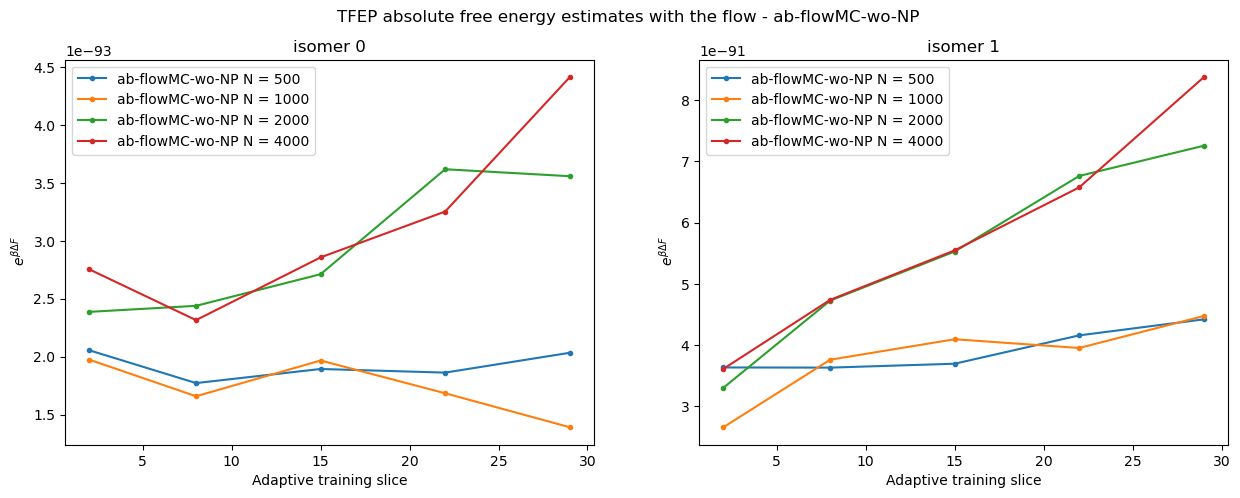

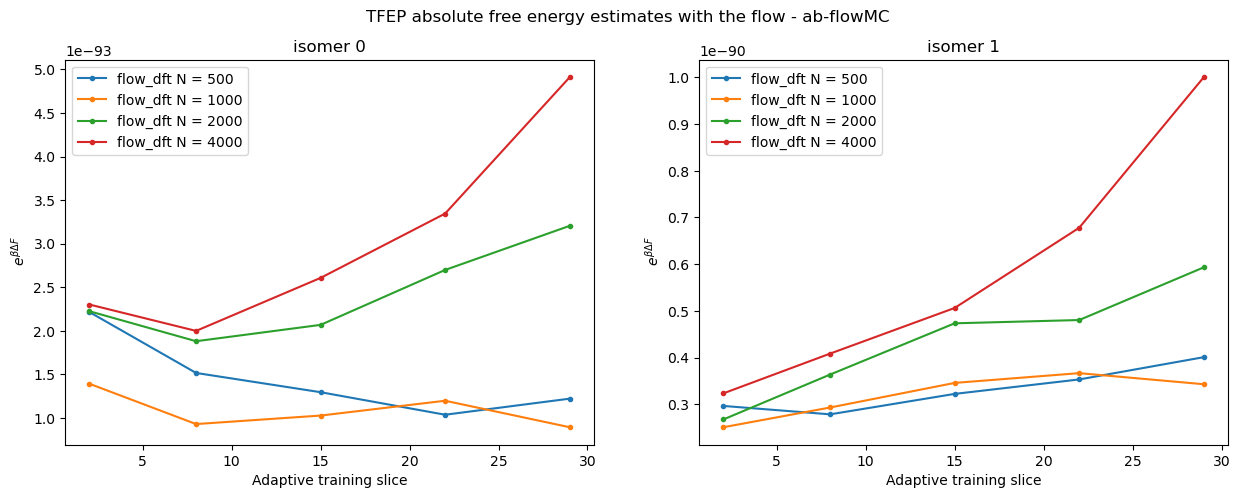

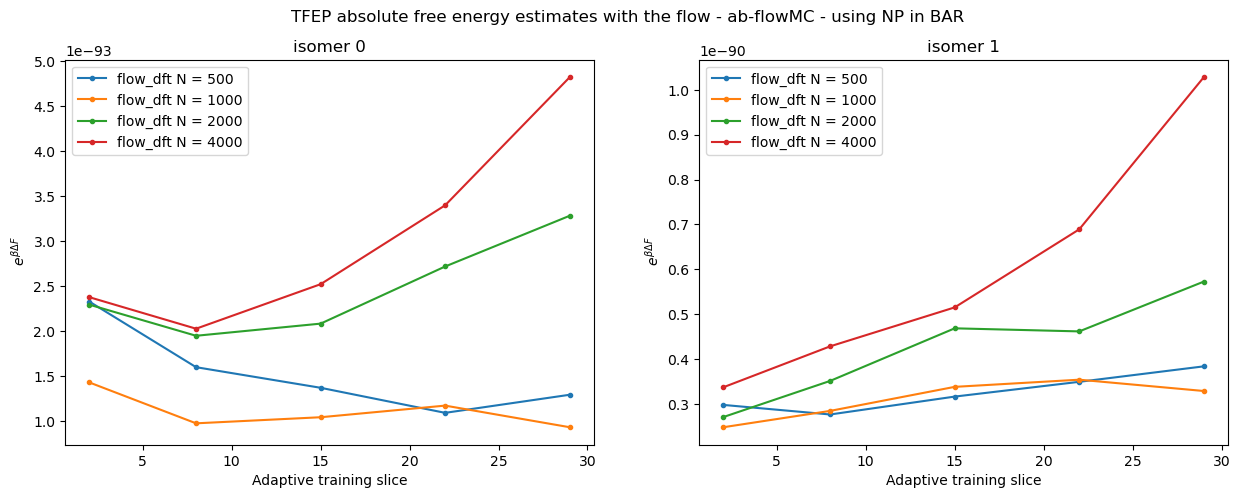

In [469]:
## plot instead the ratios with the partition functions / flow normalizations

############################ ab-flowMC-wo-NP
plt.figure(figsize=(15, 5))
plt.suptitle('CAR absolute free energy estimates with the flow - ab-flowMC-wo-NP')
for md_training_size in dic_results_BARs_flow_dft[isomer_id].keys():
    
    axs = [plt.subplot(1, 2, i+1) for i in range(2)]
    for isomer_id in mode_labels:
        plt.sca(axs[isomer_id])
        plt.title('isomer {:d}'.format(isomer_id))

        plt.plot(dic_results_BARs_flow_dft[isomer_id][md_training_size]['train_slices'],
                    np.exp(np.array(dic_results_BARs_flow_dft[isomer_id][md_training_size]['means'])),  '.-',
                    label='ab-flowMC-wo-NP N = {:d}'.format(md_training_size))
        # plt.fill_between(dic_results_BARs_flow_dft[isomer_id][md_training_size]['train_slices'],
        #                 np.array(dic_results_BARs_flow_dft[isomer_id][md_training_size]['means']) - np.array(dic_results_BARs_flow_dft[isomer_id][md_training_size]['stds']),
        #                 np.array(dic_results_BARs_flow_dft[isomer_id][md_training_size]['means']) + np.array(dic_results_BARs_flow_dft[isomer_id][md_training_size]['stds']),
        #                 alpha=0.2)
        plt.legend()
        plt.xlabel('Adaptive training slice')
        plt.ylabel(r' $e^{\beta \Delta F}$') 


############################ ab-flowMC
plt.figure(figsize=(15, 5))
plt.suptitle('CAR absolute free energy estimates with the flow - ab-flowMC')
for md_training_size in dic_results_BARs_flow_dft_mlp[isomer_id].keys():
    
    axs = [plt.subplot(1, 2, i+1) for i in range(2)]
    for isomer_id in mode_labels:
        plt.sca(axs[isomer_id])
        plt.title('isomer {:d}'.format(isomer_id))

        plt.plot(dic_results_BARs_flow_dft_mlp[isomer_id][md_training_size]['train_slices'],
                    np.exp(np.array(dic_results_BARs_flow_dft_mlp[isomer_id][md_training_size]['means'])),  '.-',
                    label='flow_dft N = {:d}'.format(md_training_size))
        # plt.fill_between(dic_results_BARs_flow_dft_mlp[isomer_id][md_training_size]['train_slices'],
        #                 np.array(dic_results_BARs_flow_dft_mlp[isomer_id][md_training_size]['means']) - np.array(dic_results_BARs_flow_dft_mlp[isomer_id][md_training_size]['stds']),
        #                 np.array(dic_results_BARs_flow_dft_mlp[isomer_id][md_training_size]['means']) + np.array(dic_results_BARs_flow_dft_mlp[isomer_id][md_training_size]['stds']),
        #                 alpha=0.2)
        plt.legend()
        plt.xlabel('Adaptive training slice')
        plt.ylabel(r' $e^{\beta \Delta F}$') 


############################ ab-flowMC - target mlp
plt.figure(figsize=(15, 5))
plt.suptitle('CAR absolute free energy estimates with the flow - ab-flowMC - using NP in BAR')
for md_training_size in dic_results_BARs_flow_dft_mlp_target_mlp[isomer_id].keys():
    
    axs = [plt.subplot(1, 2, i+1) for i in range(2)]
    for isomer_id in mode_labels:
        plt.sca(axs[isomer_id])
        plt.title('isomer {:d}'.format(isomer_id))

        plt.plot(dic_results_BARs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['train_slices'],
                    np.exp(np.array(dic_results_BARs_flow_dft_mlp_target_mlp[isomer_id][md_training_size]['means'])),  '.-',
                    label='flow_dft N = {:d}'.format(md_training_size))
        plt.legend()
        plt.xlabel('Adaptive training slice')
        plt.ylabel(r' $e^{\beta \Delta F}$') 

Text(0, 0.5, 'Ratio of partition functions - $Z_1 / Z_0$')

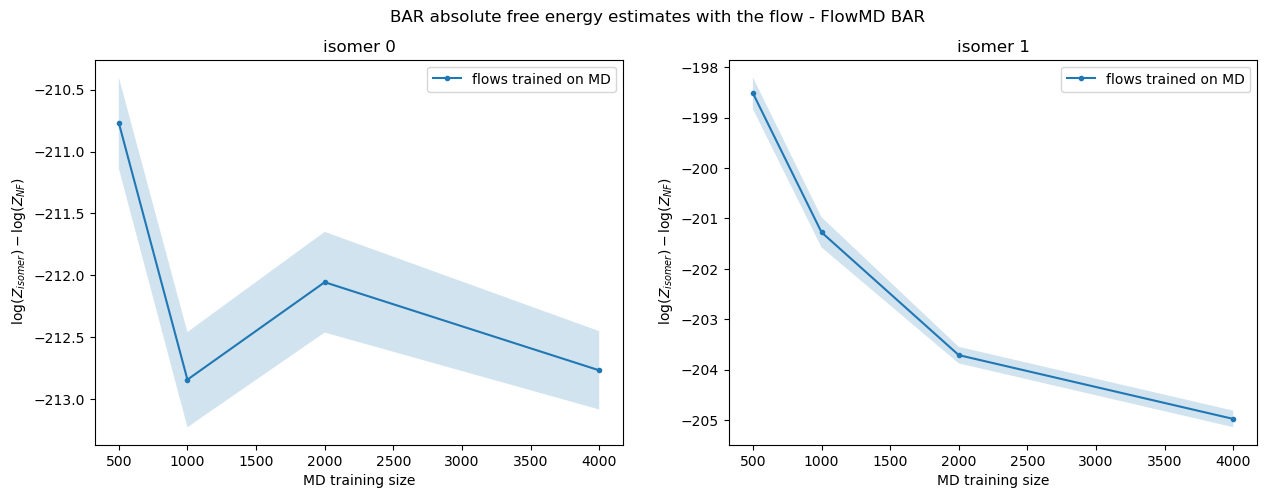

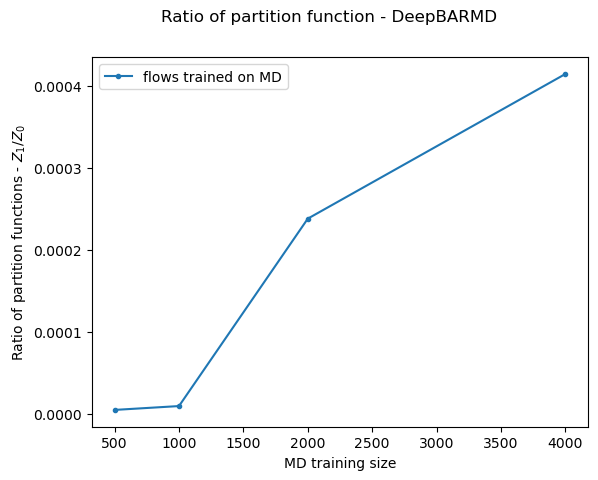

In [612]:
plt.figure(figsize=(15, 5))
plt.suptitle('BAR absolute free energy estimates with the flow - FlowMD BAR')

    
axs = [plt.subplot(1, 2, i+1) for i in range(2)]
for isomer_id in mode_labels:
    plt.sca(axs[isomer_id])
    plt.title('isomer {:d}'.format(isomer_id))

    plt.plot(dic_results_BARs_flow_md[isomer_id]['md_training_size'],
                dic_results_BARs_flow_md[isomer_id]['means'],  '.-', label='flows trained on MD')
    plt.fill_between(dic_results_BARs_flow_md[isomer_id]['md_training_size'],
                    np.array(dic_results_BARs_flow_md[isomer_id]['means']) - np.array(dic_results_BARs_flow_md[isomer_id]['stds']),
                    np.array(dic_results_BARs_flow_md[isomer_id]['means']) + np.array(dic_results_BARs_flow_md[isomer_id]['stds']),
                    alpha=0.2)
    plt.legend()
    plt.xlabel('MD training size')
    plt.ylabel(r' $\log(Z_{isomer}) - \log(Z_{NF})$') 

plt.title('isomer {:d}'.format(isomer_id))

plt.figure()
plt.suptitle('Ratio of partition function - DeepBARMD ')
plt.plot(dic_results_BARs_flow_md[isomer_id]['md_training_size'],
            np.exp( np.array(dic_results_BARs_flow_md[0]['means']) - np.array(dic_results_BARs_flow_md[1]['means'])),  '.-', label='flows trained on MD')
# plt.fill_between(dic_results_BARs_flow_md[isomer_id]['md_training_size'],
#                 np.array(dic_results_BARs_flow_md[isomer_id]['means']) - np.array(dic_results_BARs_flow_md[isomer_id]['stds']),
#                 np.array(dic_results_BARs_flow_md[isomer_id]['means']) + np.array(dic_results_BARs_flow_md[isomer_id]['stds']),
#                 alpha=0.2)
plt.legend()
plt.xlabel('MD training size')
plt.ylabel(r'Ratio of partition functions - $Z_1 / Z_0$') 